# Single cluster DNGC analysis

Inspect one expression cluster from the same window-profile CSV and settings as `windowed_DNGC_analysis.ipynb`. Set `EXAMPLE_CLUSTER_NUMBER` to choose the cluster. Each sequence shows the mean σNGC aggregation, with a DNGC = A / S line. Histograms show the per-sequence DNGC, potency (A), coverage (F), and S score distributions.


## Configs and Metrics


In [30]:
# Load compact profiles produced by window_sequence_analysis/run_svm_prediction.py
from __future__ import annotations

import re
import sys
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import FuncFormatter, LogLocator, MaxNLocator

plt.style.use("seaborn-v0_8-whitegrid")


def repo_root_from_here() -> Path:
    here = Path.cwd().resolve()
    for path in (here, *here.parents):
        if (path / "window_sequence_analysis").is_dir():
            return path
    raise FileNotFoundError("Could not locate the repository root.")


def resolve_data_dir(root: Path, data_dir: str) -> Path:
    path = Path(data_dir)
    resolved = path if path.is_absolute() else (root / path)
    resolved = resolved.resolve()
    if not resolved.is_dir():
        raise FileNotFoundError(f"Data directory not found: {resolved}")
    return resolved


def latest_profile_csv(data_dir: Path) -> Path:
    filename = "window_sequence_profiles.csv"
    results_root = data_dir / "results"
    run_profiles = list((results_root / "runs").glob(f"*/{filename}"))
    if run_profiles:
        return max(run_profiles, key=lambda path: path.stat().st_mtime_ns)
    legacy_profile = results_root / filename
    if legacy_profile.is_file():
        return legacy_profile
    raise FileNotFoundError(
        f"No {filename} found in {results_root / 'runs'} or {results_root}. "
        "Set DATA_DIR to the input data folder (e.g. data/skin_samples)."
    )


ROOT = repo_root_from_here()
DATA_DIR = "data/skin_samples"
DATA_PATH = resolve_data_dir(ROOT, DATA_DIR)
RESULTS_ROOT = DATA_PATH / "results"
PROFILES_CSV = latest_profile_csv(DATA_PATH)

CLUSTER_COL = "single_cell_expression_cluster"
DELIMITER_COL = "profile_delimiter"
UNASSIGNED_LABEL = "(unassigned)"

PROFILE_GRID = 200
MAX_OVERLAY_TRACES = 40
INCLUDE_UNASSIGNED = False
CLUSTER_SUBSTRING: str | None = None
MAX_CLUSTERS: int | None = None
CLUSTER_ORDER_BY = "prevalence"
CLUSTER_ORDER_DESCENDING = True
EXPECTED_CLUSTER_COUNT: int | None = 108

def sigma_for_p_amp(p_amp: float, svm_pkl: Path) -> float:
    """Invert the SVM Platt fit so a P(AMP) decision boundary becomes a sigma."""
    if not 0.0 < p_amp < 1.0:
        raise ValueError(f"P_AMP_FITTING must be between 0 and 1, got {p_amp}.")
    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))
    from window_sequence_analysis.models.svm import load_svm

    svm = load_svm(svm_pkl)
    classes = np.asarray(getattr(svm, "classes_", []))
    if classes.size != 2 or int(classes[-1]) != 1:
        raise ValueError(f"Expected a binary SVM with positive class 1, got classes {classes}.")
    prob_a = float(np.asarray(svm.probA_).ravel()[0])
    prob_b = float(np.asarray(svm.probB_).ravel()[0])
    if prob_a == 0.0:
        raise ValueError("SVM Platt slope probA_ is 0, so P(AMP) cannot be mapped to sigma.")
    # sklearn's binary decision_function is the negated libsvm margin.
    # P(AMP) = 1 / (1 + exp(probA * sigma - probB)).
    return float((np.log((1.0 - p_amp) / p_amp) + prob_b) / prob_a)


def activity_boundary_label() -> str:
    sigma_text = f"σNGC > {SIGMA_ACTIVITY_THRESHOLD:.2f}"
    if P_AMP_FITTING is None:
        return f"Threshold {sigma_text}"
    return f"Threshold P > {P_AMP_FITTING:g} / {sigma_text}"


# P(AMP) activity boundary. None keeps AUC and plots at sigma = 0.
# 0.8 is inverted through the SVM Platt fit to the matching sigma.
P_AMP_FITTING: float | None = None
SVM_PKL = ROOT / "checkpoints" / "svm_no_class_weight" / "svm_qsar12_model.pkl"
SIGMA_ACTIVITY_THRESHOLD = 0.0 if P_AMP_FITTING is None else sigma_for_p_amp(P_AMP_FITTING, SVM_PKL)
P_AMP_ACTIVITY_THRESHOLD: float | None = None
# Proteins with DNGC (A / S) below this are dropped before every table and plot.
# None keeps every protein. A protein equal to the threshold is kept.
DNGC_MIN_THRESHOLD: float | None = None
PLOT_PREVIEW_LIMIT: int | None = 16
PLOT_GRID_ROWS = 4
PLOT_GRID_COLUMNS = 4
# True uses one y-limit for every histogram panel. False lets each panel autoscale.
SCALE_HISTOGRAM_Y = False
SAVE_ALL_CLUSTER_PLOTS = True
SAVE_DPI = 200
CLUSTER_PLOT_DIR = RESULTS_ROOT / "dngc_cluster_plots"

print("ROOT:", ROOT)
print("data dir:", DATA_PATH)
print("profiles:", PROFILES_CSV)
print("activity rule:", activity_boundary_label())
print("P(AMP) threshold:", P_AMP_ACTIVITY_THRESHOLD or "not applied")
print("DNGC minimum:", "not applied" if DNGC_MIN_THRESHOLD is None else DNGC_MIN_THRESHOLD)
print("shared histogram y-axis:", "on" if SCALE_HISTOGRAM_Y else "off")
print(
    "save cluster plots:",
    f"{CLUSTER_PLOT_DIR} (all clusters, 4x4 pages)" if SAVE_ALL_CLUSTER_PLOTS else "off",
)


ROOT: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction
data dir: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples
profiles: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/runs/2026-09-16_20-47/window_sequence_profiles.csv
activity rule: Threshold σNGC > 0.00
P(AMP) threshold: not applied
DNGC minimum: not applied
shared histogram y-axis: off
save cluster plots: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/dngc_cluster_plots (all clusters, 4x4 pages)


In [31]:
# load the input csv into an in-memory object to group by cluster


def parse_profile(text: object, delimiter: str = ";") -> np.ndarray:
    parts = str(text).split(delimiter or ";")
    values = np.empty(len(parts), dtype=np.float64)
    for index, part in enumerate(parts):
        token = part.strip()
        values[index] = np.nan if not token or token.lower() == "nan" else float(token)
    return values


def cluster_label(value: object) -> str:
    text = "" if pd.isna(value) else str(value).strip()
    return text or UNASSIGNED_LABEL


def cluster_sort_key(name: str) -> tuple[int, int, str]:
    match = re.match(r"Cluster\s+(\d+)", name)
    if match:
        return (0, int(match.group(1)), name)
    if name == UNASSIGNED_LABEL:
        return (2, 0, name)
    return (1, 0, name)


def short_cluster_label(name: str, max_len: int = 48) -> str:
    text = name[len("Cluster ") :] if name.startswith("Cluster ") else name
    if len(text) <= max_len:
        return text
    return text[: max_len - 3] + "..."


def activity_mask(sigma: np.ndarray, p_amp: np.ndarray) -> np.ndarray:
    mask = np.isfinite(sigma) & (sigma > SIGMA_ACTIVITY_THRESHOLD)
    if P_AMP_ACTIVITY_THRESHOLD is not None:
        mask &= np.isfinite(p_amp) & (p_amp > P_AMP_ACTIVITY_THRESHOLD)
    return mask


def count_fragments(active: np.ndarray) -> int:
    if active.size == 0 or not np.any(active):
        return 0
    padded = np.concatenate([[False], np.asarray(active, dtype=bool)])
    return int(np.count_nonzero(padded[1:] & ~padded[:-1]))


@dataclass(frozen=True)
class ActivityStatistics:
    s_score: int
    fragment_count: int
    potency_auc: float
    coverage: float
    dngc: float


def calculate_activity_statistics(
    sigma: np.ndarray,
    p_amp: np.ndarray,
    sequence_length: int,
) -> ActivityStatistics:
    active = activity_mask(sigma, p_amp)
    s_score = int(np.count_nonzero(active))
    fragment_count = count_fragments(active)
    excess = sigma[active] - SIGMA_ACTIVITY_THRESHOLD
    potency_auc = float(np.sum(excess)) if s_score else 0.0
    coverage = s_score / sequence_length if sequence_length else 0.0
    mean_dngc = potency_auc / s_score if s_score else 0.0
    return ActivityStatistics(
        s_score=s_score,
        fragment_count=fragment_count,
        potency_auc=potency_auc,
        coverage=coverage,
        dngc=mean_dngc,
    )


def interpolate_profile(sigma: np.ndarray, grid: int = PROFILE_GRID) -> np.ndarray:
    finite = np.isfinite(sigma)
    if not np.any(finite):
        return np.full(grid, np.nan, dtype=np.float64)
    x = np.linspace(0.0, 1.0, len(sigma))
    xp = np.linspace(0.0, 1.0, grid)
    filled = np.nan_to_num(sigma, nan=0.0)
    return np.interp(xp, x, filled)


MEAN_SIGMA_COLUMN = "hyperplane_distance_mean_profile"
MEAN_P_AMP_COLUMN = "p_amp_mean_profile"


@dataclass
class SequenceProfile:
    id: str
    name: str
    cluster: str
    sequence_length: int
    sigma: np.ndarray
    p_amp: np.ndarray
    statistics: ActivityStatistics
    best_window_p_amp: float
    best_window_hyperplane_distance: float

    @property
    def relative_sigma(self) -> np.ndarray:
        return interpolate_profile(self.sigma)


def _finite_values(values: list[float]) -> np.ndarray:
    finite = np.asarray(values, dtype=np.float64)
    return finite[np.isfinite(finite)]


def _mean_finite(values: list[float]) -> float:
    finite = _finite_values(values)
    return float(np.mean(finite)) if finite.size else float("nan")


def _max_finite(values: list[float]) -> float:
    finite = _finite_values(values)
    return float(np.max(finite)) if finite.size else float("nan")


def _median_finite(values: list[float]) -> float:
    finite = _finite_values(values)
    return float(np.median(finite)) if finite.size else float("nan")


@dataclass
class ClusterGroup:
    name: str
    profiles: list[SequenceProfile] = field(default_factory=list)

    @property
    def n(self) -> int:
        return len(self.profiles)

    @property
    def prevalence(self) -> float:
        return float(np.mean([item.statistics.s_score > 0 for item in self.profiles]))

    @property
    def mean_s_score(self) -> float:
        return _mean_finite([item.statistics.s_score for item in self.profiles])

    @property
    def mean_fragment_count(self) -> float:
        return _mean_finite([item.statistics.fragment_count for item in self.profiles])

    @property
    def mean_potency(self) -> float:
        return _mean_finite([item.statistics.potency_auc for item in self.profiles])

    @property
    def max_potency(self) -> float:
        return _max_finite([item.statistics.potency_auc for item in self.profiles])

    @property
    def mean_coverage(self) -> float:
        return _mean_finite([item.statistics.coverage for item in self.profiles])

    @property
    def mean_dngc(self) -> float:
        return _mean_finite([item.statistics.dngc for item in self.profiles])

    @property
    def median_dngc(self) -> float:
        return _median_finite([item.statistics.dngc for item in self.profiles])

    @property
    def curvature_load(self) -> float:
        total_length = sum(item.sequence_length for item in self.profiles)
        if not total_length:
            return float("nan")
        total_auc = sum(item.statistics.potency_auc for item in self.profiles)
        return total_auc / total_length

    @property
    def mean_best_window_p_amp(self) -> float:
        return _mean_finite([item.best_window_p_amp for item in self.profiles])

    @property
    def mean_best_window_distance(self) -> float:
        return _mean_finite([item.best_window_hyperplane_distance for item in self.profiles])

    @property
    def rank_score(self) -> float:
        metrics = {
            "prevalence": self.prevalence,
            "mean_DNGC": self.mean_dngc,
            "median_DNGC": self.median_dngc,
            "mean_A": self.mean_potency,
            "max_A": self.max_potency,
            "curvature_load": self.curvature_load,
            "mean_S": self.mean_s_score,
            "mean_N": self.mean_fragment_count,
            "best_window_p_amp": self.mean_best_window_p_amp,
            "best_window_hyperplane_distance": self.mean_best_window_distance,
        }
        if CLUSTER_ORDER_BY not in metrics:
            raise ValueError(f"Unsupported cluster ordering metric: {CLUSTER_ORDER_BY}")
        return metrics[CLUSTER_ORDER_BY]

    def stacked_relative_sigma(self) -> np.ndarray:
        if not self.profiles:
            return np.empty((0, PROFILE_GRID), dtype=np.float64)
        return np.vstack([item.relative_sigma for item in self.profiles])


def load_profile_table(path: Path) -> tuple[pd.DataFrame, str, str]:
    if not path.is_file():
        raise FileNotFoundError(f"Window profile CSV not found: {path}")
    frame = pd.read_csv(path)
    required = {"id", "sequence_length", DELIMITER_COL, CLUSTER_COL}
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f"Profile CSV missing columns: {missing}")
    if frame.empty:
        raise ValueError(f"Window profile CSV is empty: {path}")
        
    sigma_col = MEAN_SIGMA_COLUMN
    p_amp_col = MEAN_P_AMP_COLUMN
    missing_profiles = sorted({sigma_col, p_amp_col} - set(frame.columns))
    if missing_profiles:
        raise ValueError(f"Profile CSV missing required profile columns: {missing_profiles}.")
        
    return frame, sigma_col, p_amp_col


def build_cluster_groups(
    frame: pd.DataFrame,
    sigma_column: str,
    p_amp_column: str,
    *,
    cluster_names: set[str] | None = None,
    limit: int | None = MAX_CLUSTERS,
) -> list[ClusterGroup]:
    grouped: dict[str, ClusterGroup] = {}
    for row in frame.itertuples(index=False):
        label = cluster_label(getattr(row, CLUSTER_COL))
        if label == UNASSIGNED_LABEL and not INCLUDE_UNASSIGNED:
            continue
        if cluster_names is not None and label not in cluster_names:
            continue
        if CLUSTER_SUBSTRING and CLUSTER_SUBSTRING.casefold() not in label.casefold():
            continue
        delimiter = str(getattr(row, DELIMITER_COL) or ";")
        sigma = parse_profile(getattr(row, sigma_column), delimiter)
        p_amp = parse_profile(getattr(row, p_amp_column), delimiter)
        sequence_length = int(getattr(row, "sequence_length"))
        if len(sigma) != sequence_length or len(p_amp) != sequence_length:
            raise ValueError(f"{row.id}: profile length does not match sequence_length={sequence_length}.")
        profile = SequenceProfile(
            id=str(getattr(row, "id")),
            name=str(getattr(row, "name", "") or "").strip(),
            cluster=label,
            sequence_length=sequence_length,
            sigma=sigma,
            p_amp=p_amp,
            statistics=calculate_activity_statistics(sigma, p_amp, sequence_length),
            best_window_p_amp=_row_float(row, "best_window_p_amp"),
            best_window_hyperplane_distance=_row_float(row, "best_window_hyperplane_distance"),
        )
        grouped.setdefault(label, ClusterGroup(name=label)).profiles.append(profile)

    def order_key(group: ClusterGroup) -> tuple[bool, float, tuple[int, int, str]]:
        score = group.rank_score
        if not np.isfinite(score):
            return (True, 0.0, cluster_sort_key(group.name))
        ordered_score = -score if CLUSTER_ORDER_DESCENDING else score
        return (False, ordered_score, cluster_sort_key(group.name))

    groups = sorted(grouped.values(), key=order_key)
    if limit is not None:
        groups = groups[: max(0, int(limit))]
    return groups


def _row_float(row: object, column: str) -> float:
    if not hasattr(row, column):
        return float("nan")
    try:
        value = float(getattr(row, column))
    except (TypeError, ValueError):
        return float("nan")
    return value if np.isfinite(value) else float("nan")


def protein_dngc(row: pd.Series, sigma_column: str, p_amp_column: str) -> float:
    delimiter = str(row[DELIMITER_COL] or ";")
    sigma = parse_profile(row[sigma_column], delimiter)
    p_amp = parse_profile(row[p_amp_column], delimiter)
    sequence_length = int(row["sequence_length"])
    return calculate_activity_statistics(sigma, p_amp, sequence_length).dngc


def exclude_proteins_below_dngc(
    frame: pd.DataFrame,
    sigma_column: str,
    p_amp_column: str,
) -> pd.DataFrame:
    if DNGC_MIN_THRESHOLD is None:
        print("DNGC minimum: not applied")
        return frame
    scores = frame.apply(lambda row: protein_dngc(row, sigma_column, p_amp_column), axis=1)
    kept = frame.loc[scores >= DNGC_MIN_THRESHOLD].reset_index(drop=True)
    excluded = len(frame) - len(kept)
    print(
        f"DNGC minimum {DNGC_MIN_THRESHOLD:g}: excluded {excluded:,} of {len(frame):,} proteins "
        f"with DNGC < {DNGC_MIN_THRESHOLD:g}"
    )
    return kept


profiles_df, sigma_profile_column, p_amp_profile_column = load_profile_table(PROFILES_CSV)
profiles_df = exclude_proteins_below_dngc(profiles_df, sigma_profile_column, p_amp_profile_column)
clusters = build_cluster_groups(profiles_df, sigma_profile_column, p_amp_profile_column)
n_sequences = sum(group.n for group in clusters)
print(f"Loaded {n_sequences:,} proteins in {len(clusters):,} clusters from {PROFILES_CSV.name}")
print("σ profile:", sigma_profile_column)
print("P(AMP) profile:", p_amp_profile_column)
print(f"cluster order: {CLUSTER_ORDER_BY} (mean aggregation)")
if EXPECTED_CLUSTER_COUNT is not None and len(clusters) != EXPECTED_CLUSTER_COUNT:
    print(f"Warning: expected {EXPECTED_CLUSTER_COUNT} clusters but found {len(clusters)}.")


DNGC minimum: not applied
Loaded 4,601 proteins in 110 clusters from window_sequence_profiles.csv
σ profile: hyperplane_distance_mean_profile
P(AMP) profile: p_amp_mean_profile
cluster order: prevalence (mean aggregation)


In [32]:
def _sigma_ylim(max_sigma: np.ndarray) -> tuple[float, float]:
    positive_values = max_sigma[np.isfinite(max_sigma) & (max_sigma > SIGMA_ACTIVITY_THRESHOLD)]
    baseline = SIGMA_ACTIVITY_THRESHOLD
    hi = float(np.max(positive_values)) if positive_values.size else baseline + 0.1
    span = max(hi - baseline, 0.1)
    return (baseline, hi + 0.08 * span)

def _nice_bin_width(span: float, target_bins: int = 12) -> float:
    raw = span / max(target_bins, 1)
    if raw <= 0:
        return 1.0
    exponent = np.floor(np.log10(raw))
    fraction = raw / (10 ** exponent)
    if fraction <= 1:
        nice = 1.0
    elif fraction <= 2:
        nice = 2.0
    elif fraction <= 5:
        nice = 5.0
    else:
        nice = 10.0
    return float(nice * (10 ** exponent))

def histogram_bins(values: np.ndarray, target_bins: int = 12) -> np.ndarray:
    finite = values[np.isfinite(values)]
    maximum = float(finite.max()) if finite.size else 0.0
    width = _nice_bin_width(max(maximum, 0.0), target_bins)
    data_upper = max(width, float(np.ceil(maximum / width) * width)) if width else 1.0
    return np.arange(0.0, data_upper + width, width)

def configure_histogram_x_axis(ax, bins: np.ndarray, max_labels: int | None = None) -> None:
    ax.set_xticks(bins)
    ax.set_xticklabels([f"{edge:g}" for edge in bins])
    if len(bins) > 8:
        ax.tick_params(axis="x", labelrotation=45)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

def cluster_dngc_values(group: ClusterGroup) -> np.ndarray:
    return np.asarray(
        [item.statistics.dngc for item in group.profiles],
        dtype=np.float64,
    )


def sequence_s_score_values(group: ClusterGroup) -> np.ndarray:
    return np.asarray(
        [item.statistics.s_score for item in group.profiles],
        dtype=np.float64,
    )


def sequence_a_values(group: ClusterGroup) -> np.ndarray:
    return np.asarray(
        [item.statistics.potency_auc for item in group.profiles],
        dtype=np.float64,
    )


def sequence_f_values(group: ClusterGroup) -> np.ndarray:
    return np.asarray(
        [item.statistics.coverage for item in group.profiles],
        dtype=np.float64,
    )

def active_fragment_spans(sigma: np.ndarray, p_amp: np.ndarray) -> list[tuple[int, int, float]]:
    active = activity_mask(sigma, p_amp)
    if active.size == 0 or not np.any(active):
        return []
    padded = np.concatenate([[False], active, [False]])
    changes = np.diff(padded.astype(np.int8))
    starts = np.flatnonzero(changes == 1)
    ends = np.flatnonzero(changes == -1)
    spans = []
    for start, end in zip(starts, ends):
        segment = sigma[start:end]
        spans.append((int(start), int(end), float(np.sum(segment) / segment.size)))
    return spans


## Single cluster walkthrough


Cluster 15: Cluster 15: Non-specific - Protein processing
Sequences: 138
DNGC = A / S
  S score = number of residues with σNGC > 0.00
  N = fragment count = contiguous runs with σNGC > 0.00
  A = sum of (σNGC - 0) on those residues
  F = S / sequence length


,id,name,length,S,N,A,F,DNGC,DNGC_formula
0,sp|Q13685|AAMP_HUMAN,Angio-associated migratory cell protein,434,0,0,0.000000,0.000000,0.000000,0
1,sp|P30566|PUR8_HUMAN,Adenylosuccinate lyase,484,1,1,0.013464,0.002066,0.013464,0.0134642 / 1
2,sp|Q9BUR5|MIC26_HUMAN,MICOS complex subunit MIC26,198,0,0,0.000000,0.000000,0.000000,0
3,sp|Q66PJ3|AR6P4_HUMAN,ADP-ribosylation factor-like protein 6-interac...,237,86,3,58.031545,0.362869,0.674785,58.0315 / 86
4,sp|P12694|ODBA_HUMAN,"2-oxoisovalerate dehydrogenase subunit alpha, ...",445,0,0,0.000000,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...
133,sp|Q9BQ61|TRIR_HUMAN,Telomerase RNA component-interacting RNase,176,0,0,0.000000,0.000000,0.000000,0
134,sp|O95881|TXD12_HUMAN,Thioredoxin domain-containing protein 12,172,0,0,0.000000,0.000000,0.000000,0
135,sp|Q04323|UBXN1_HUMAN,UBX domain-containing protein 1,297,0,0,0.000000,0.000000,0.000000,0
136,sp|Q9BTM9|URM1_HUMAN,Ubiquitin-related modifier 1,101,0,0,0.000000,0.000000,0.000000,0


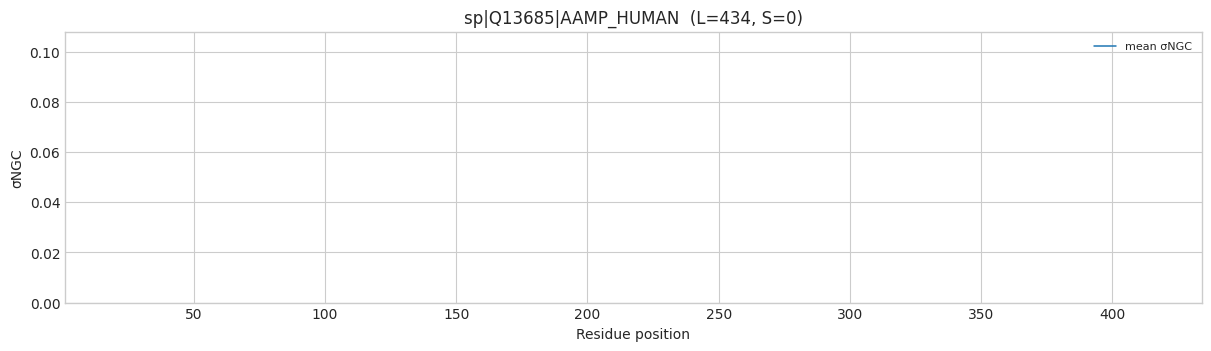

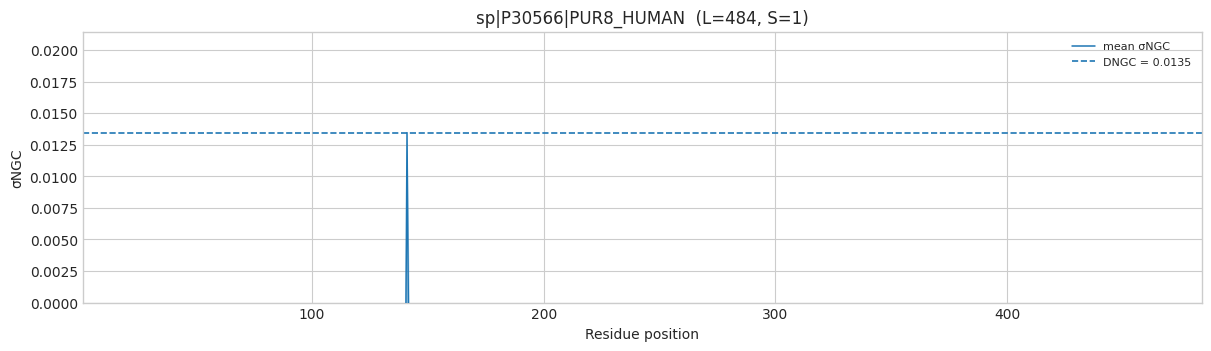

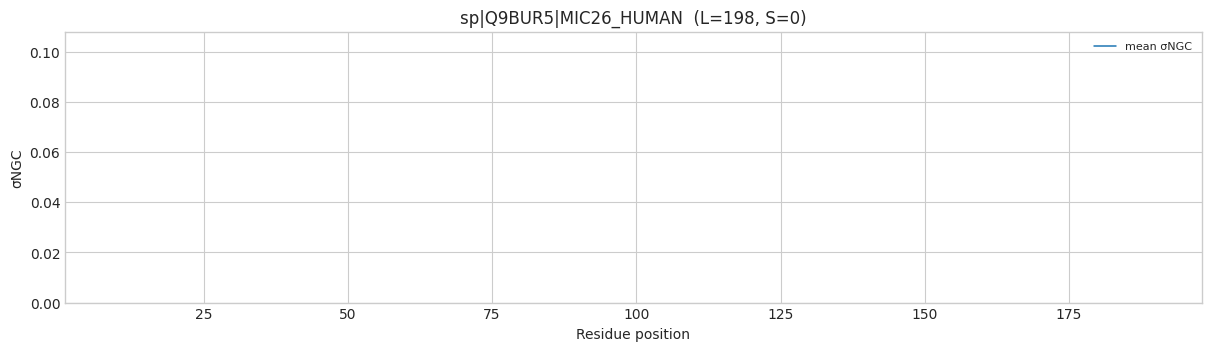

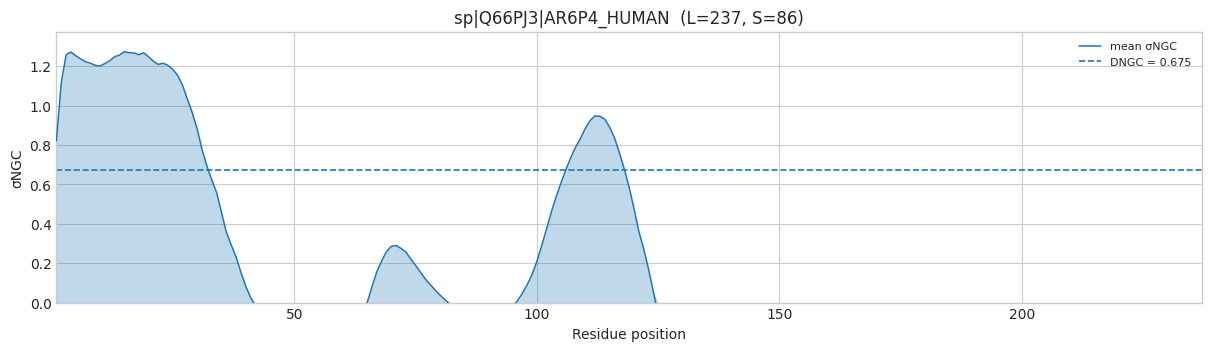

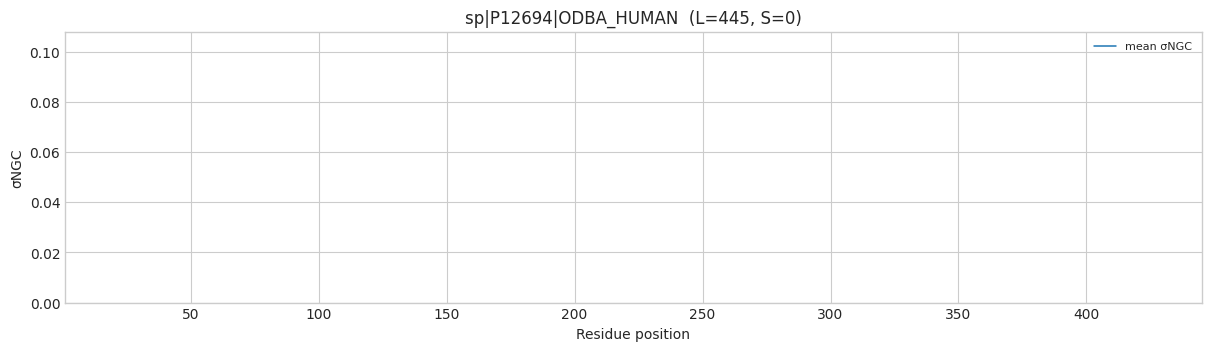

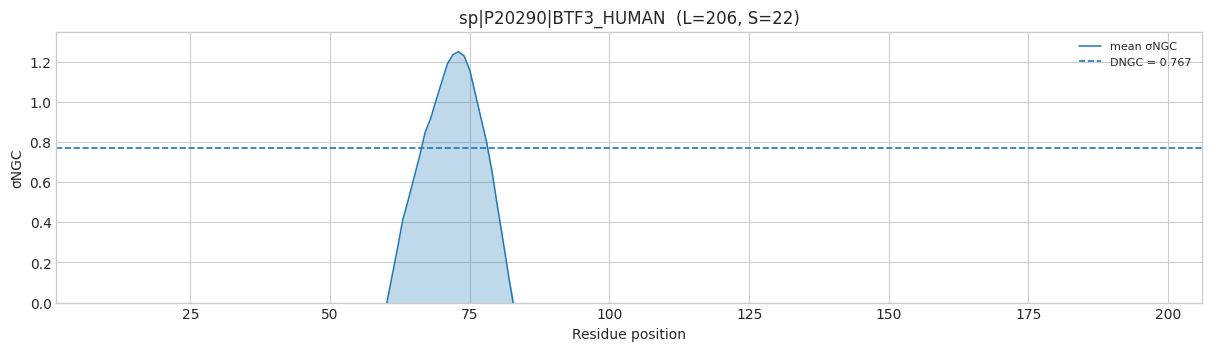

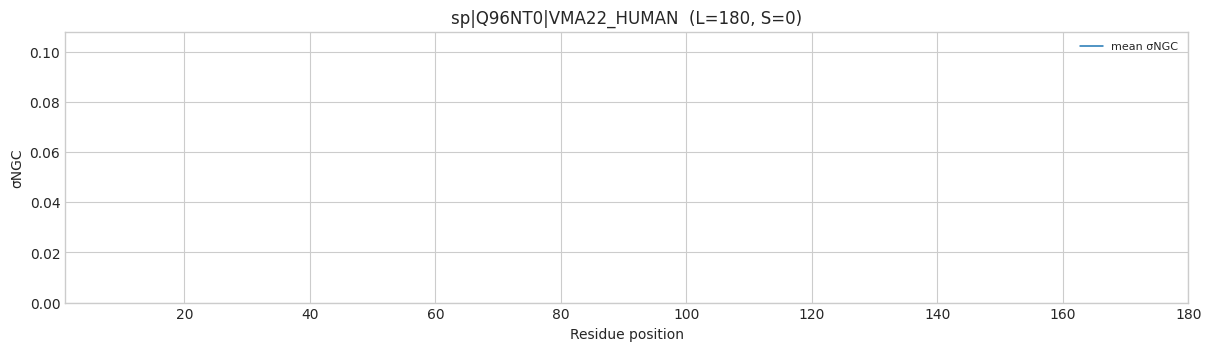

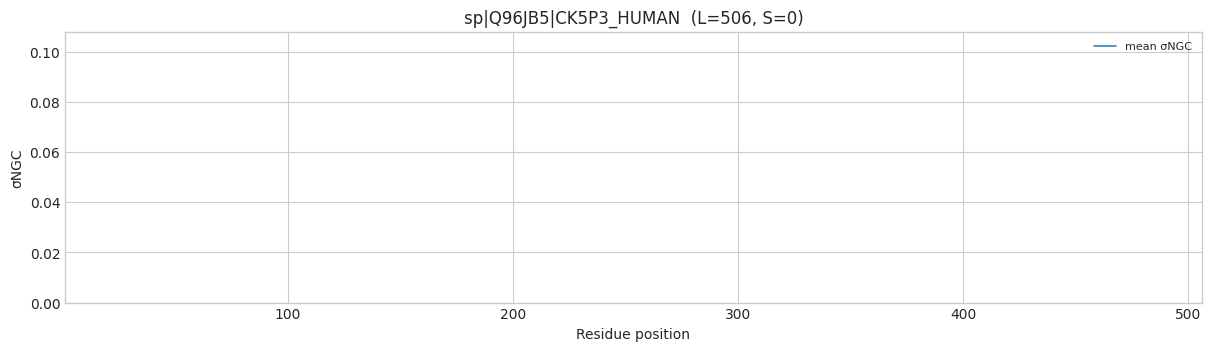

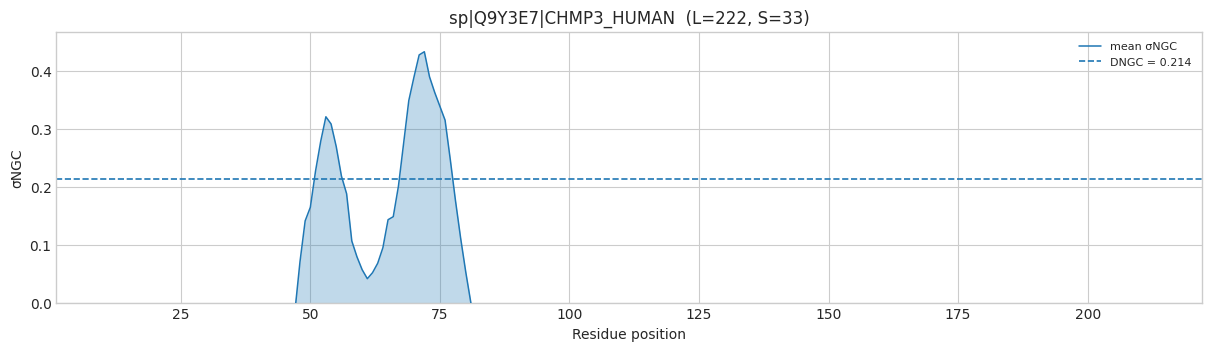

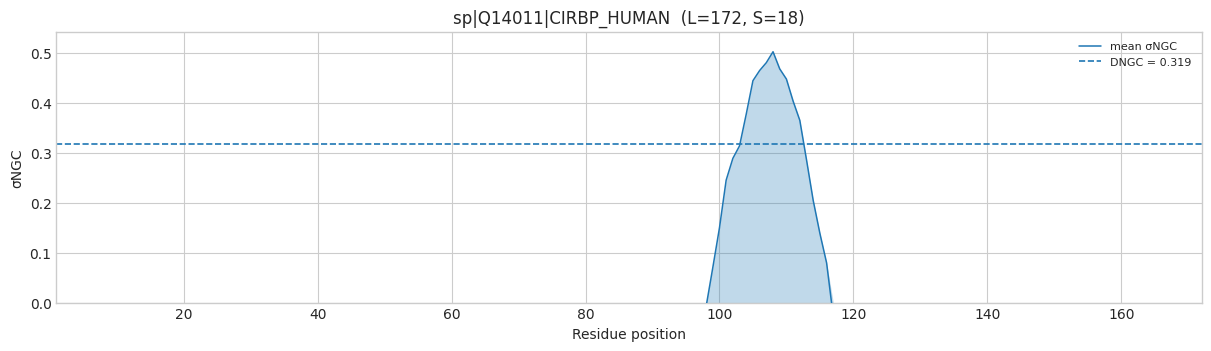

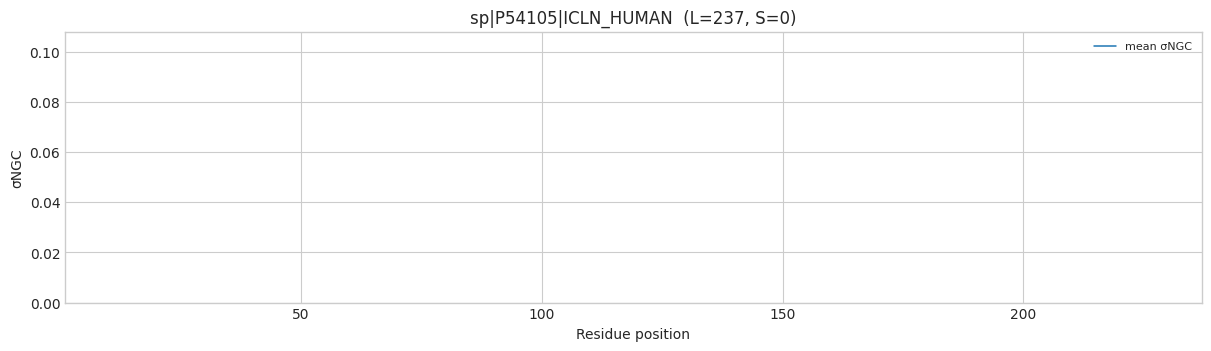

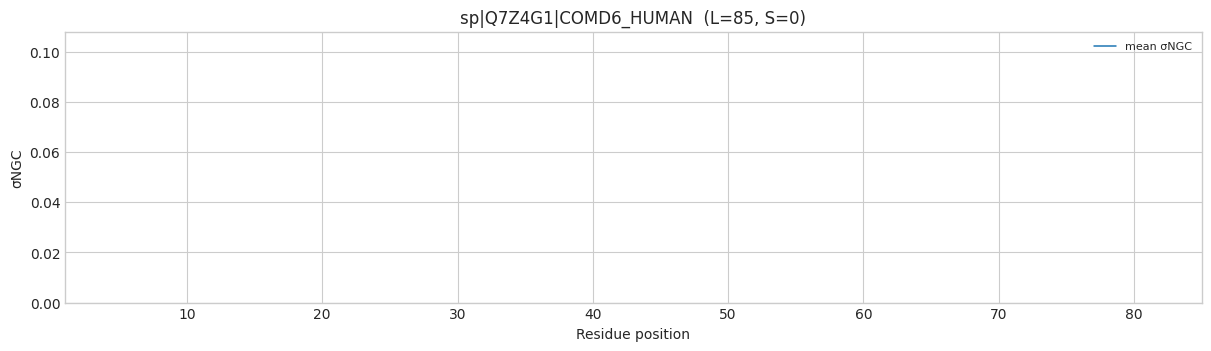

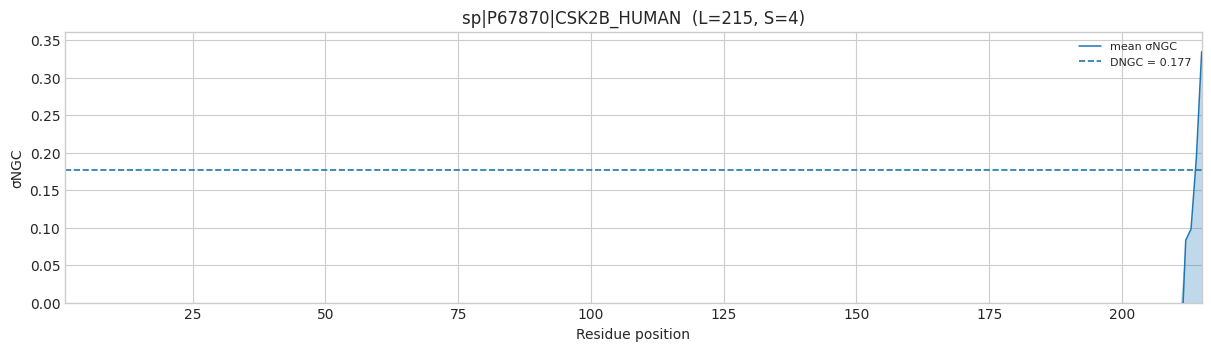

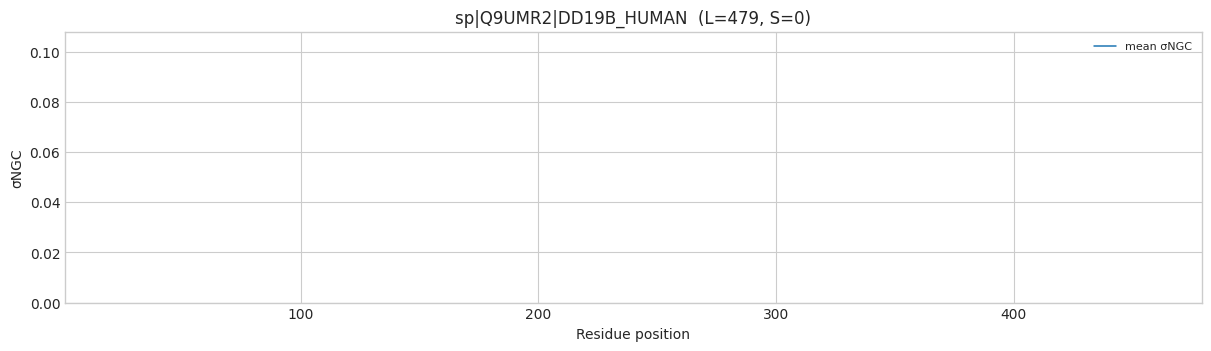

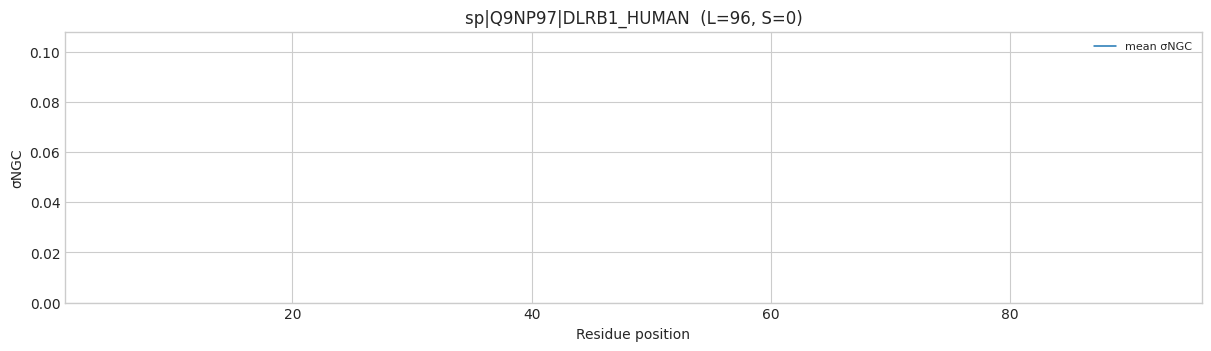

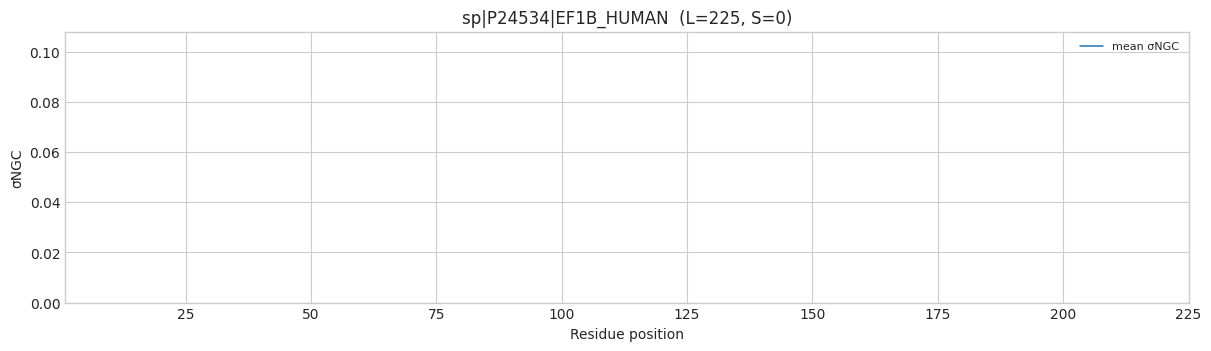

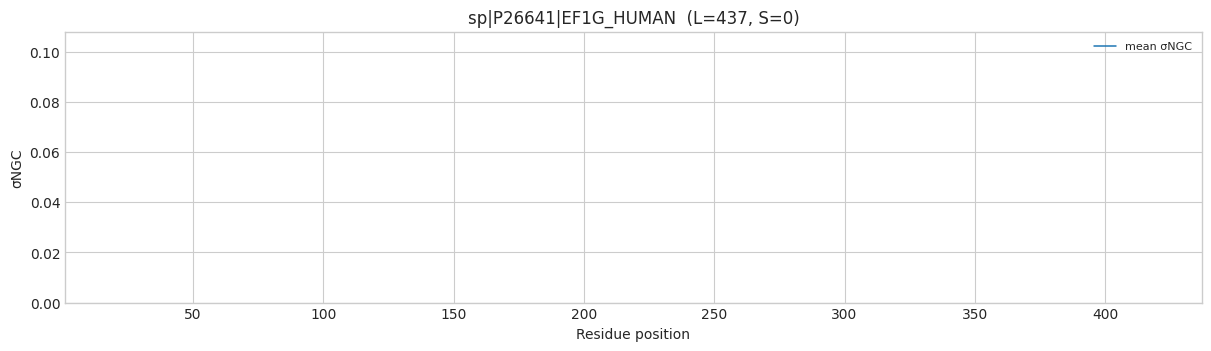

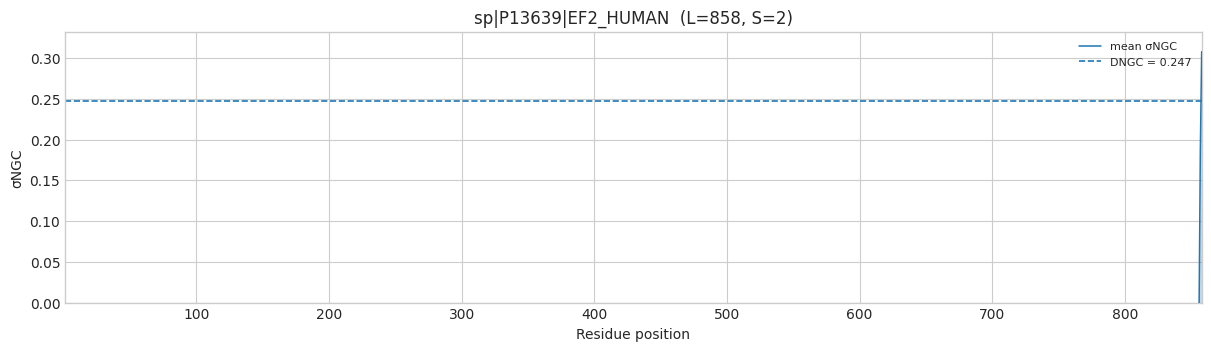

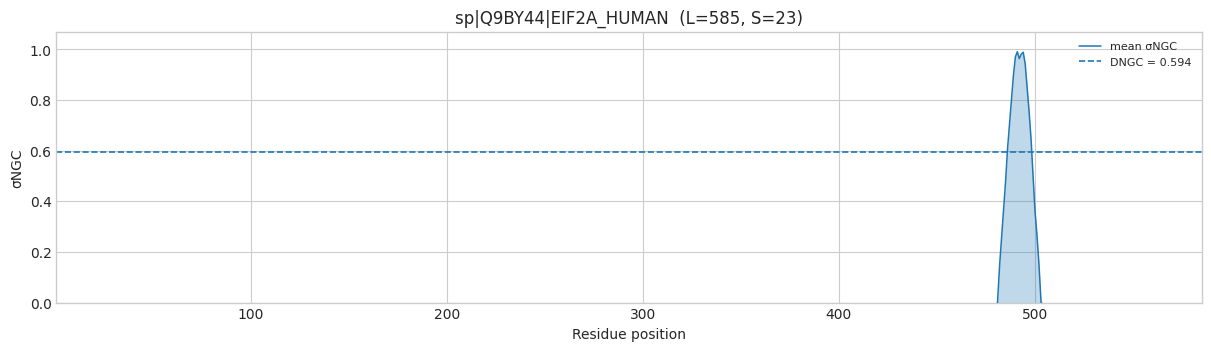

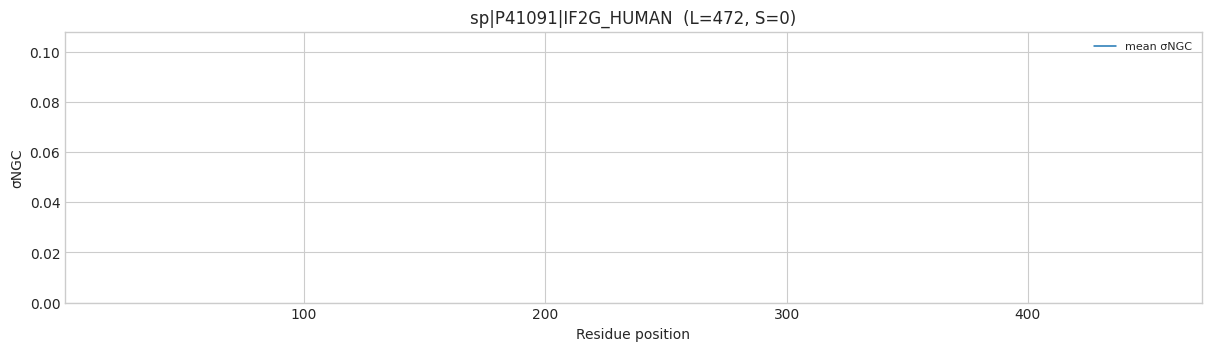

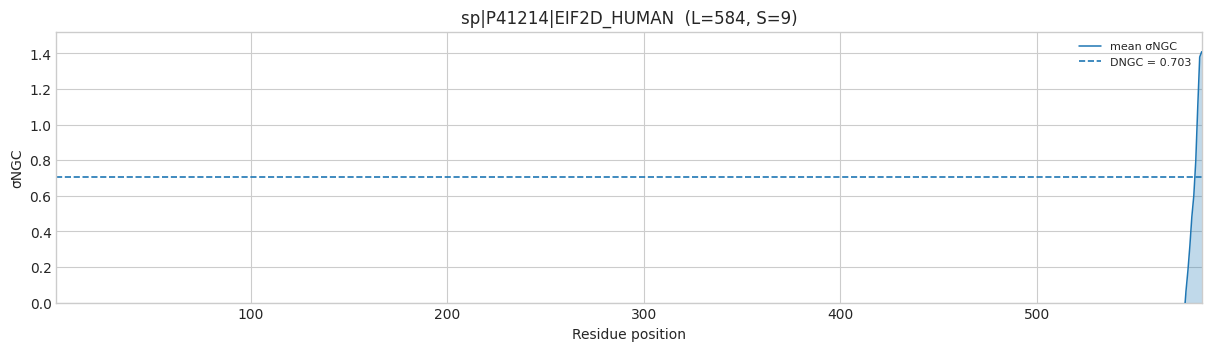

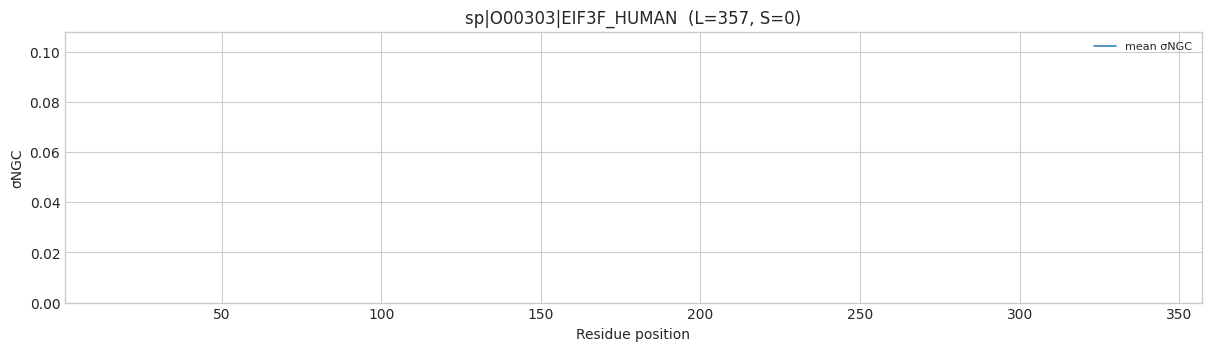

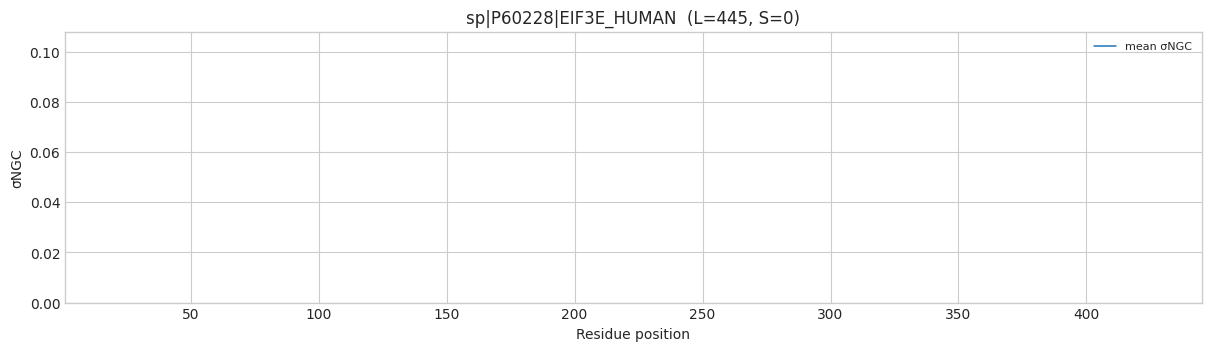

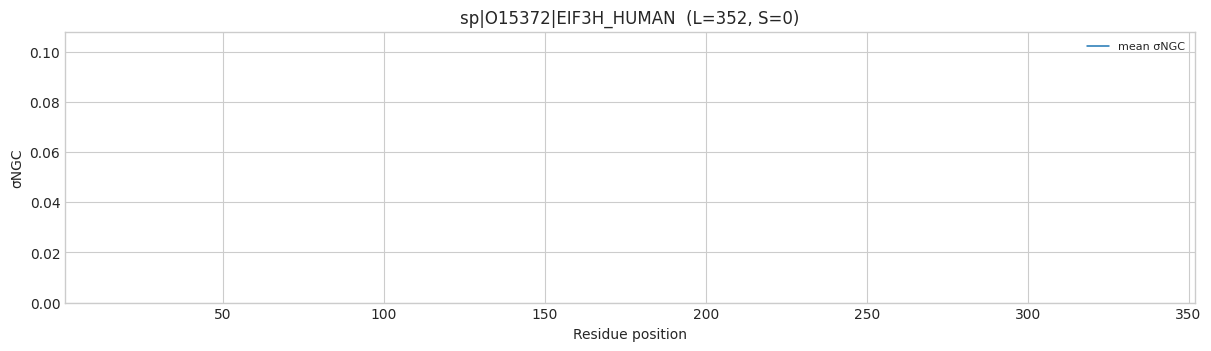

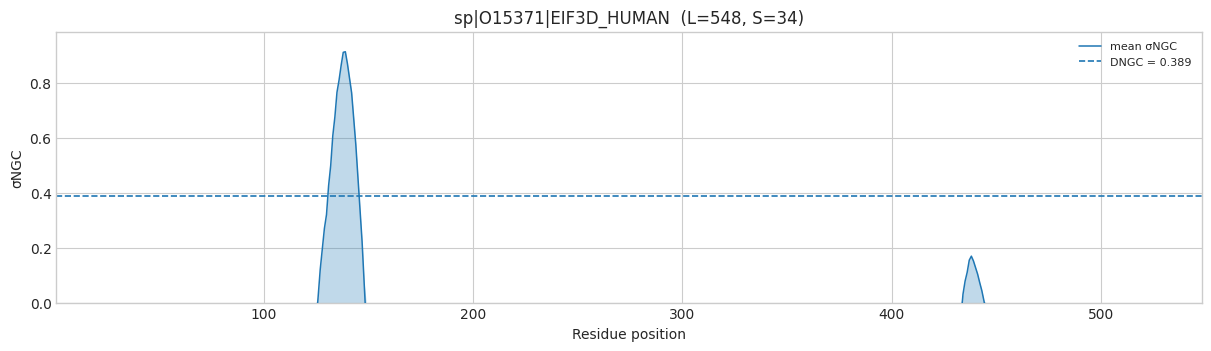

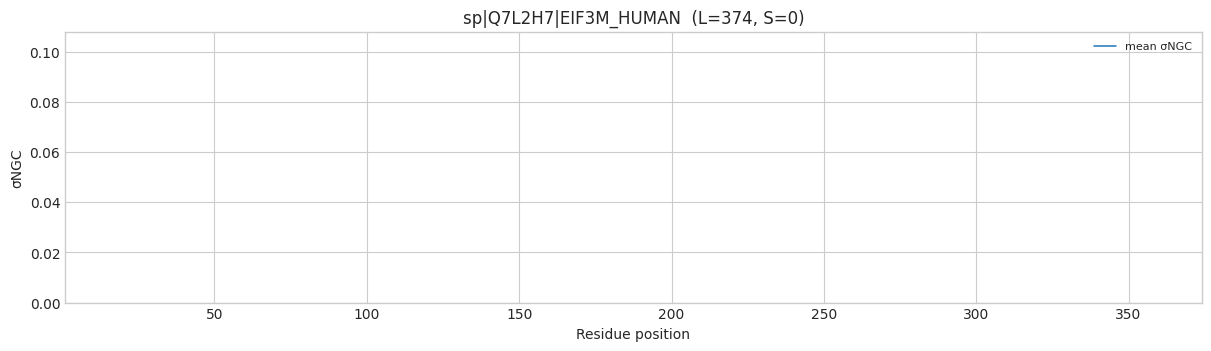

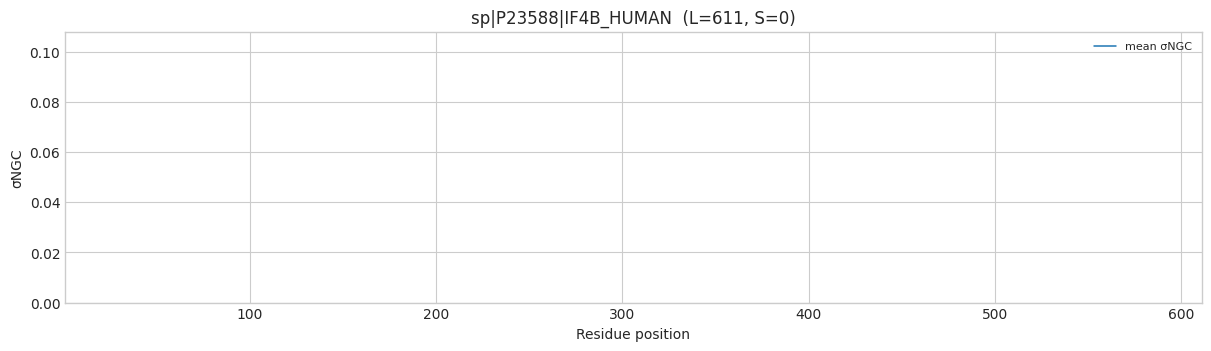

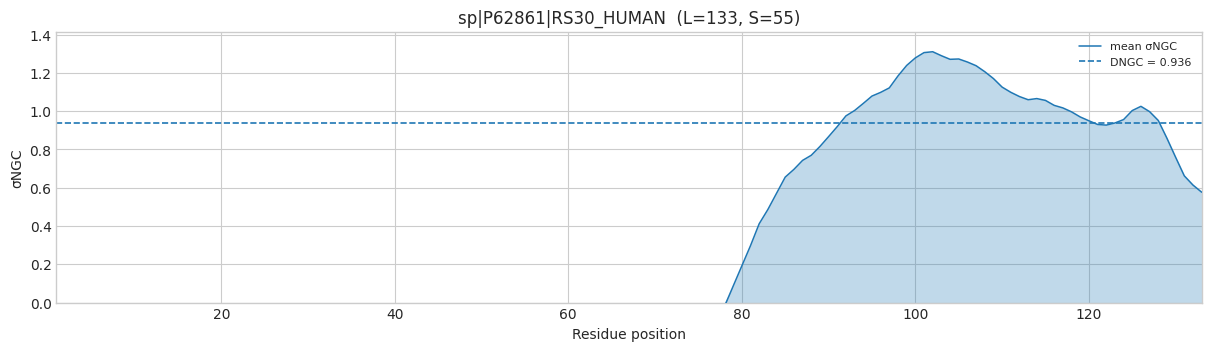

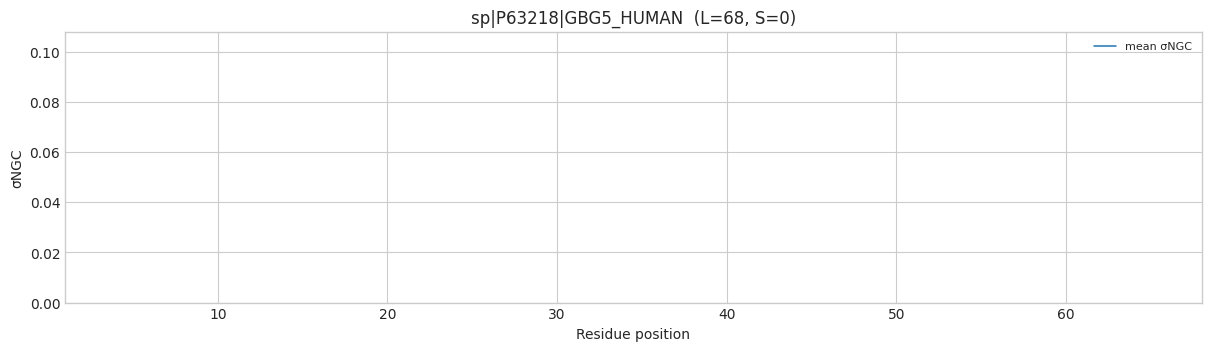

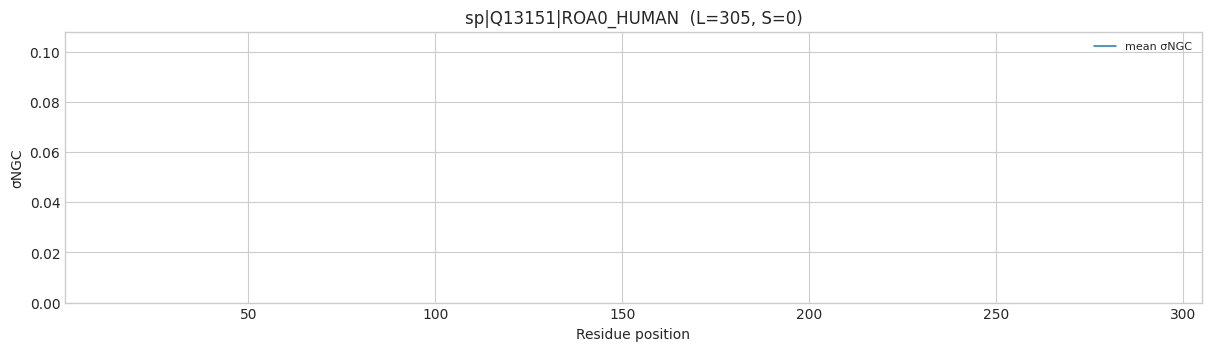

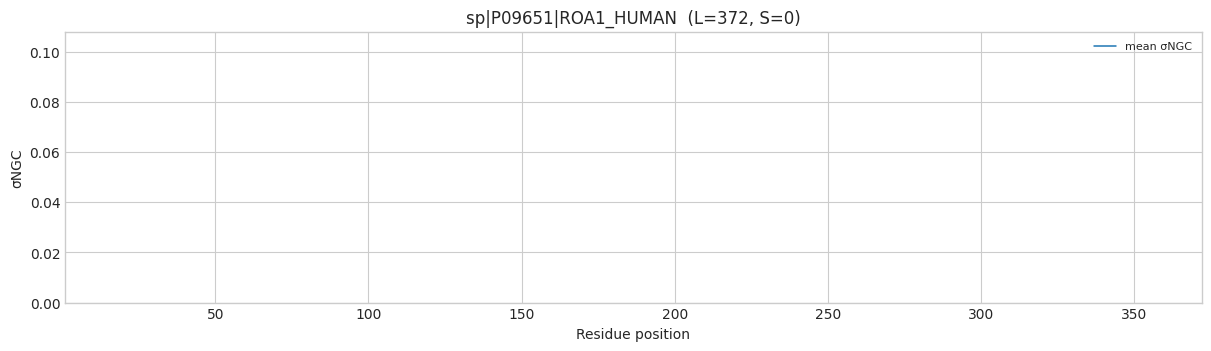

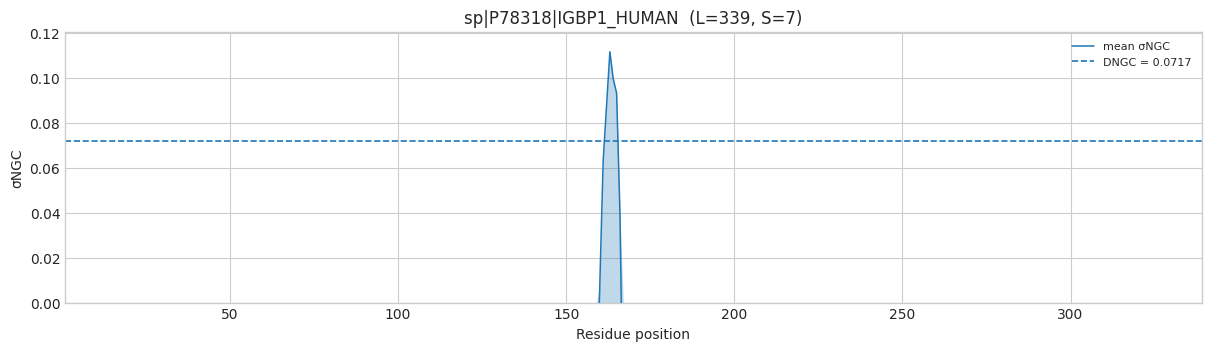

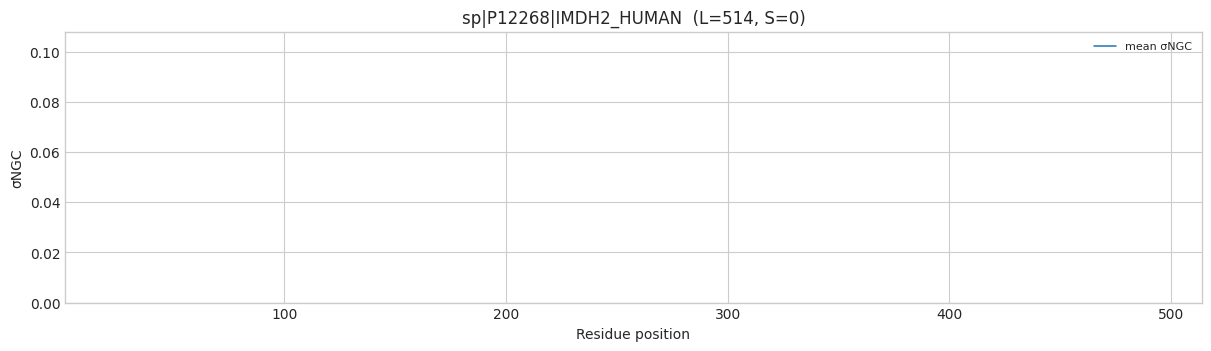

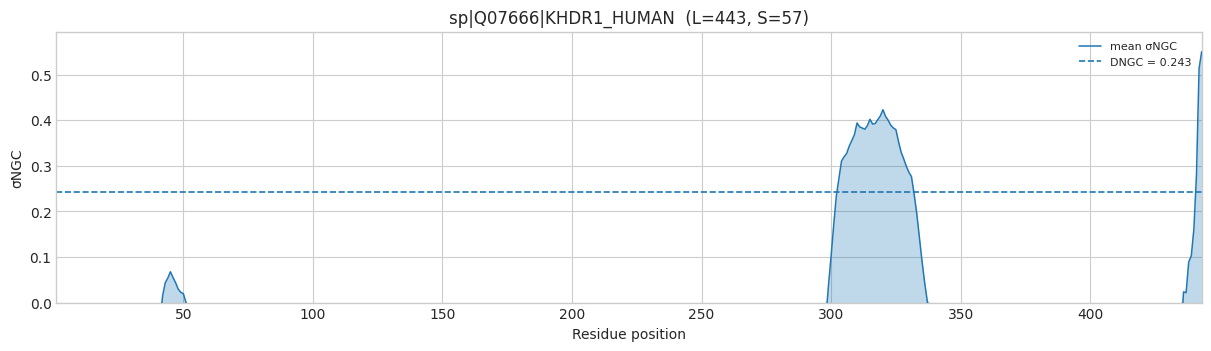

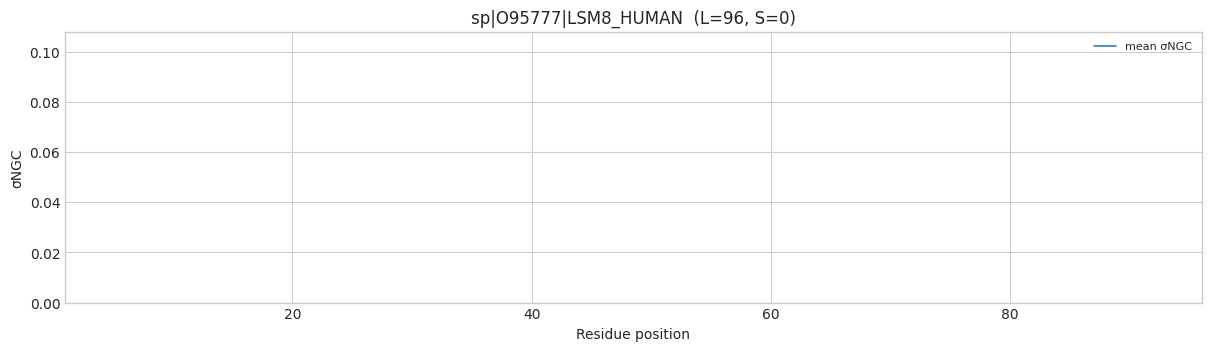

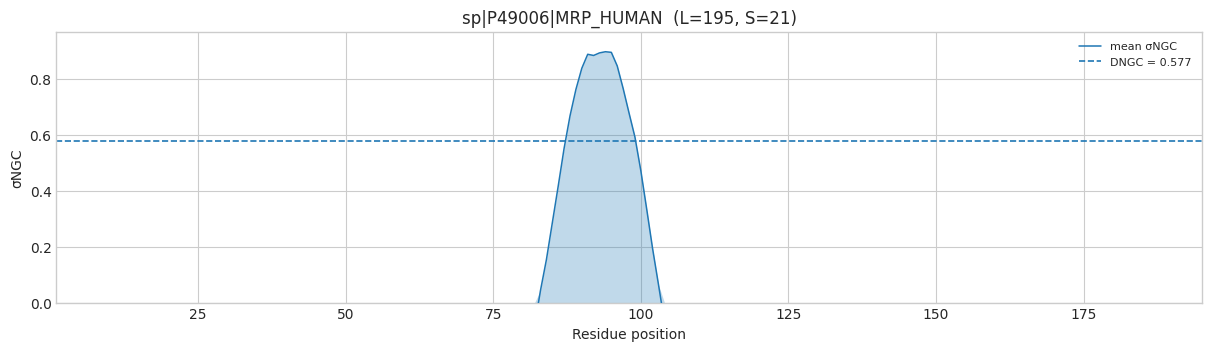

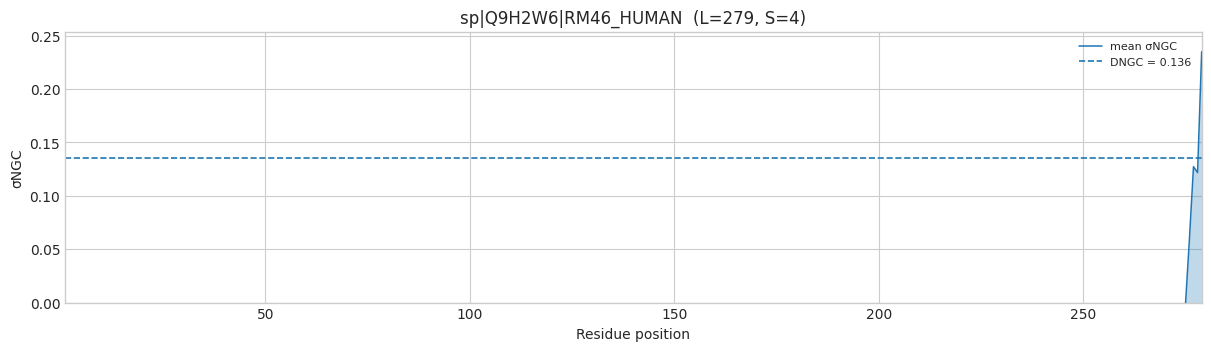

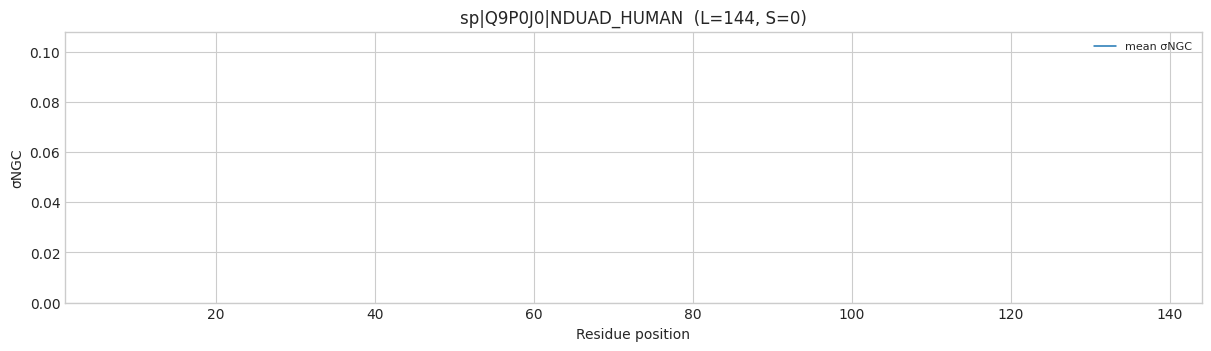

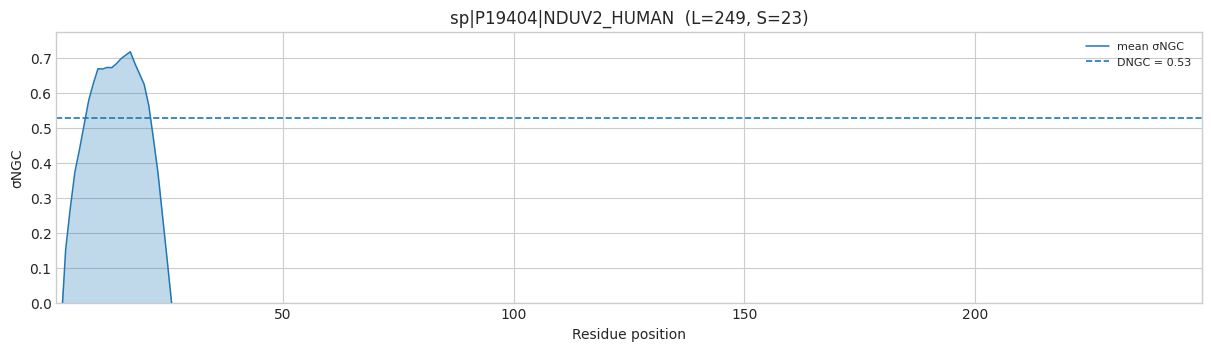

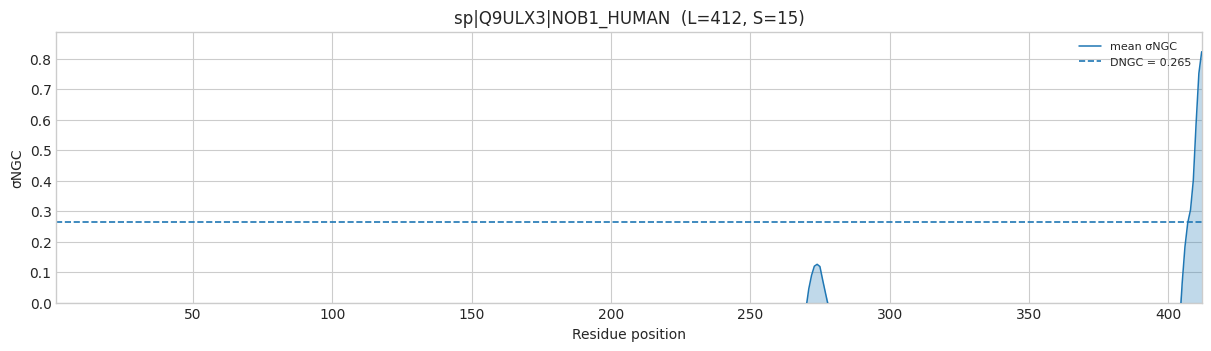

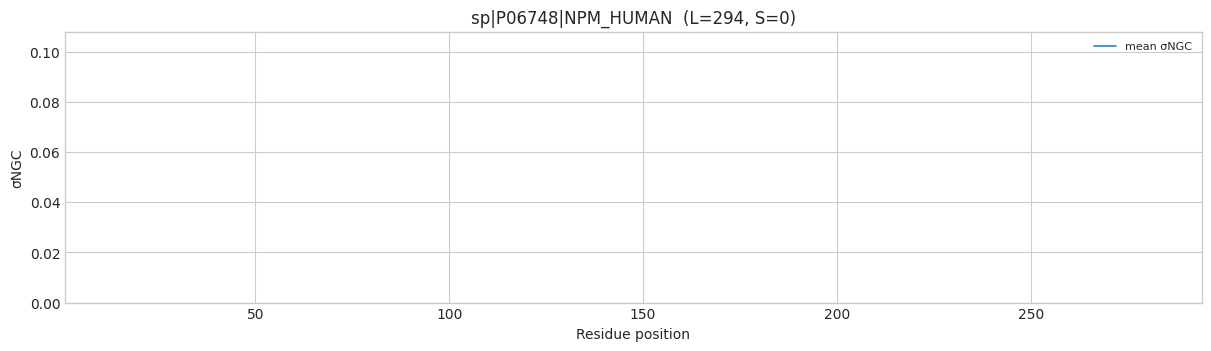

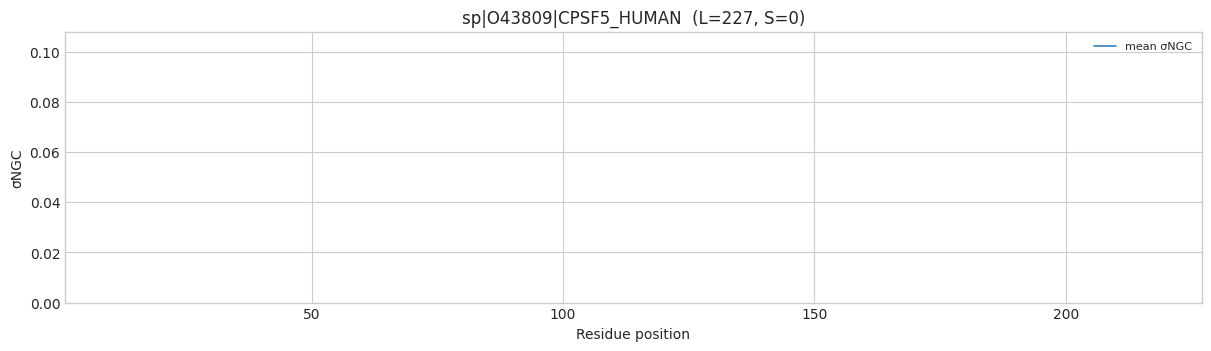

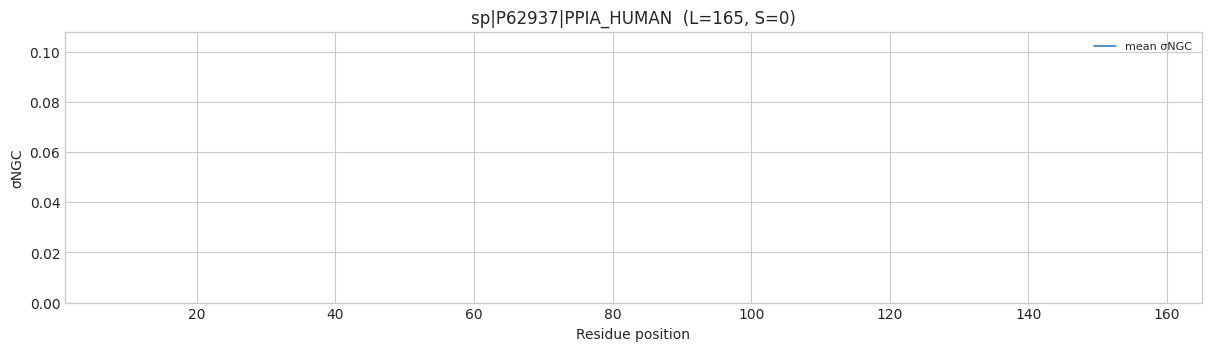

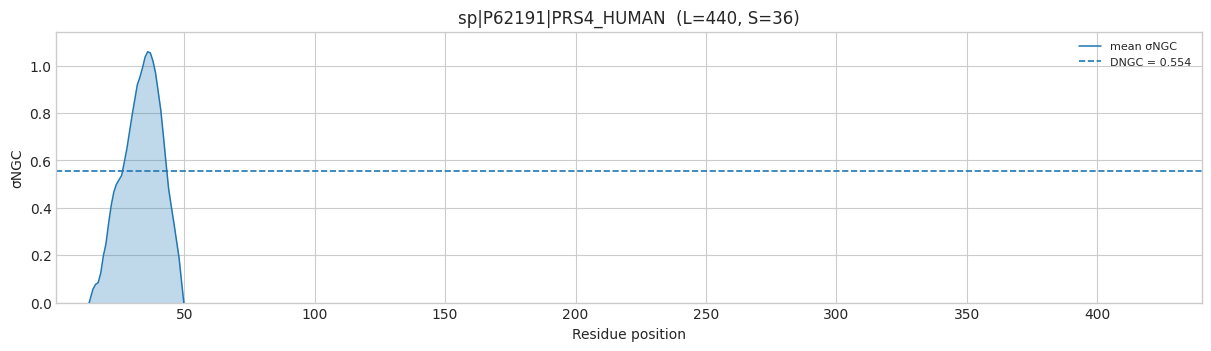

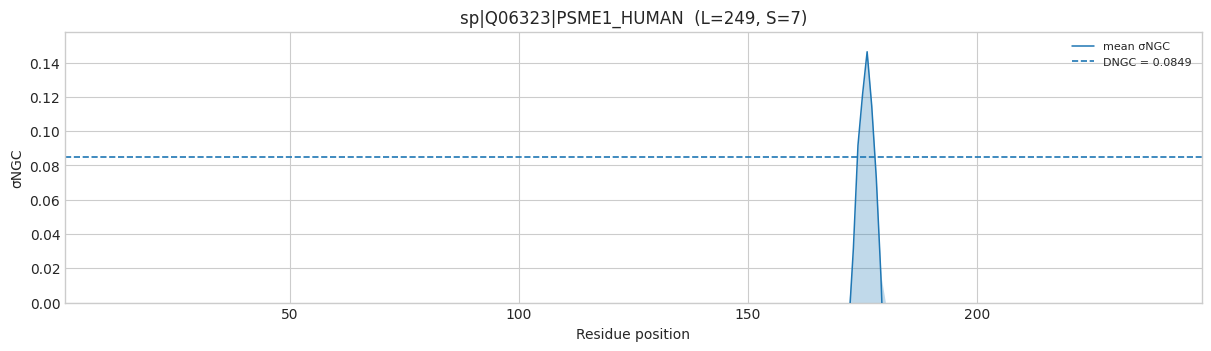

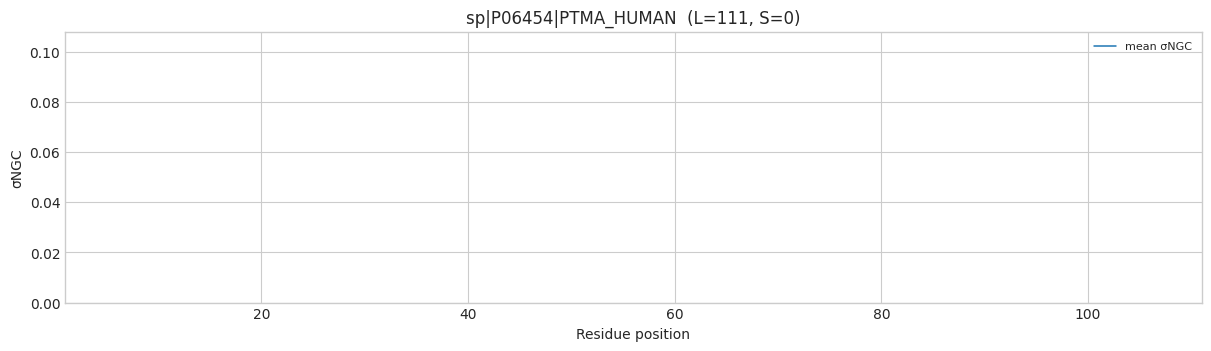

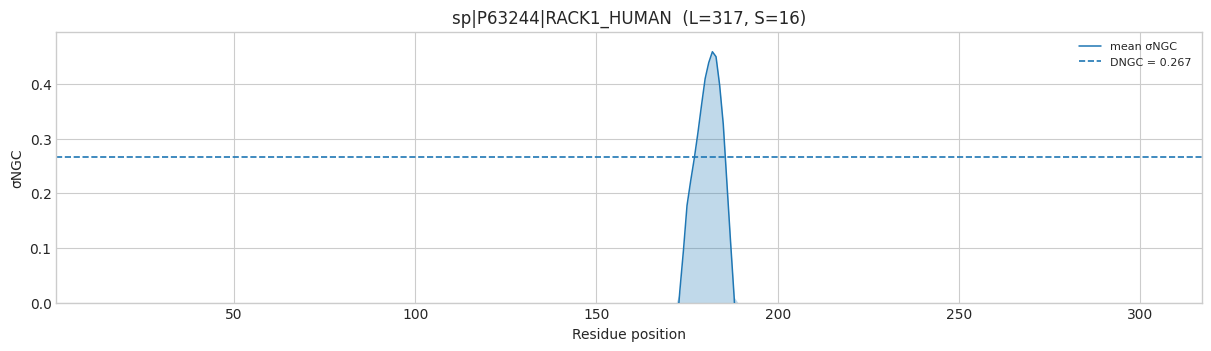

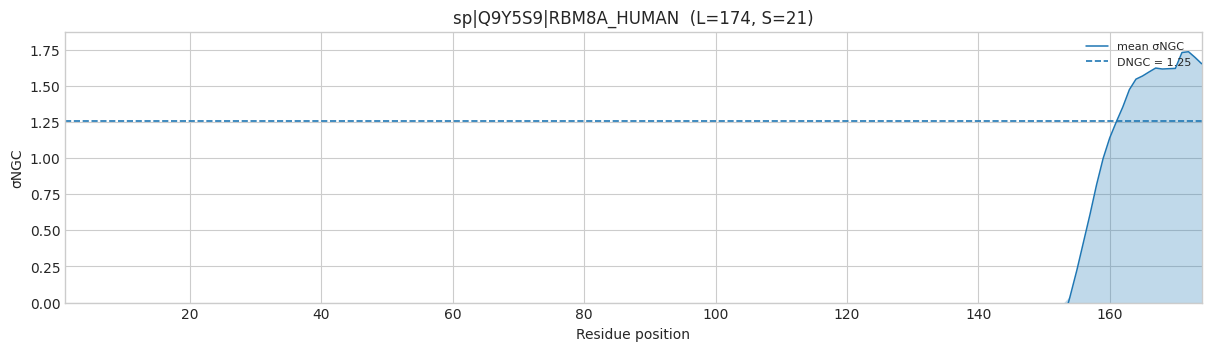

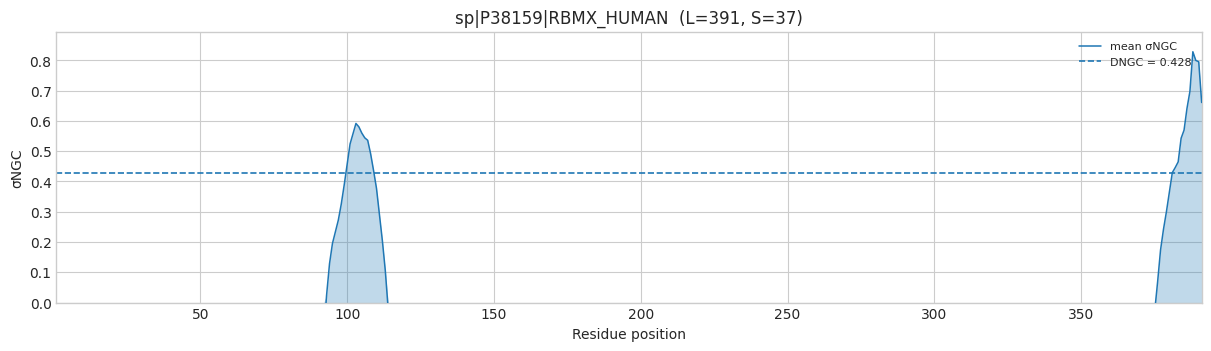

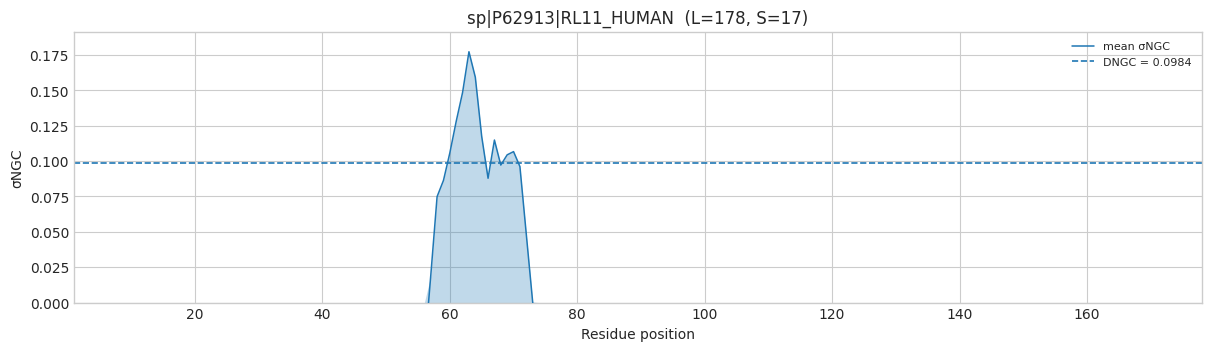

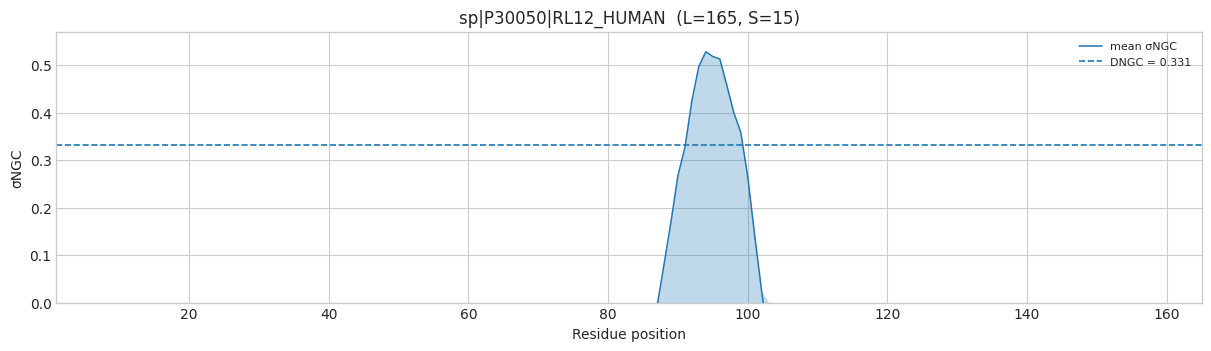

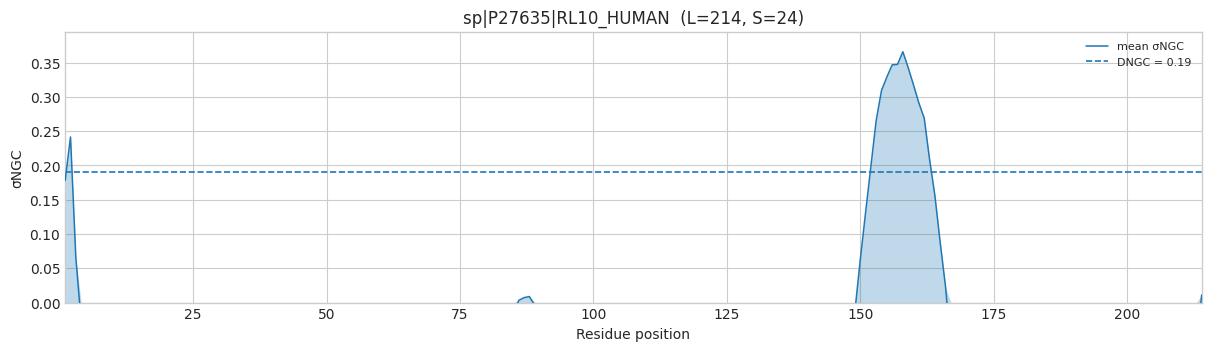

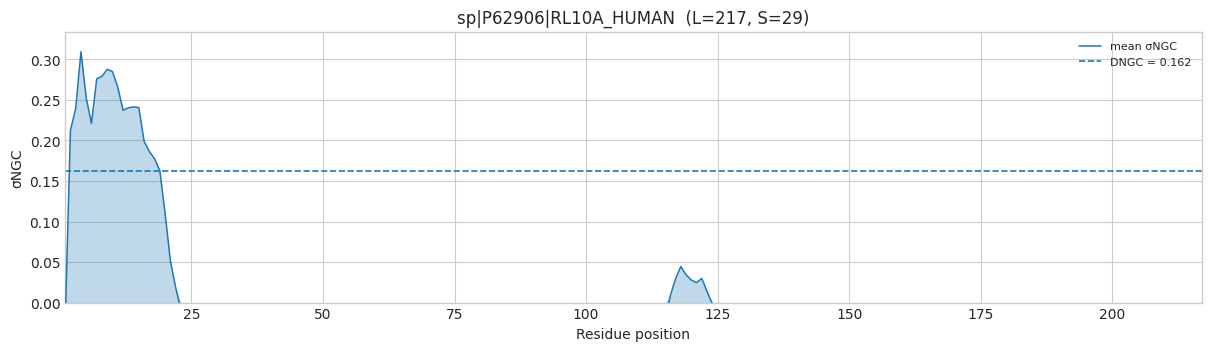

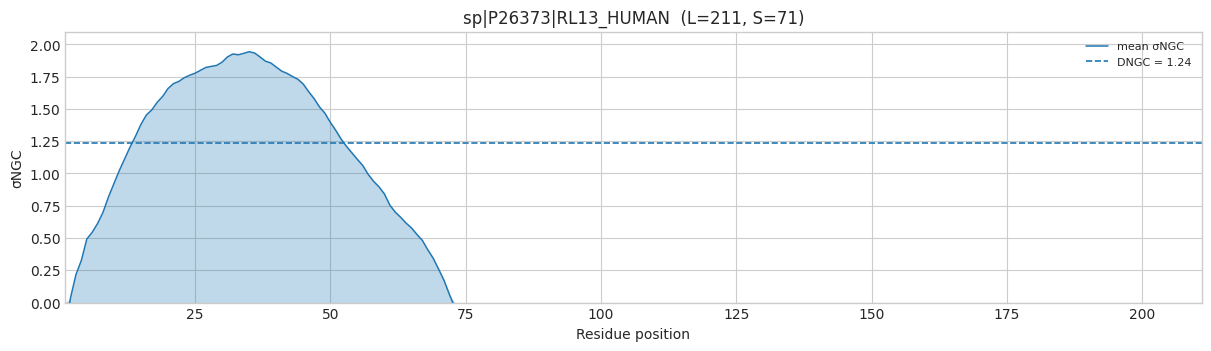

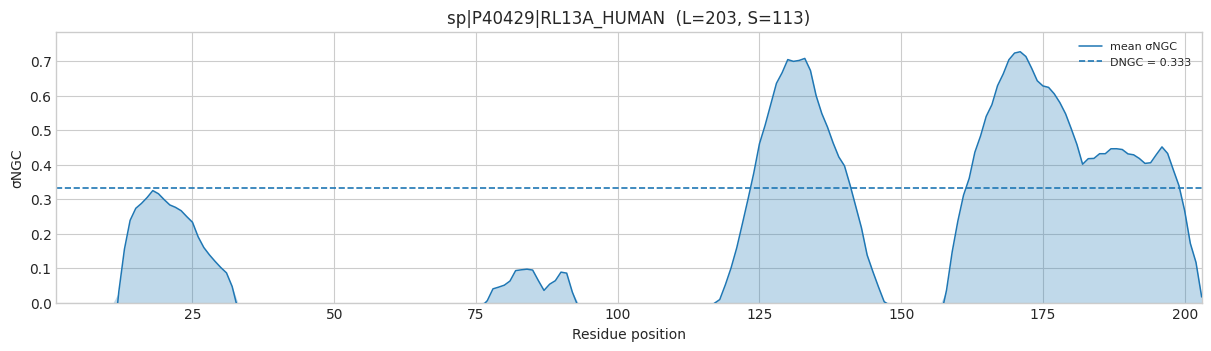

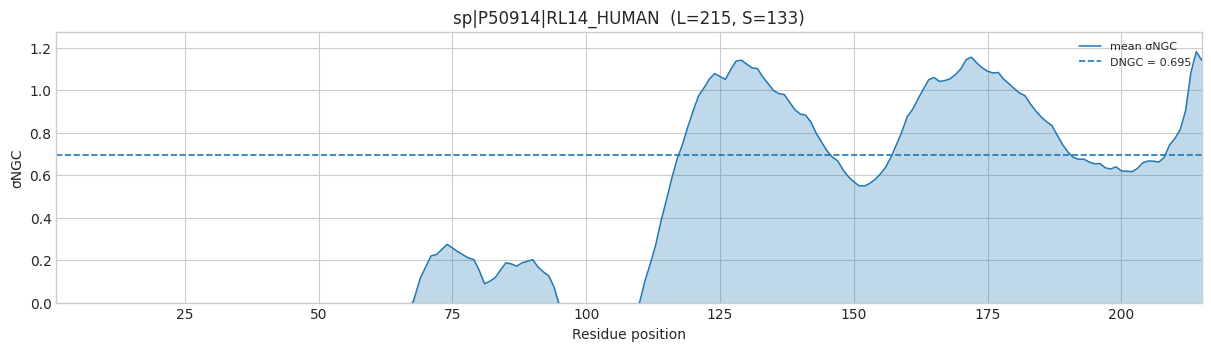

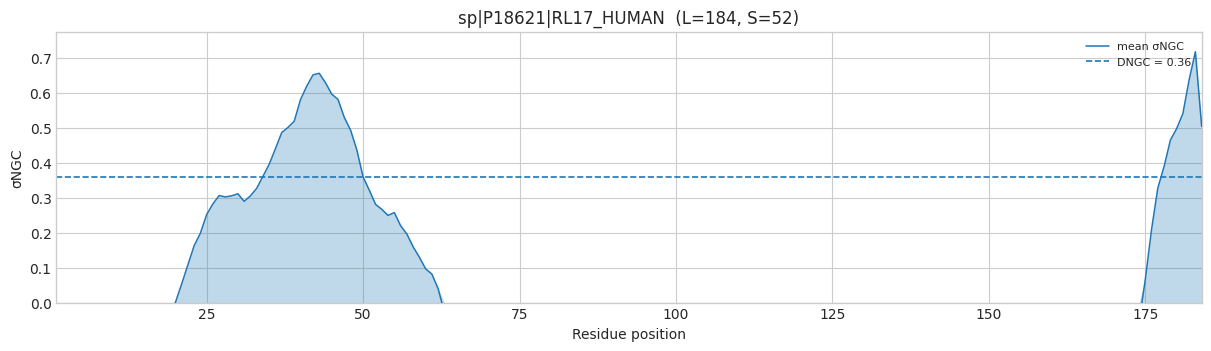

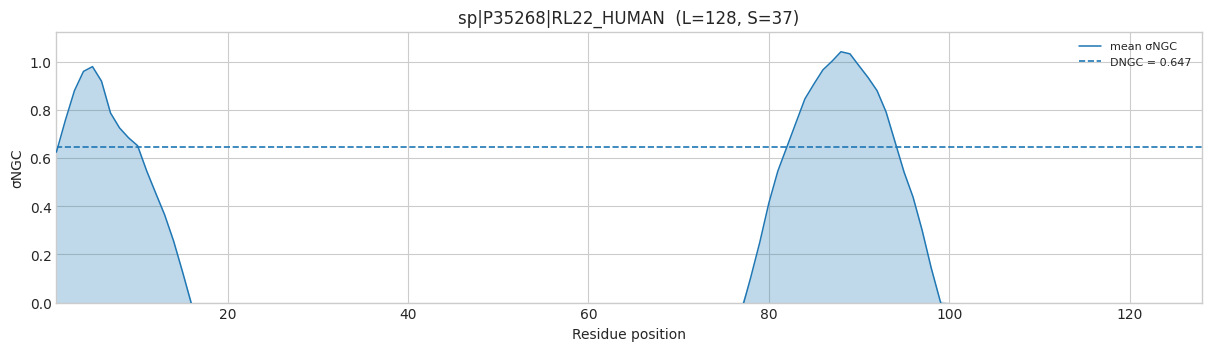

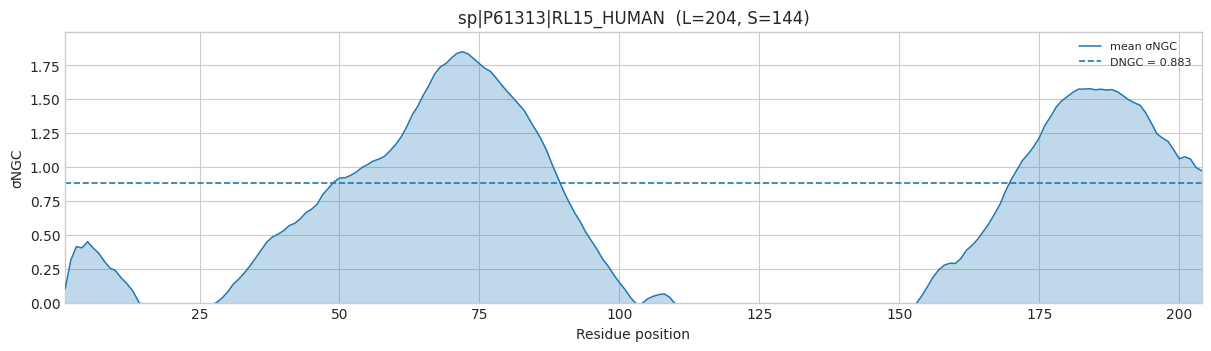

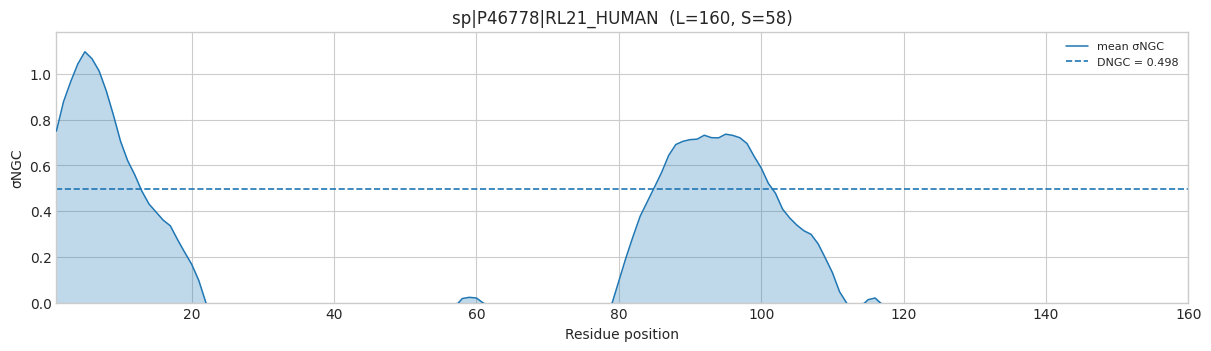

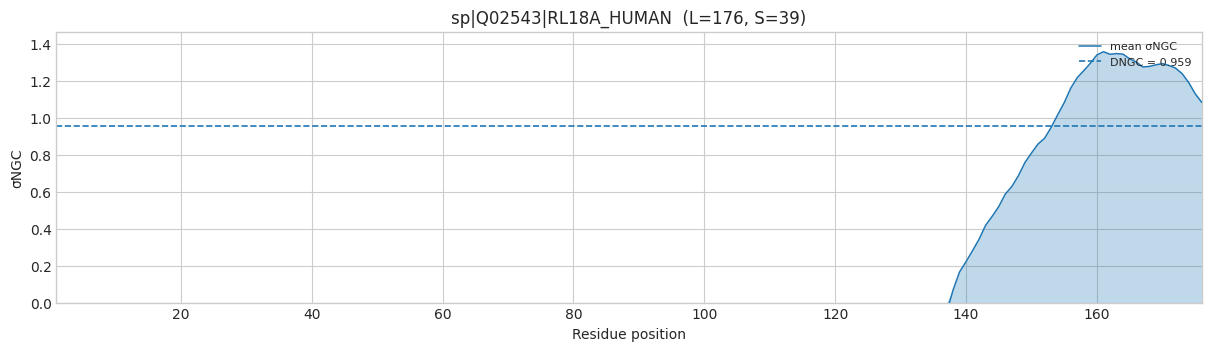

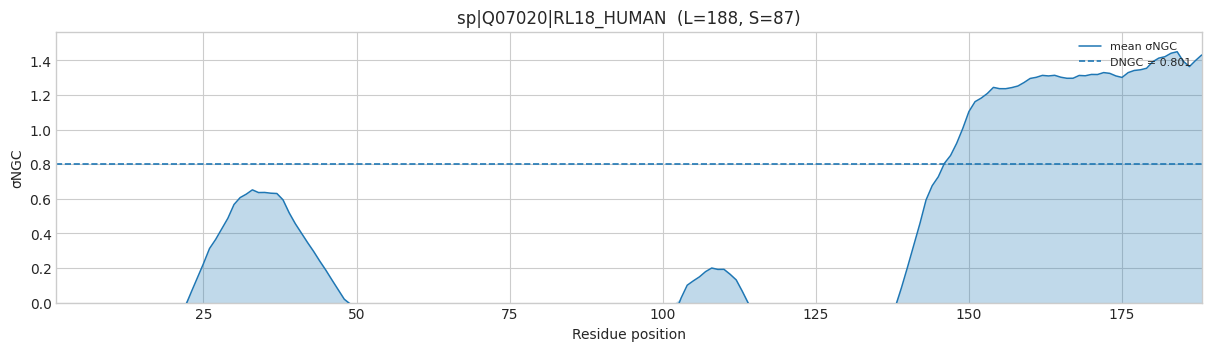

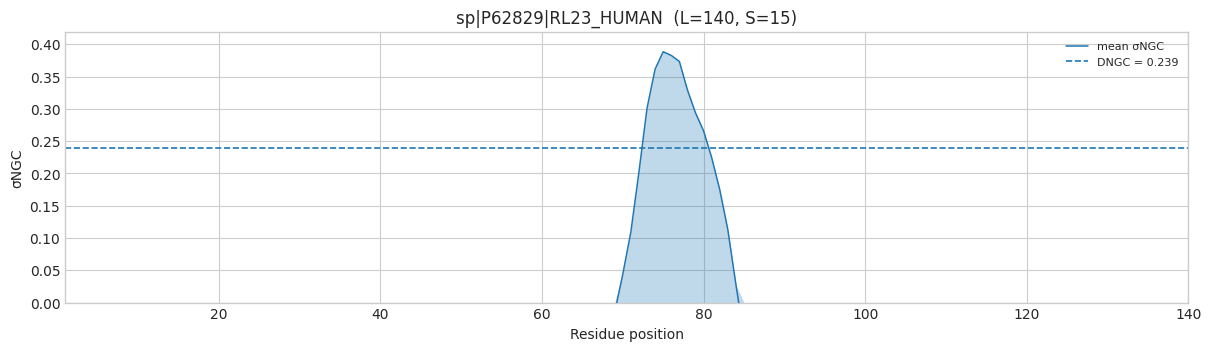

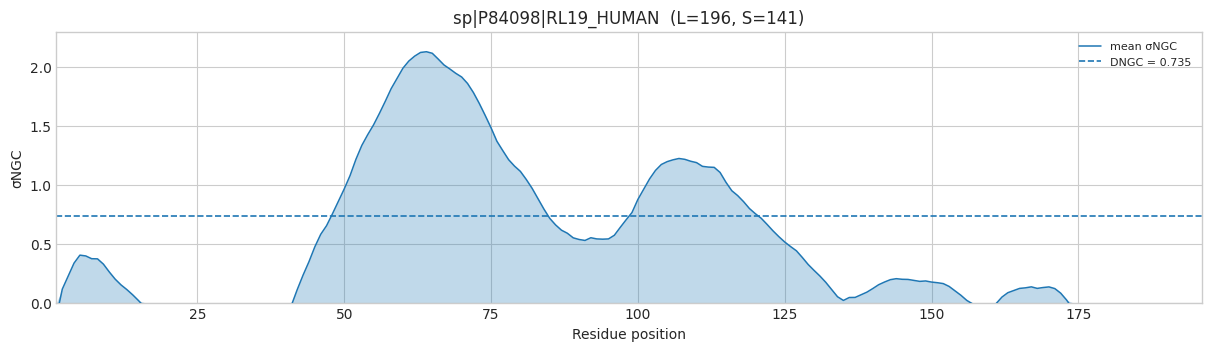

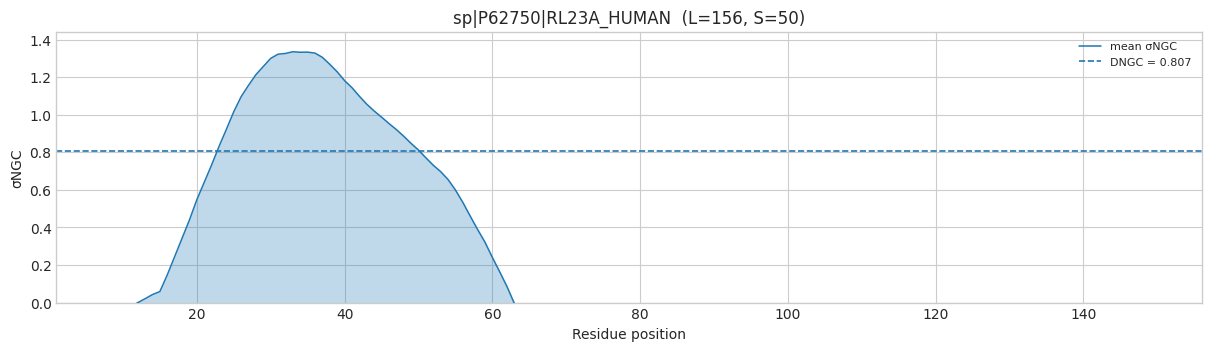

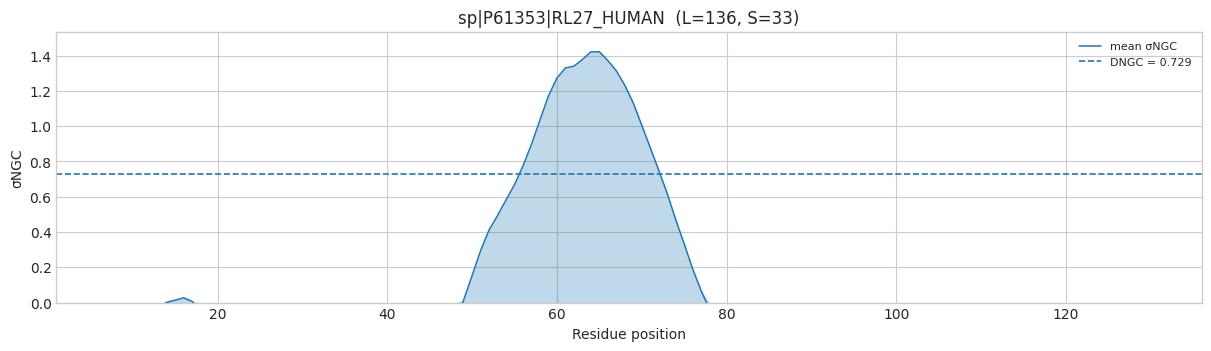

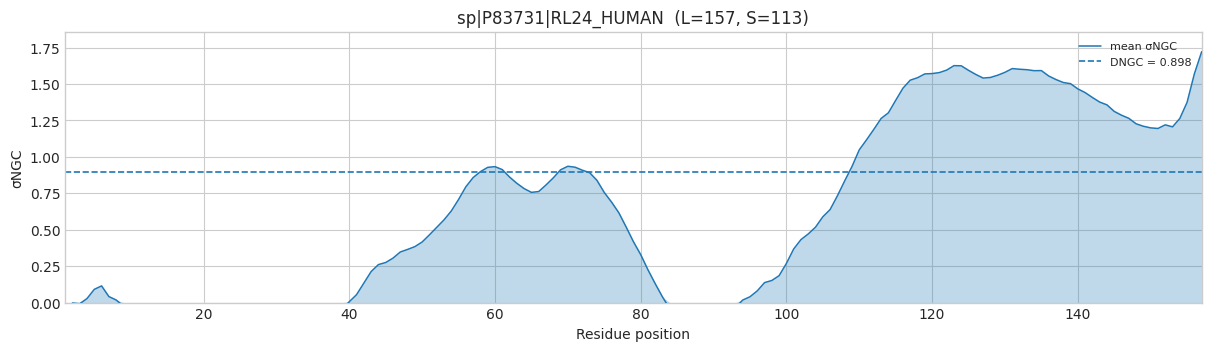

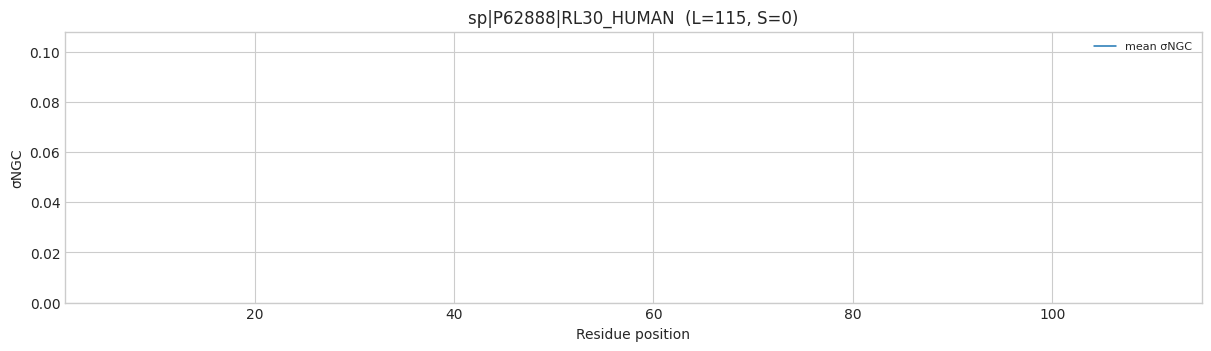

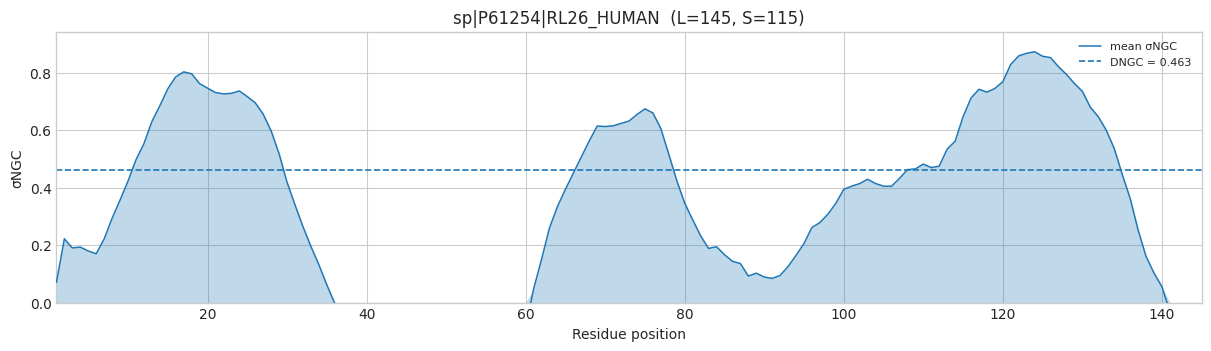

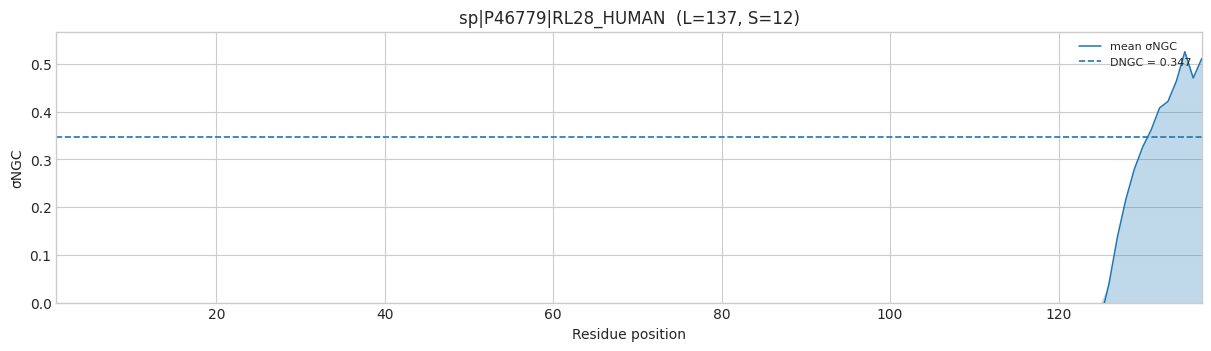

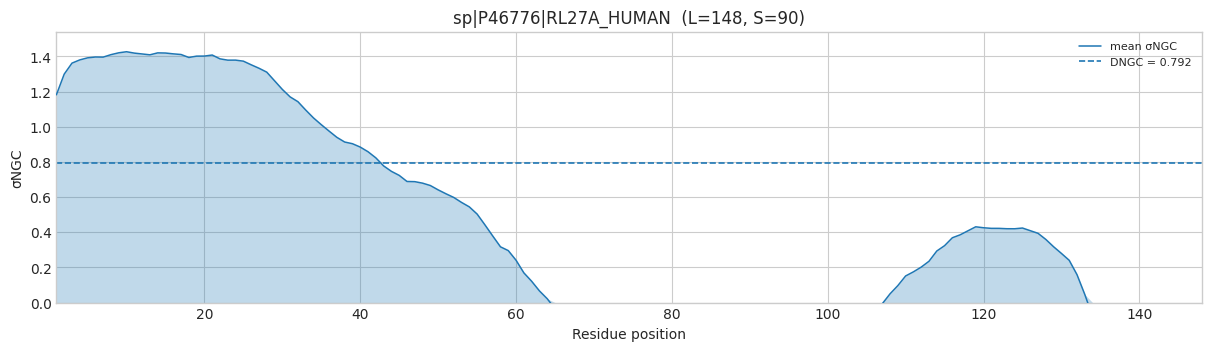

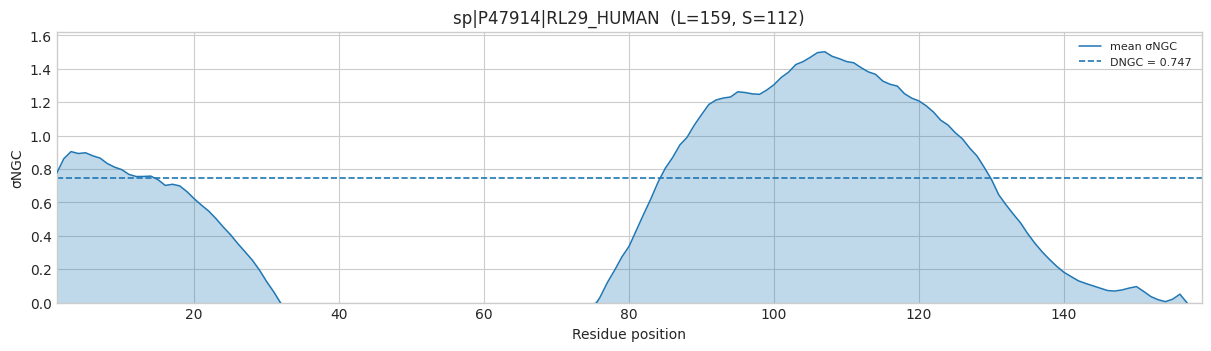

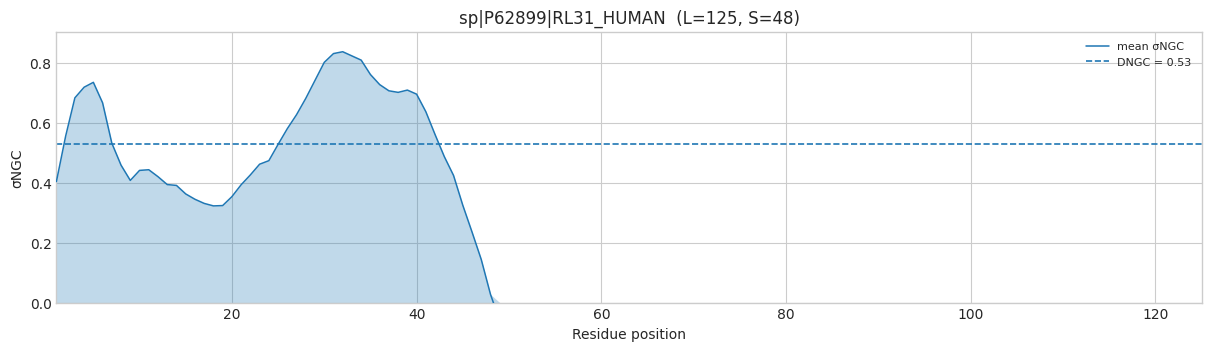

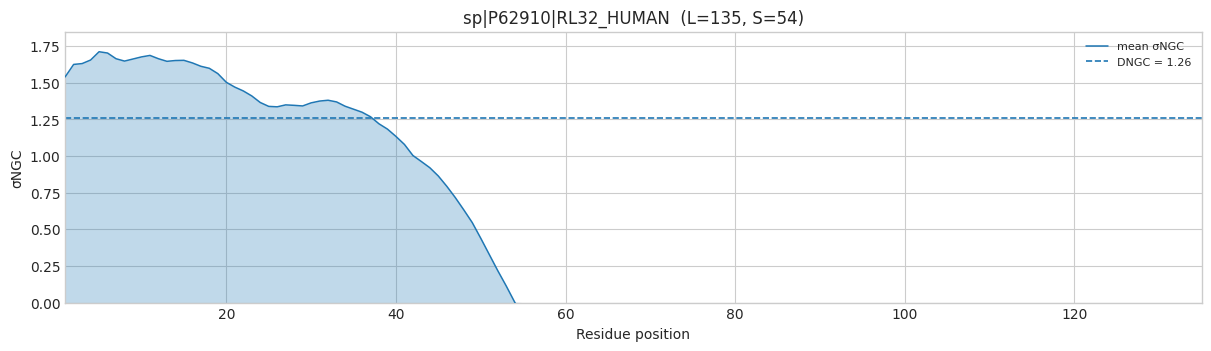

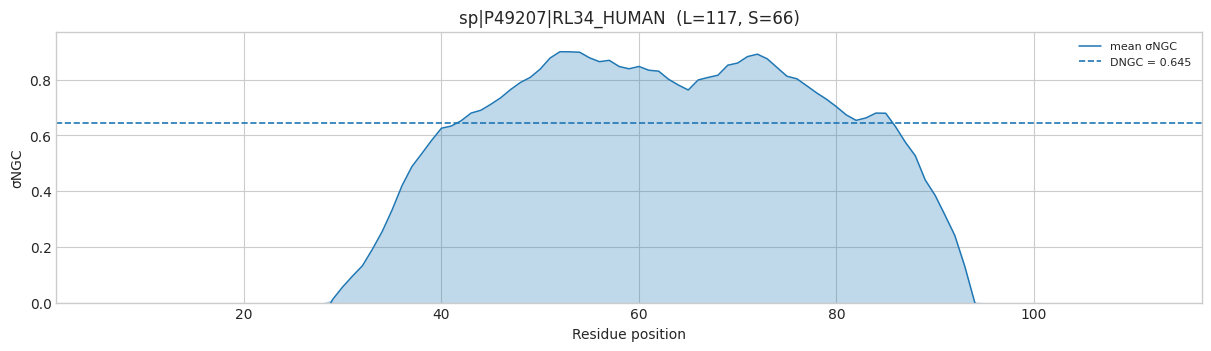

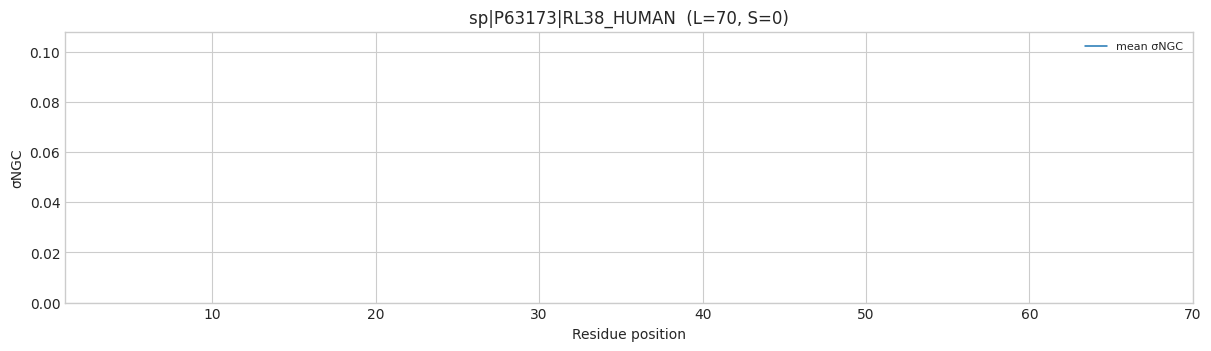

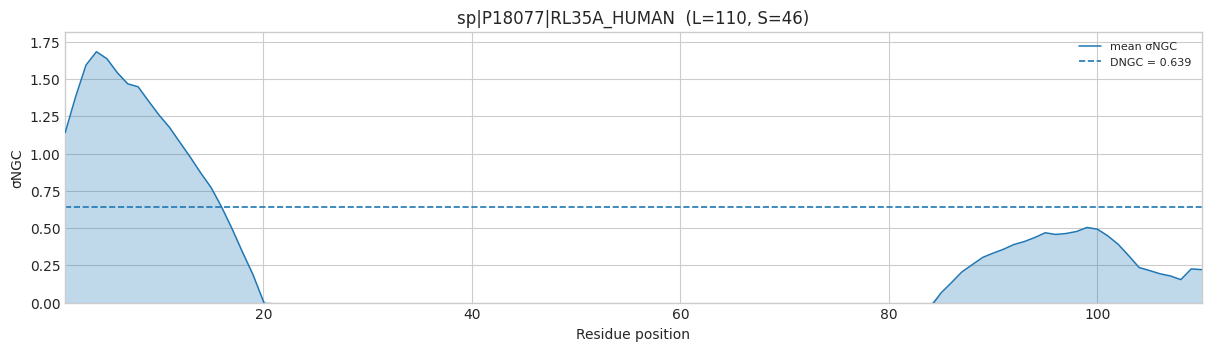

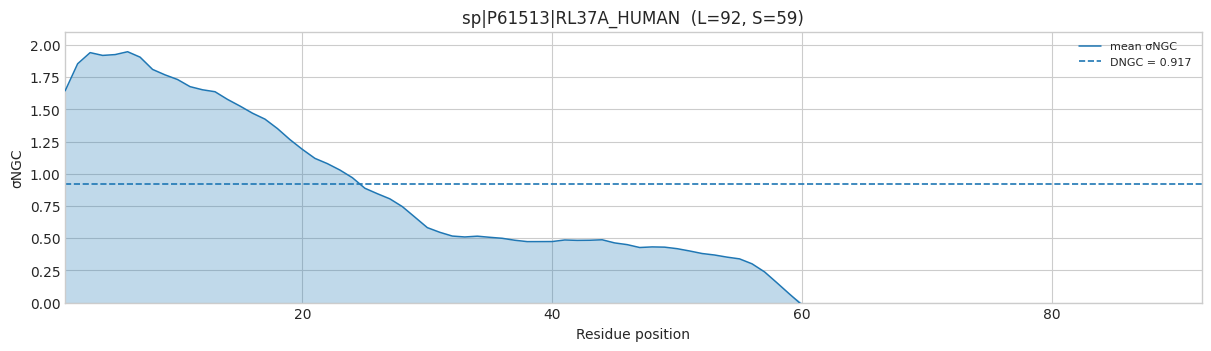

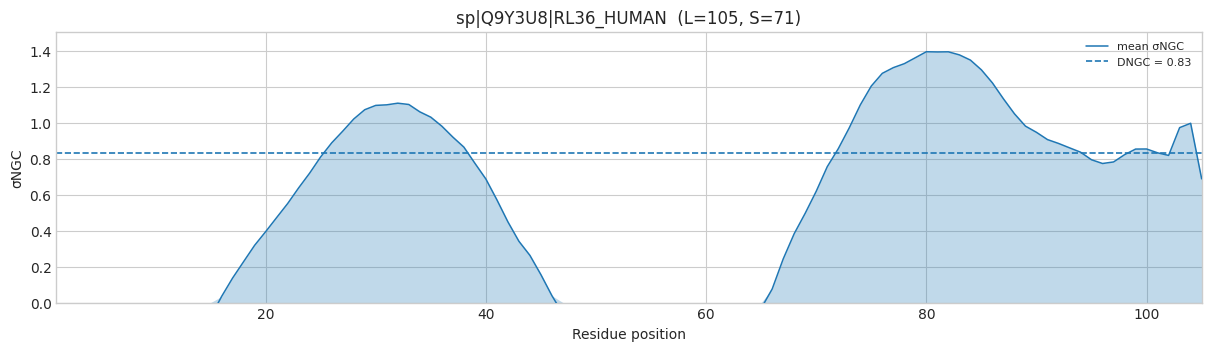

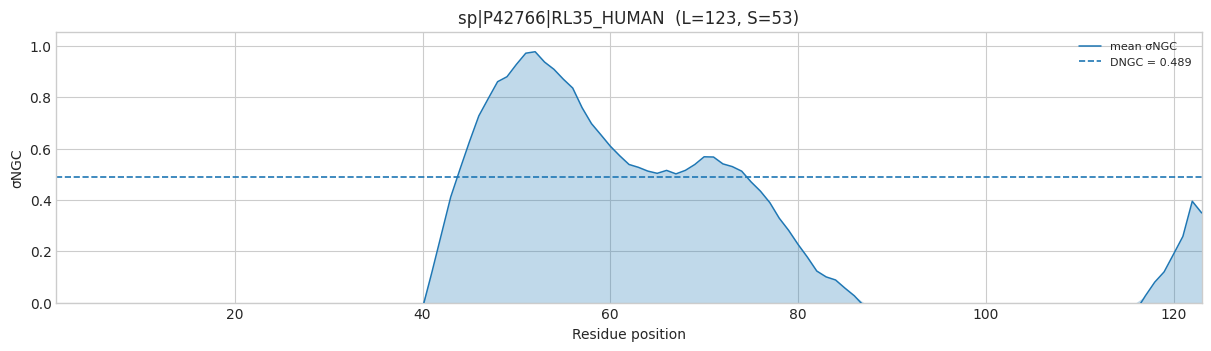

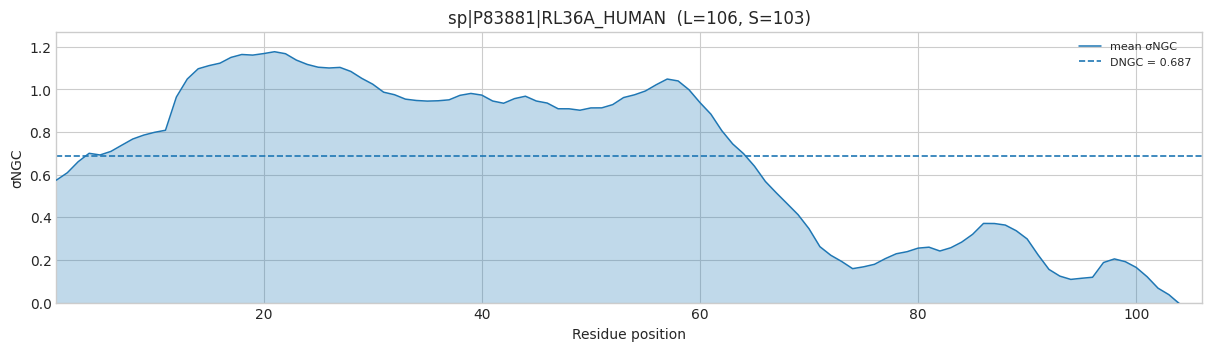

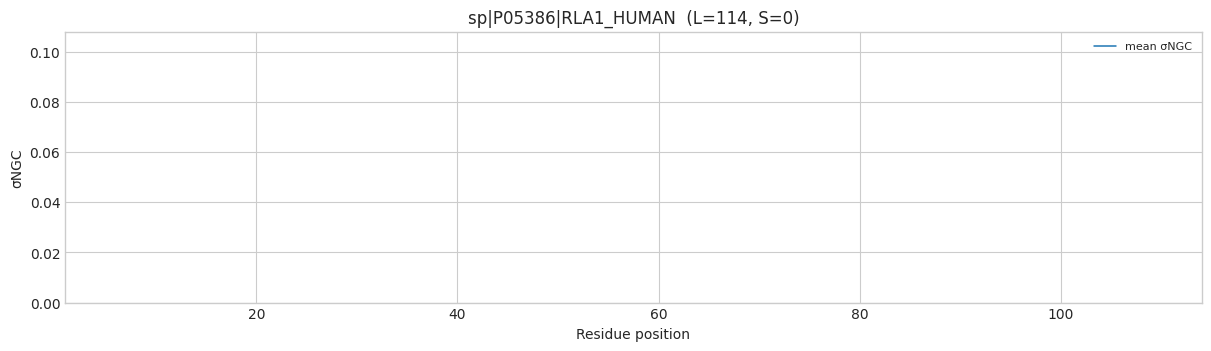

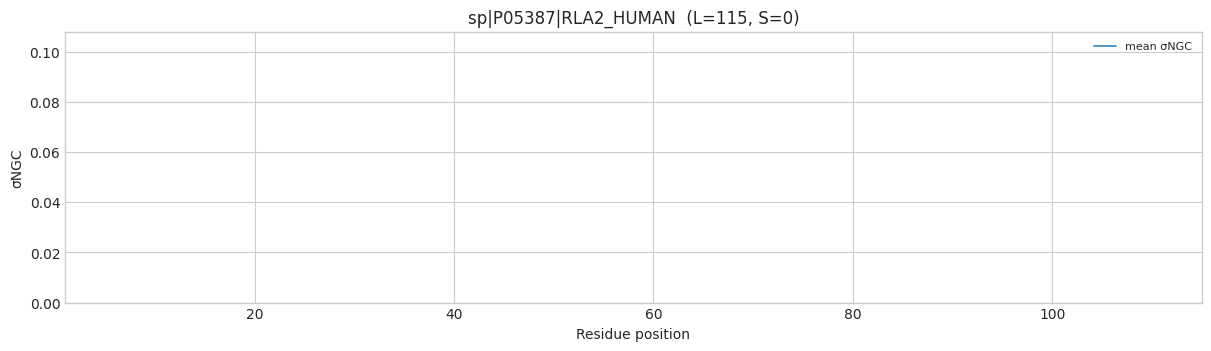

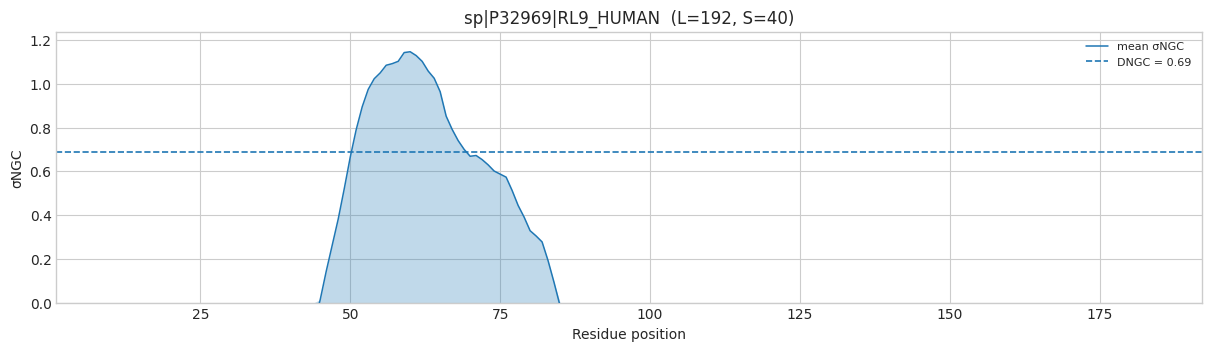

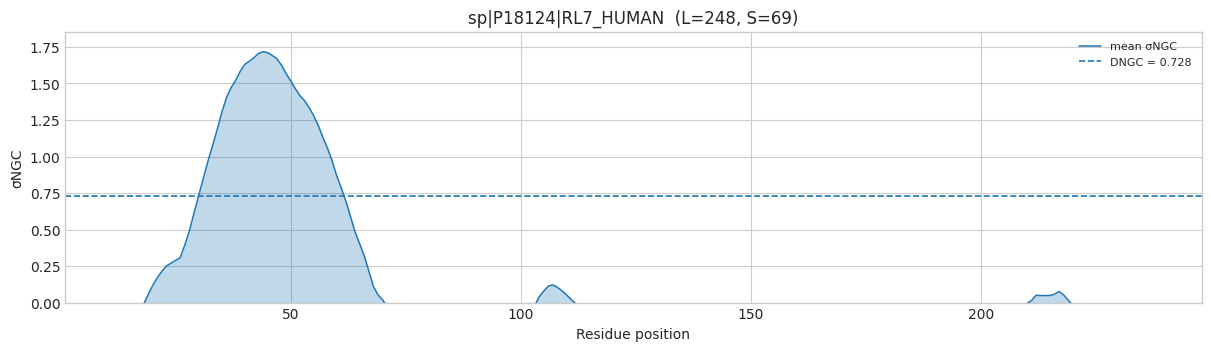

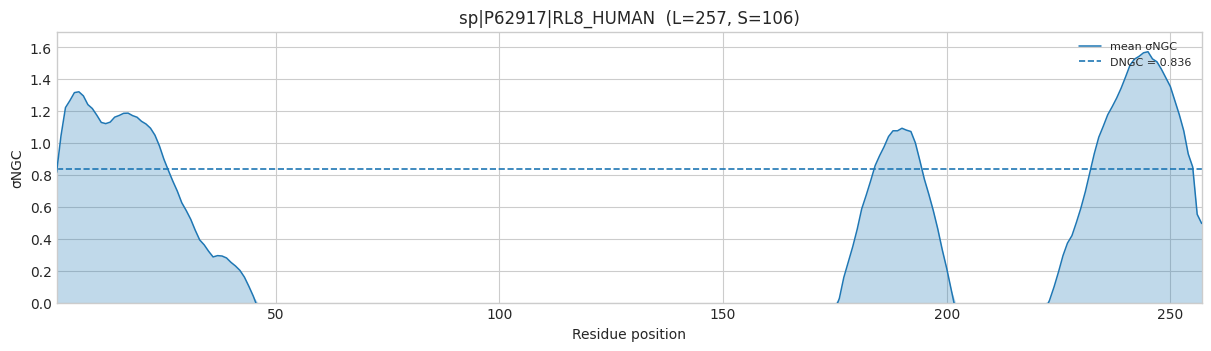

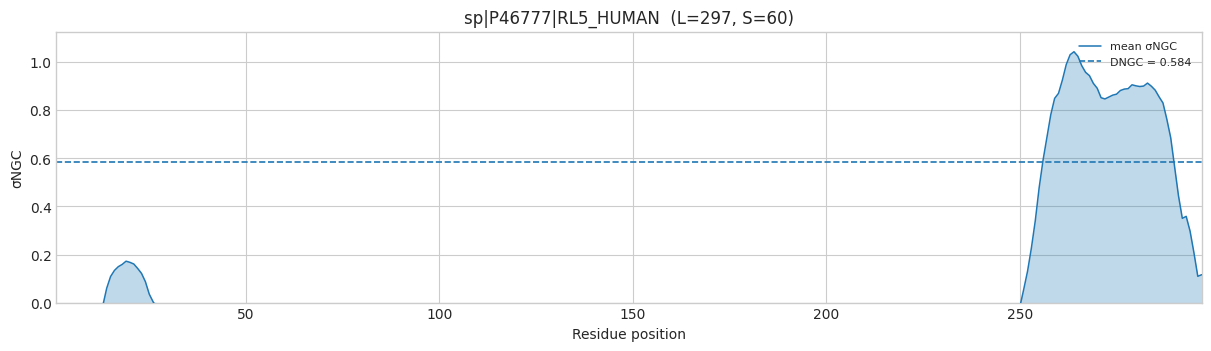

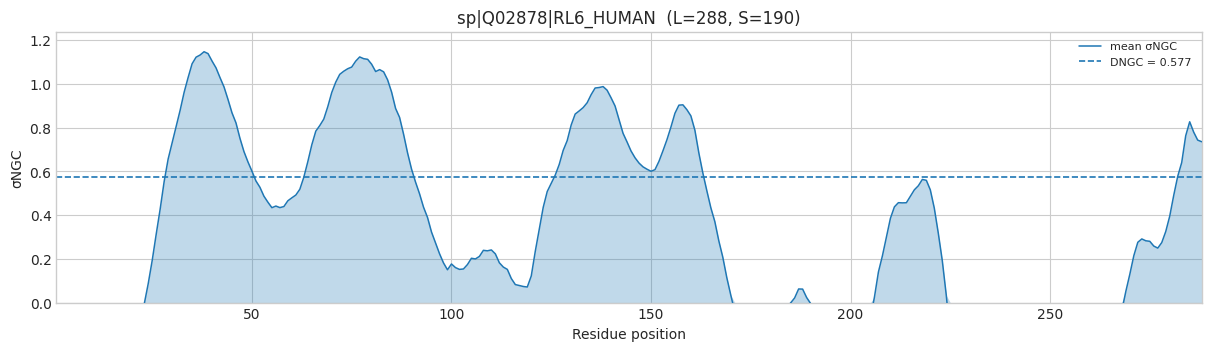

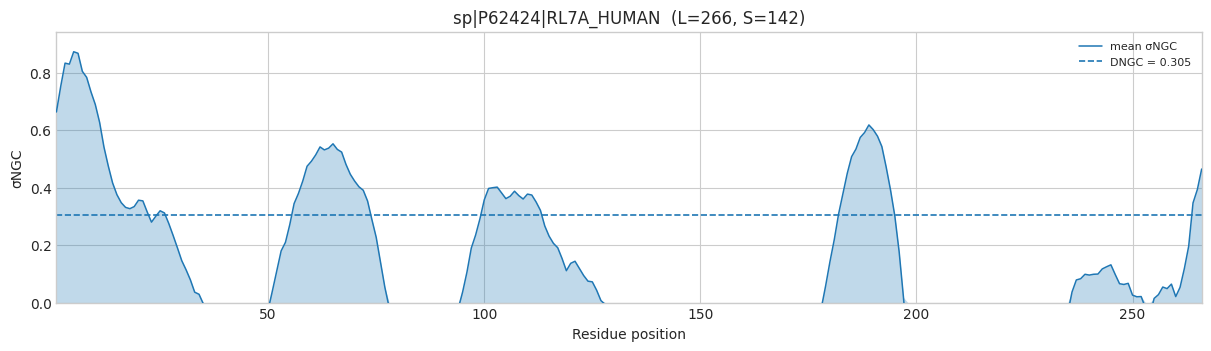

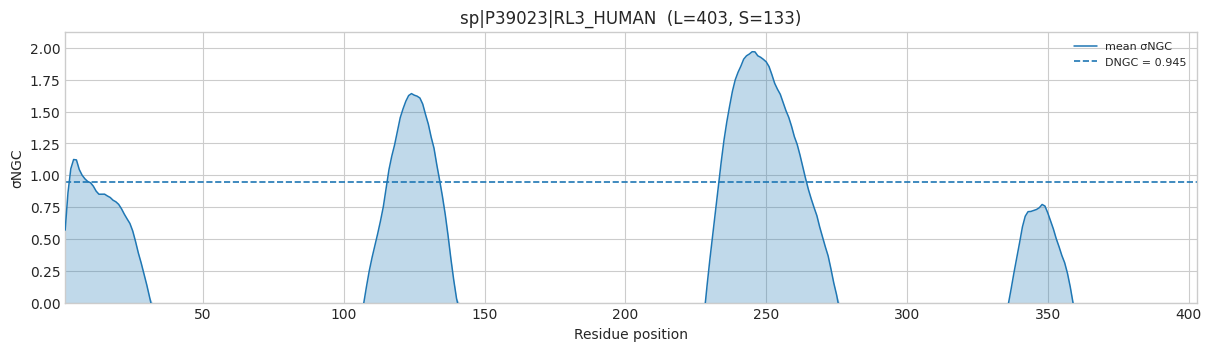

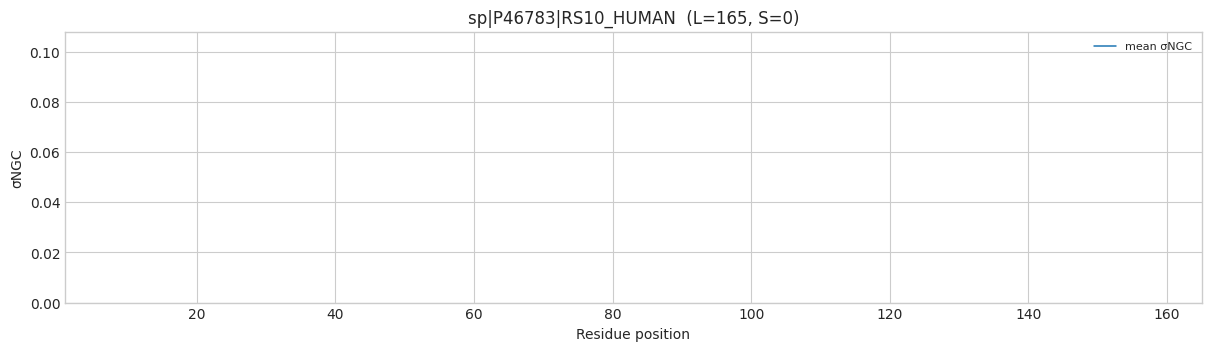

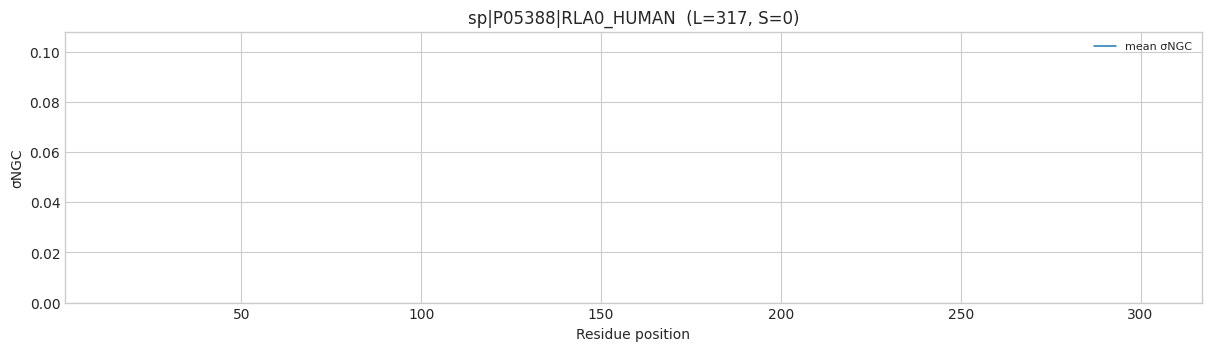

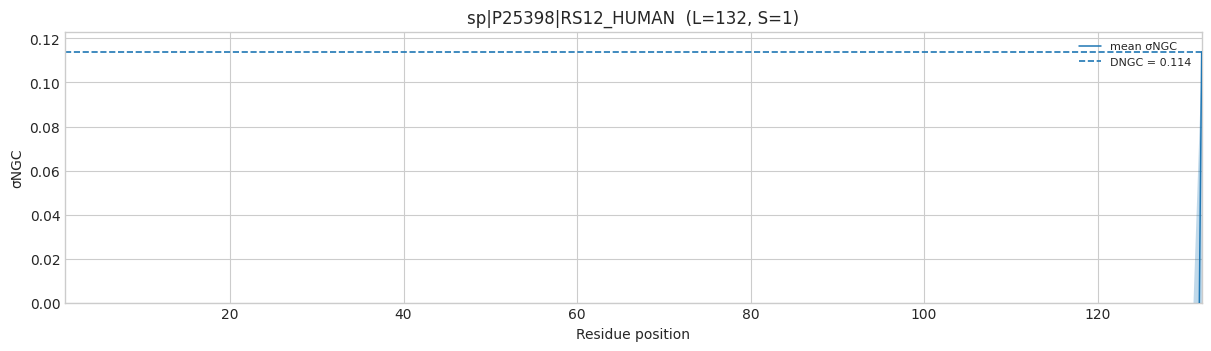

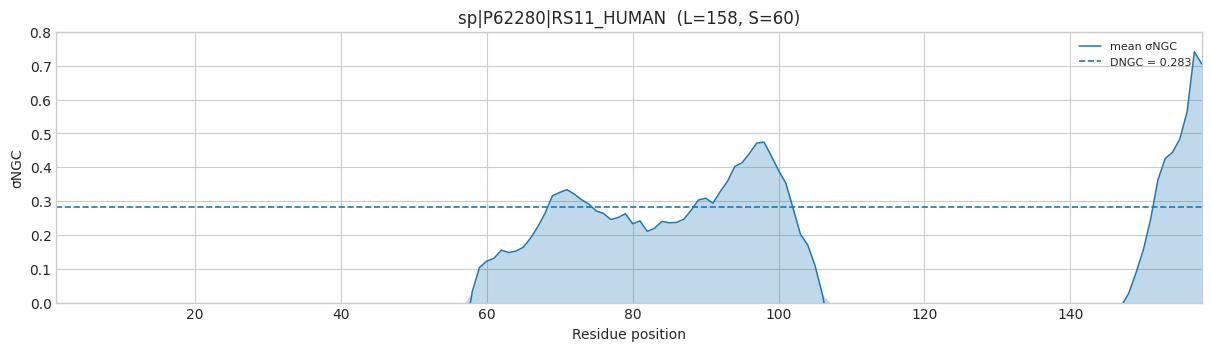

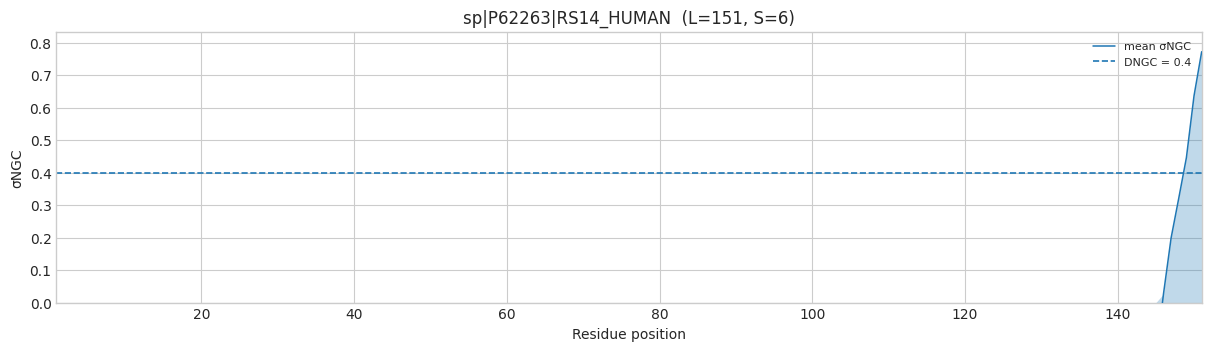

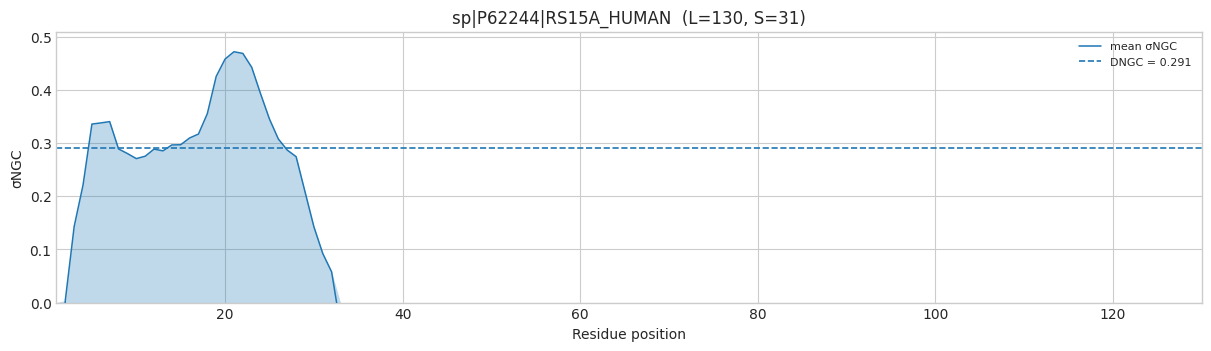

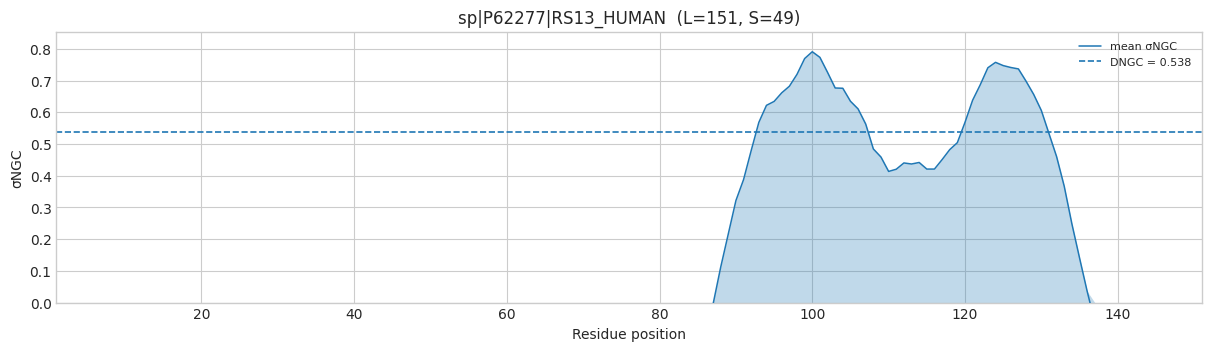

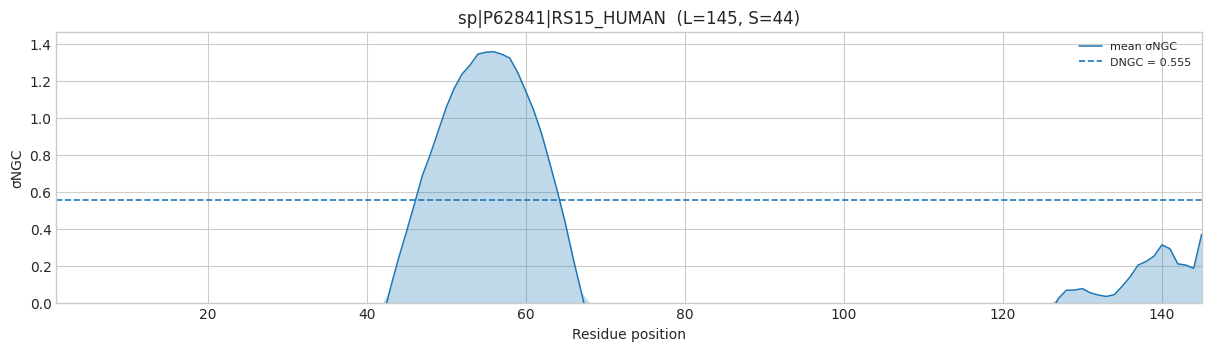

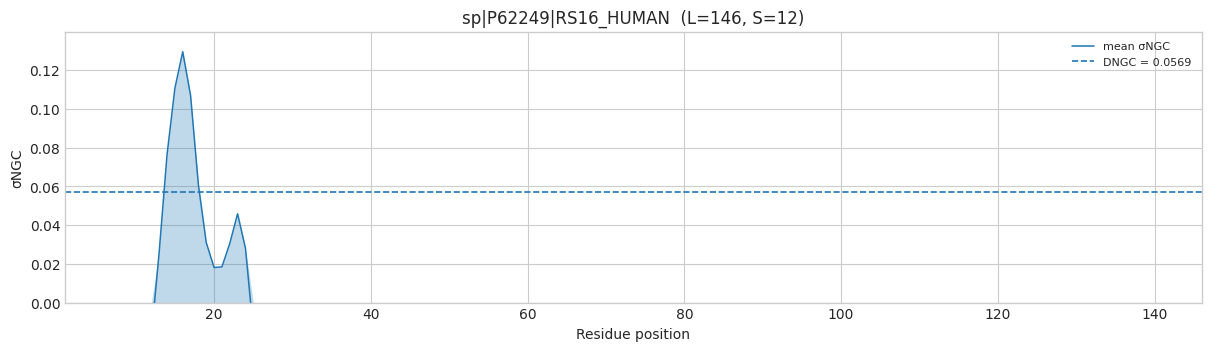

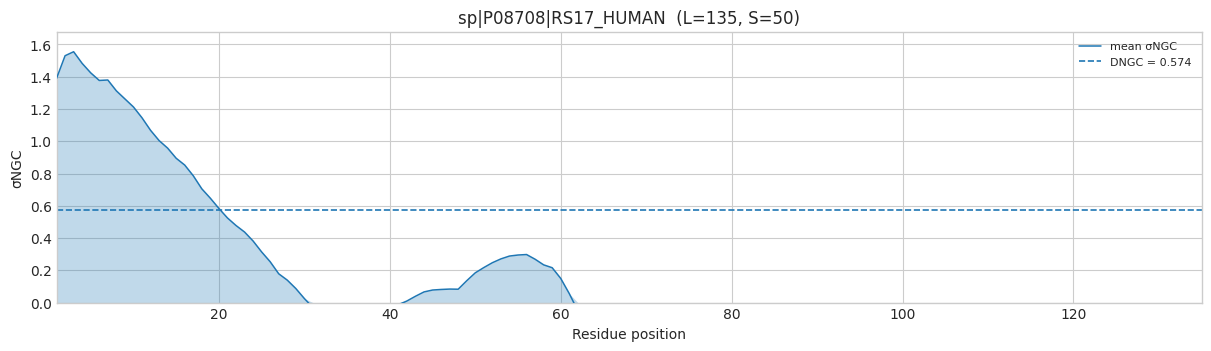

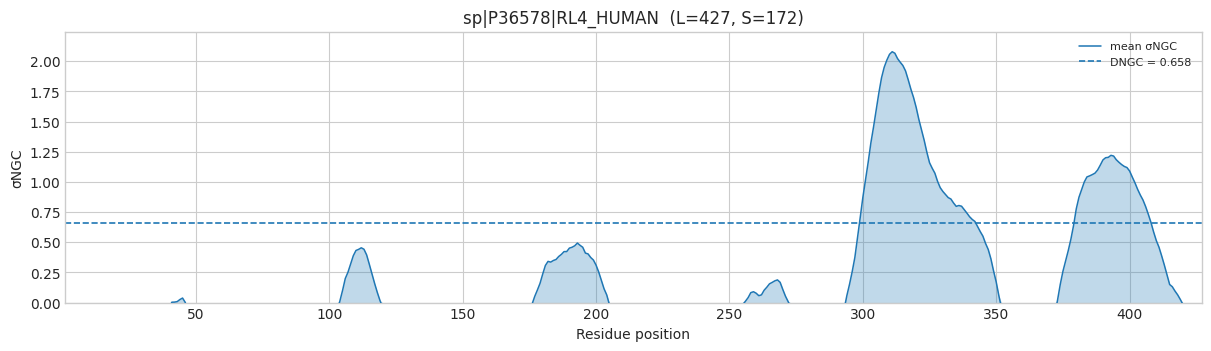

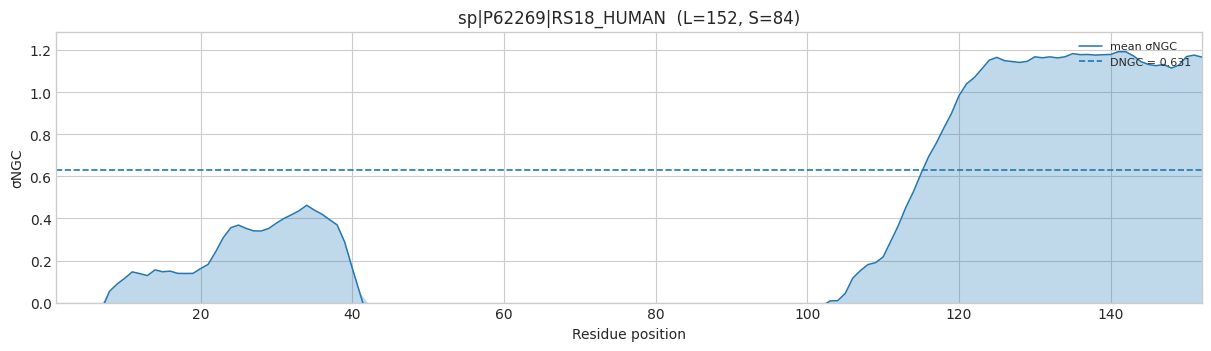

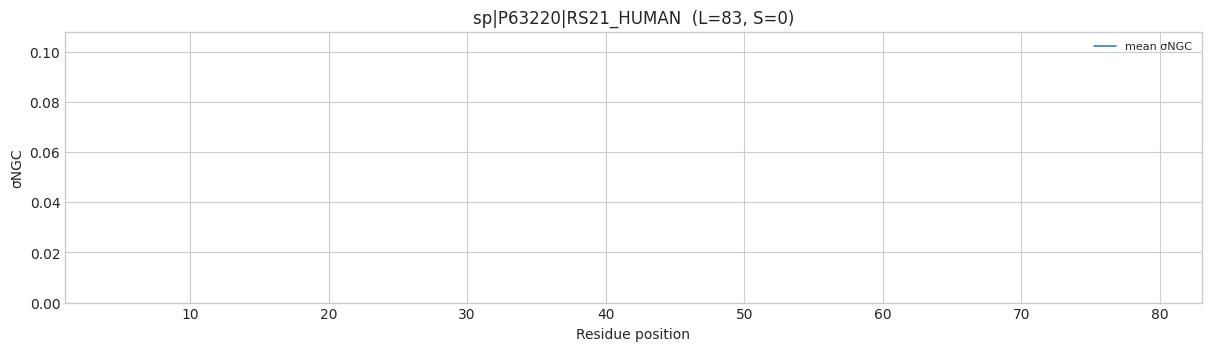

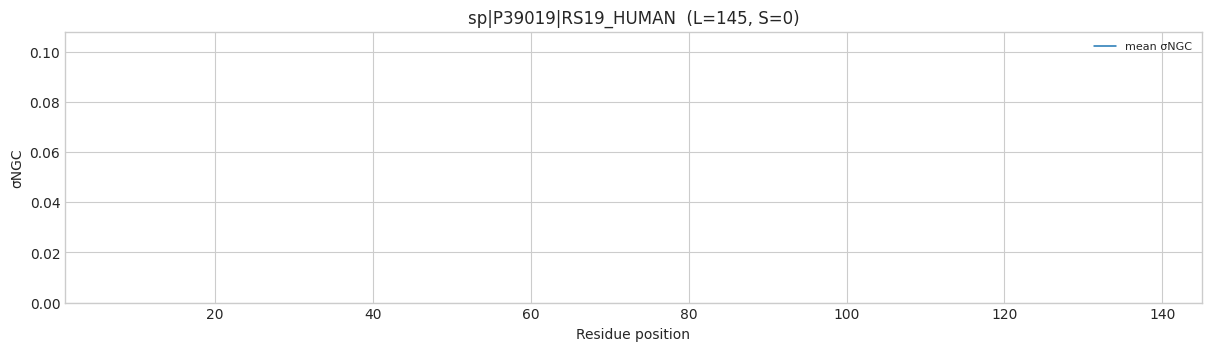

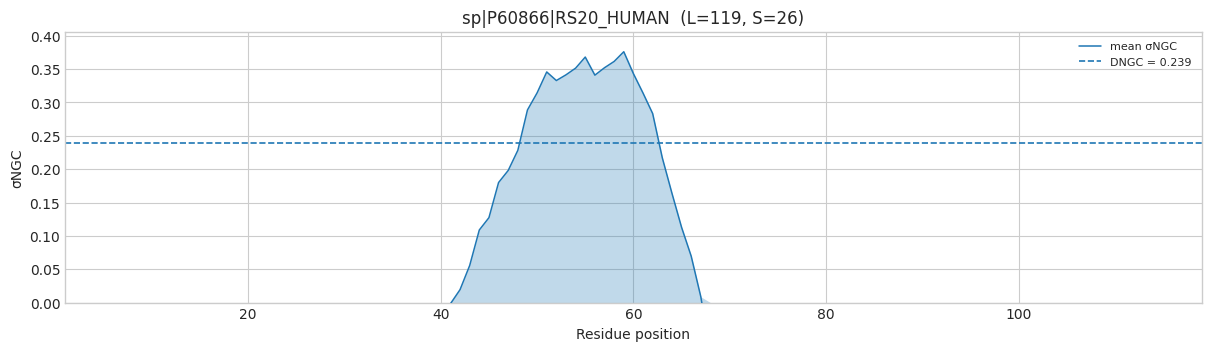

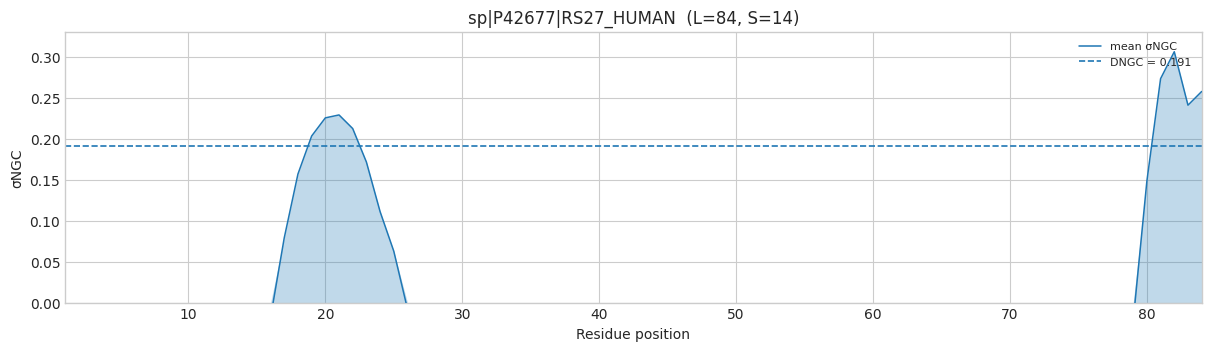

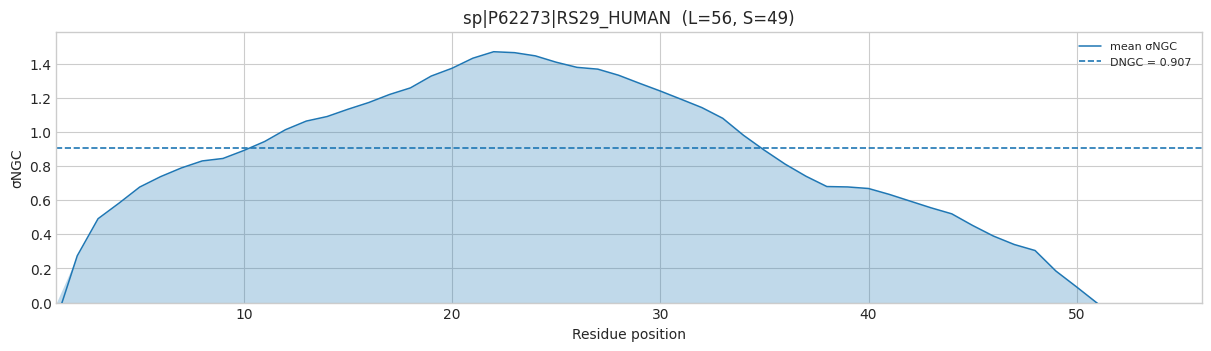

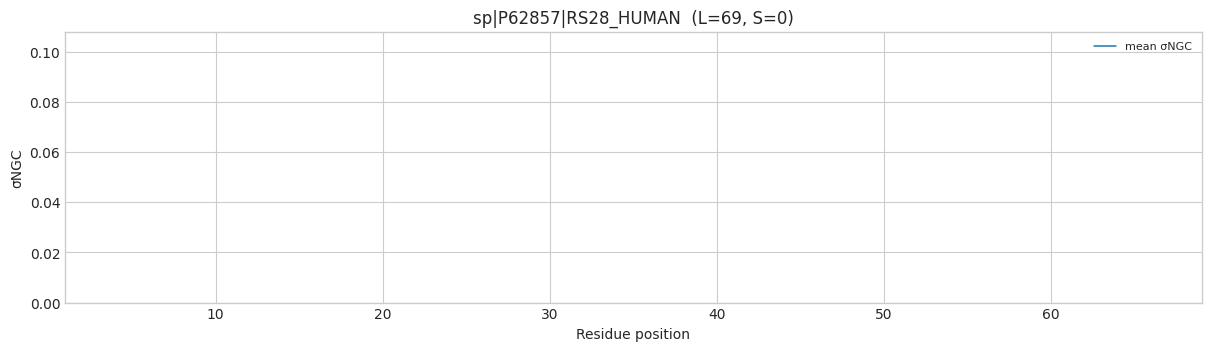

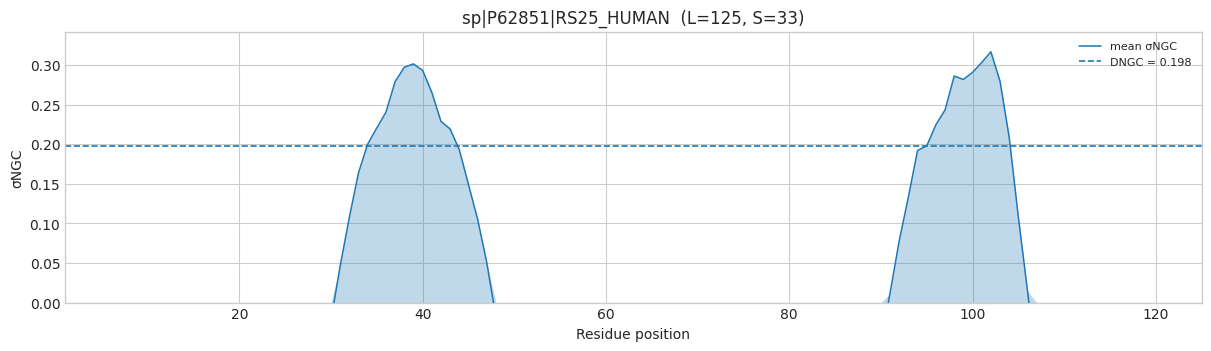

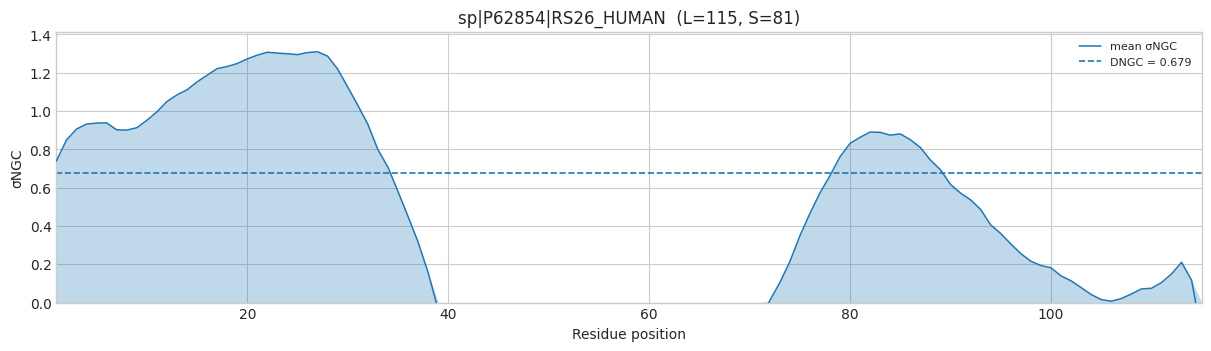

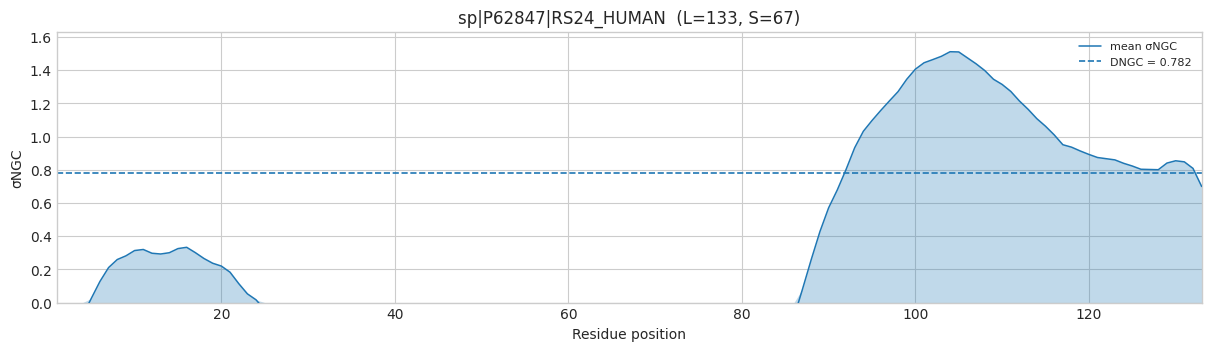

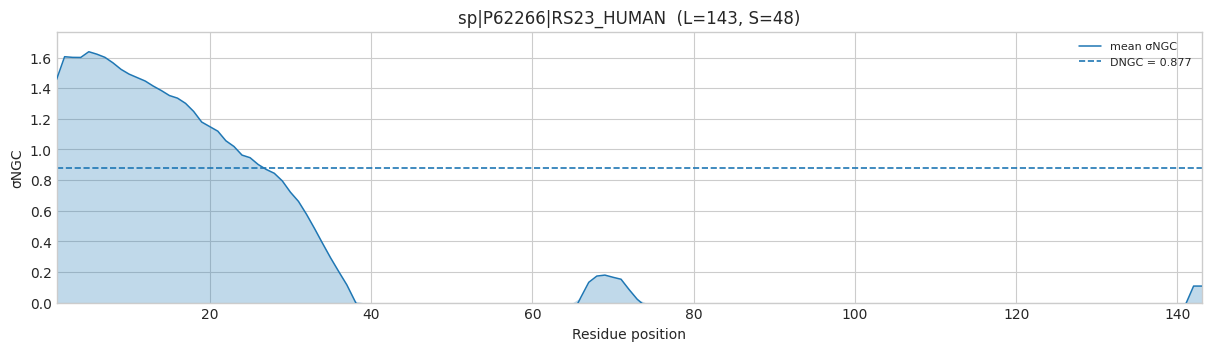

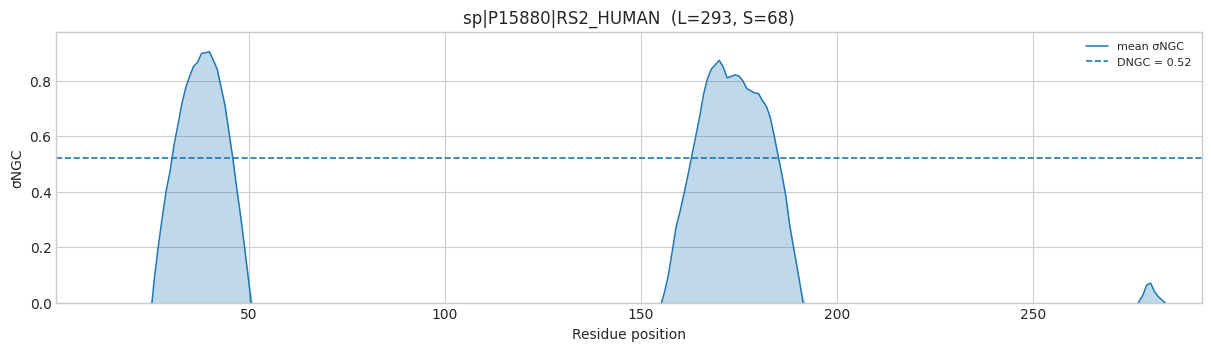

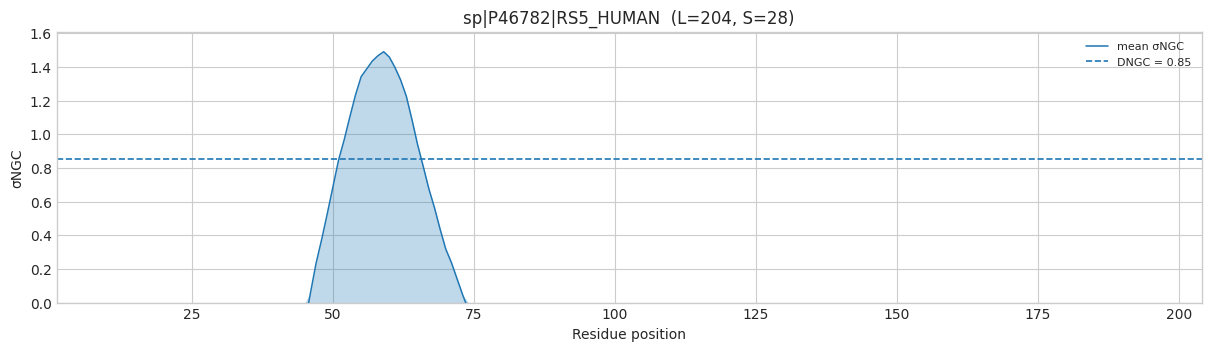

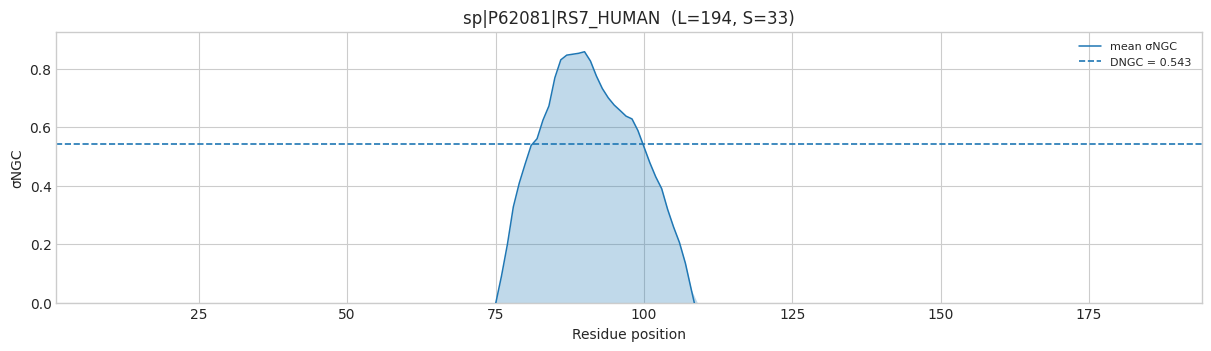

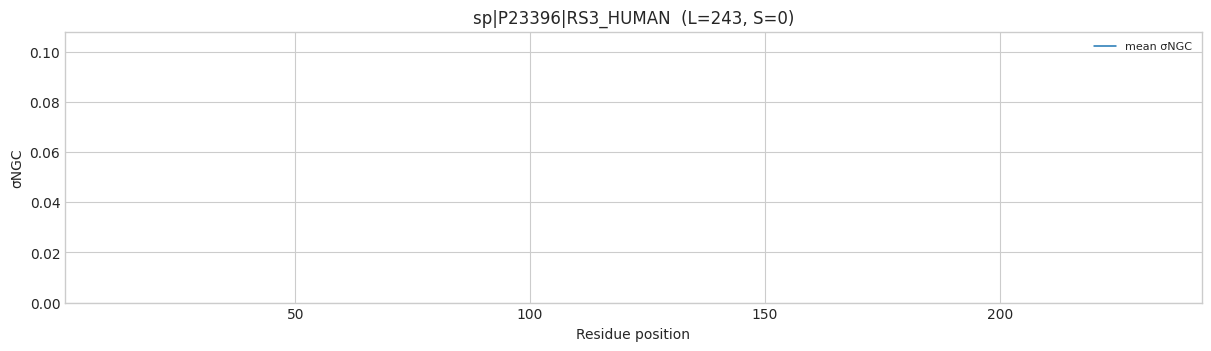

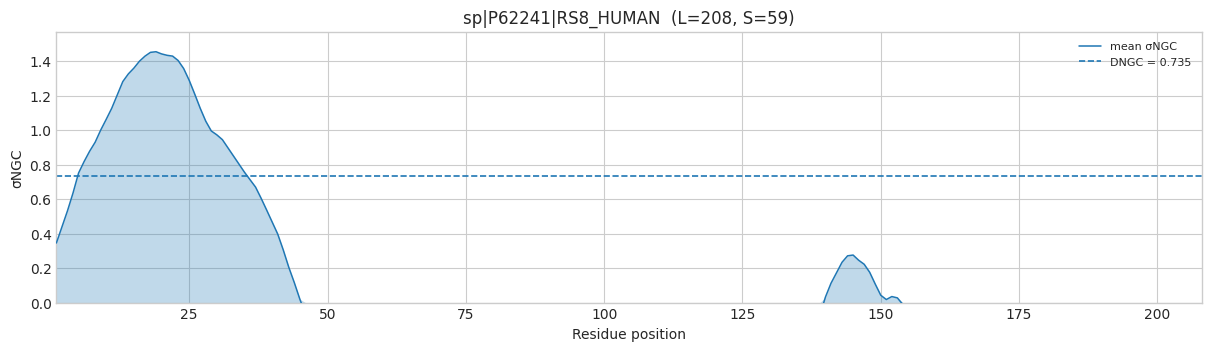

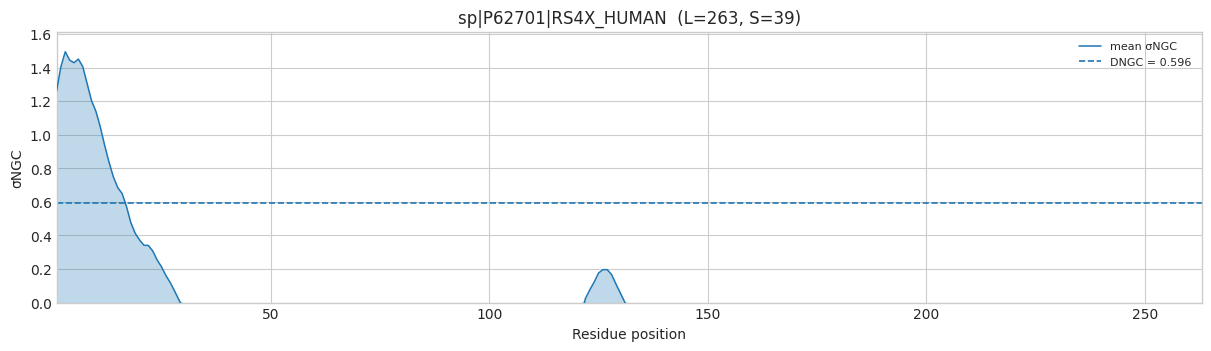

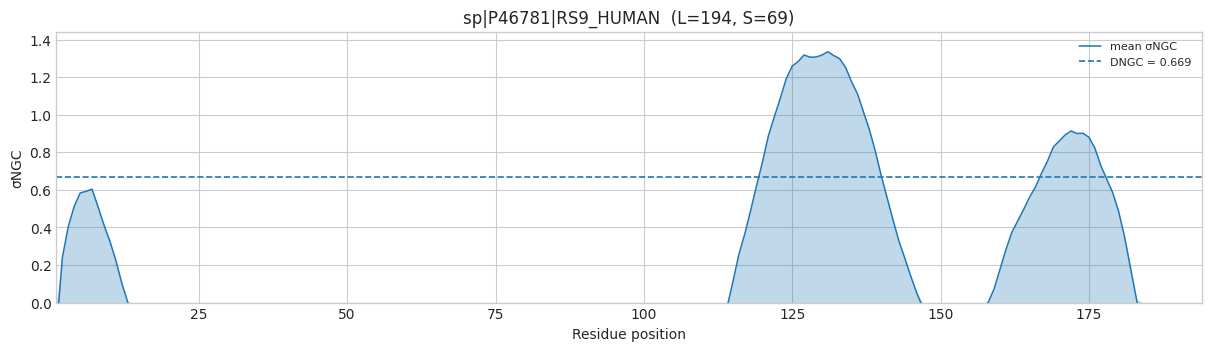

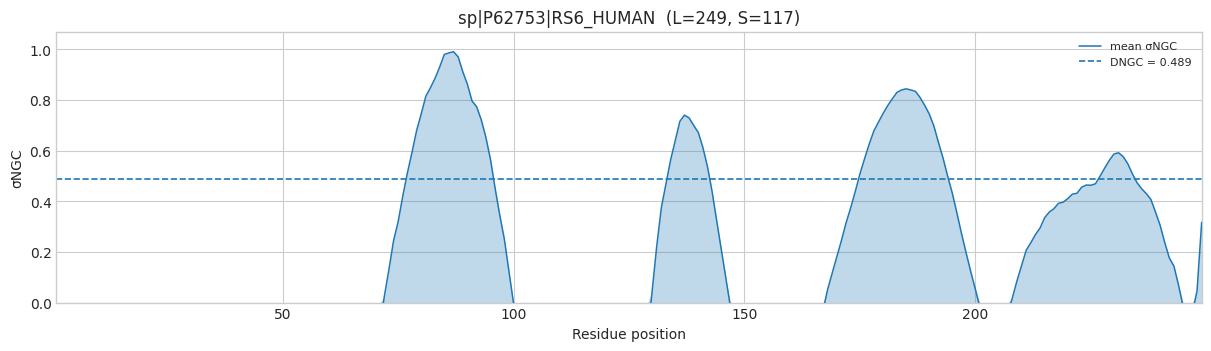

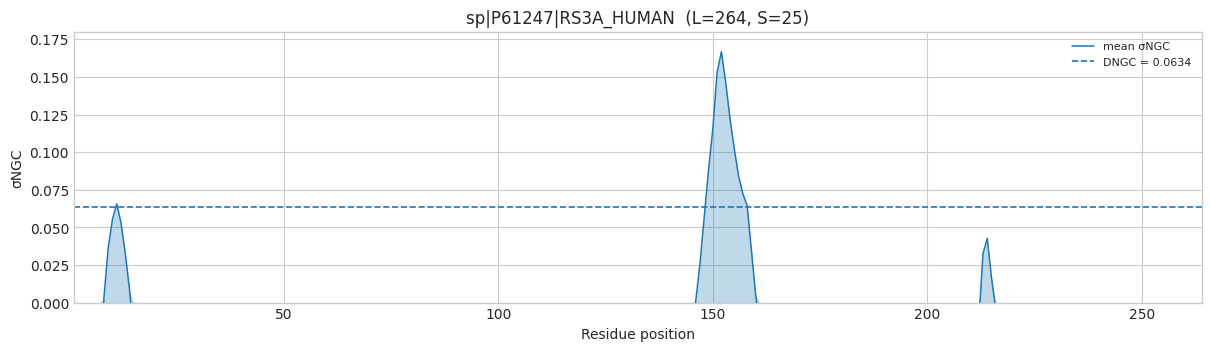

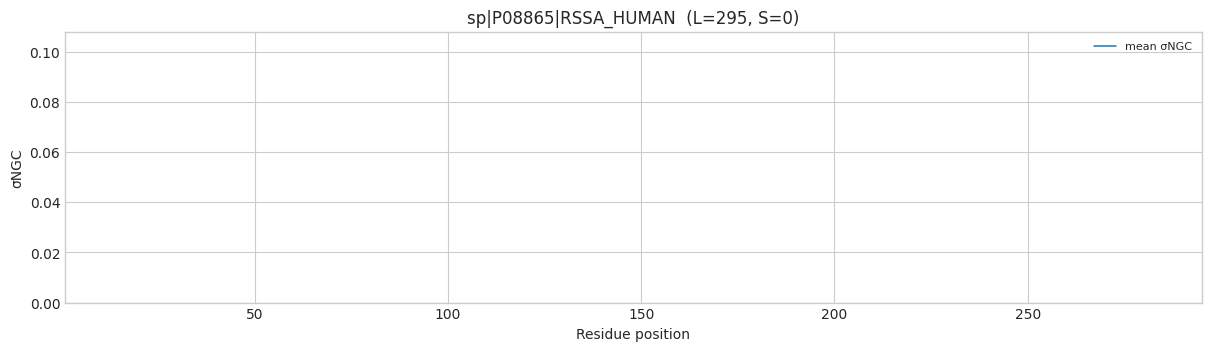

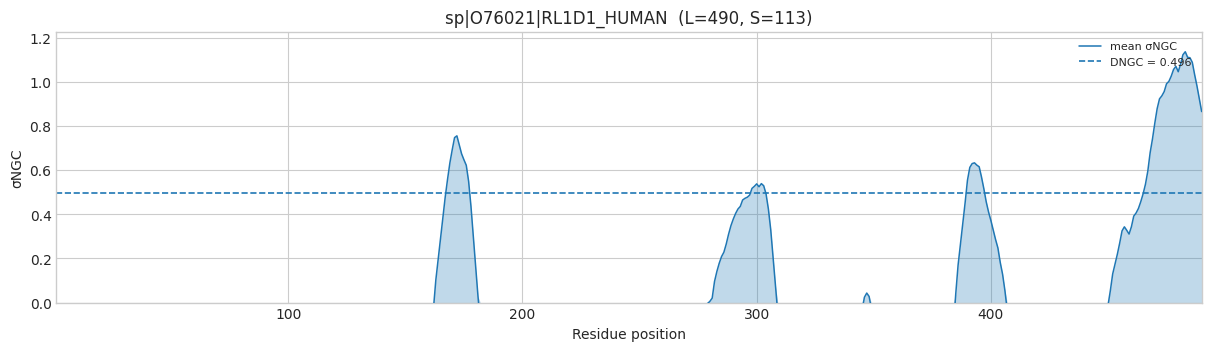

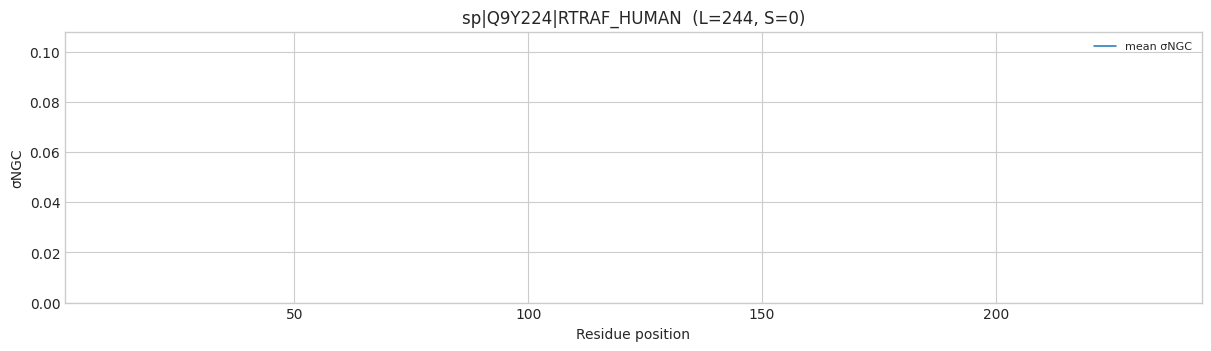

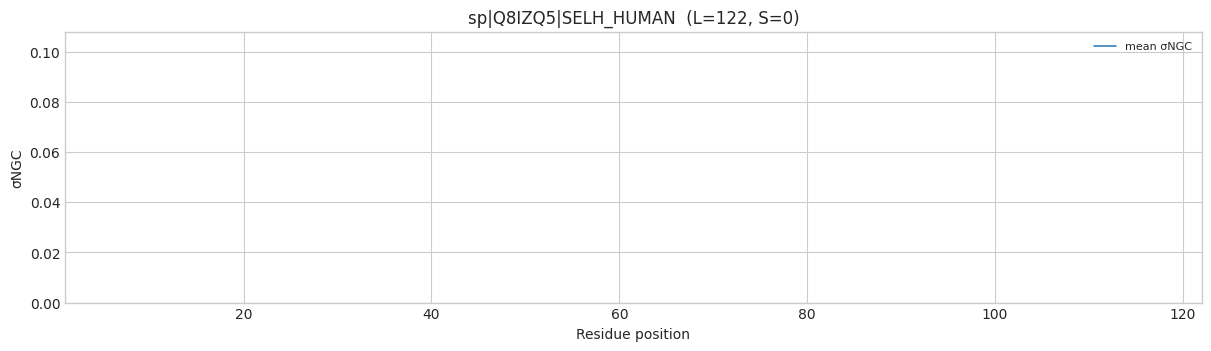

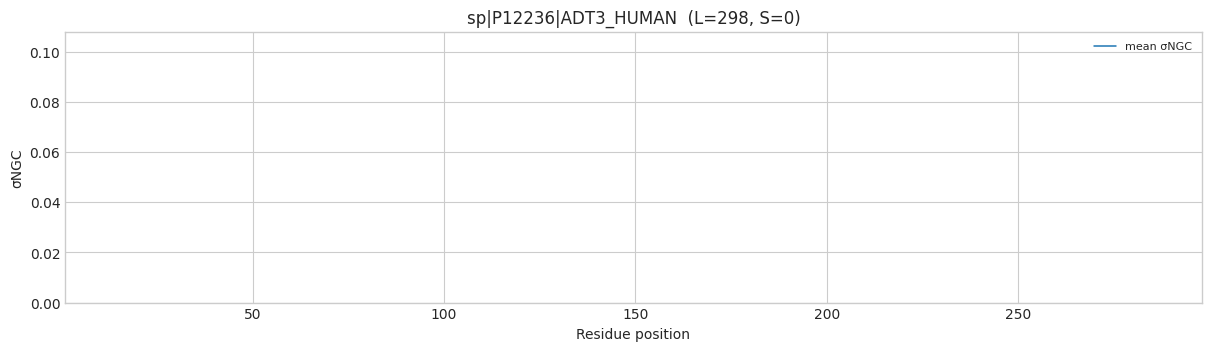

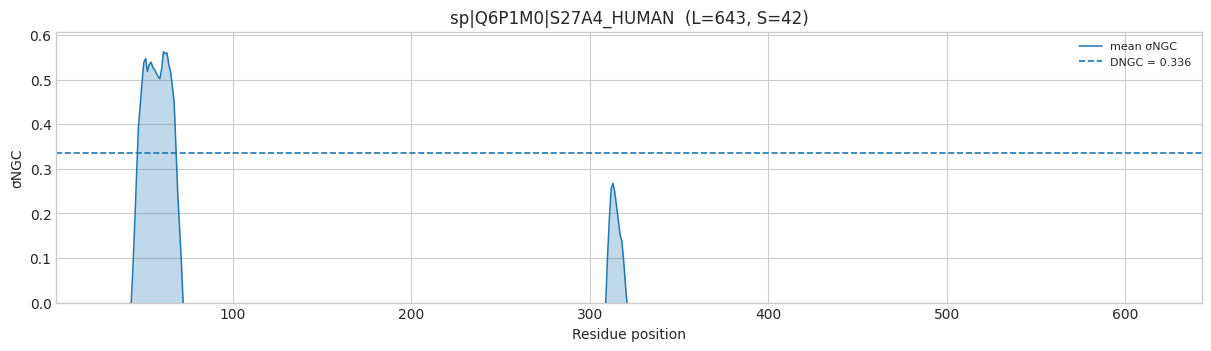

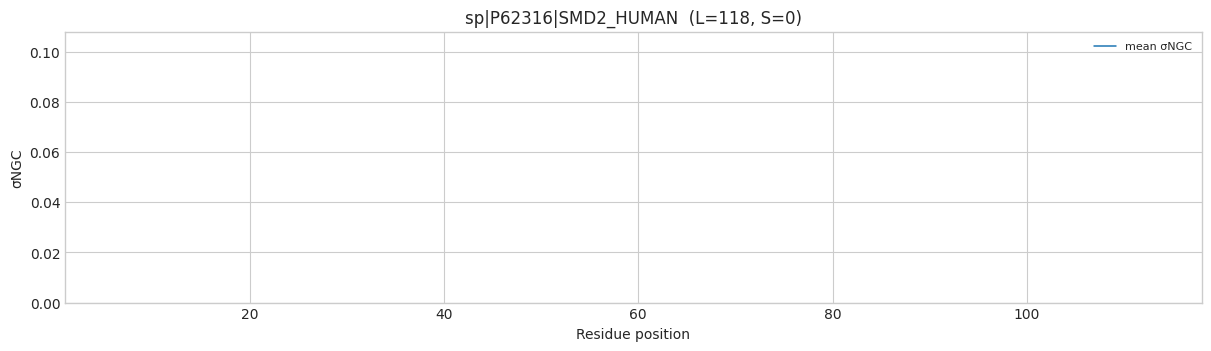

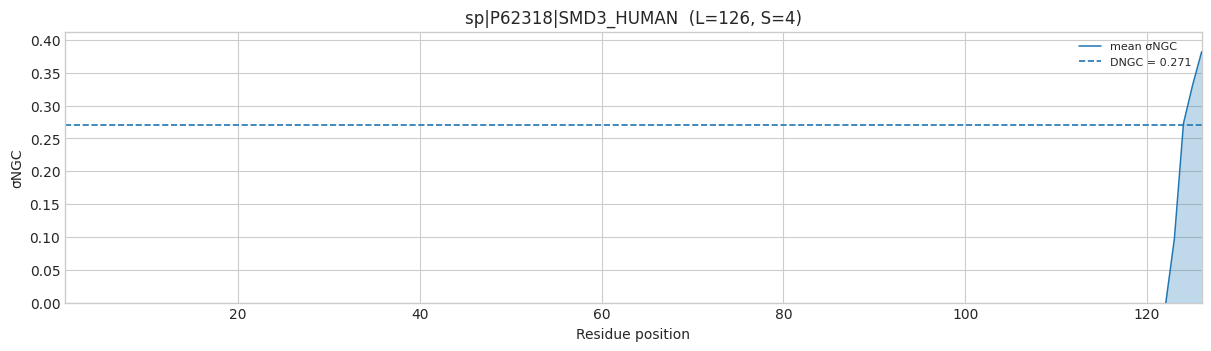

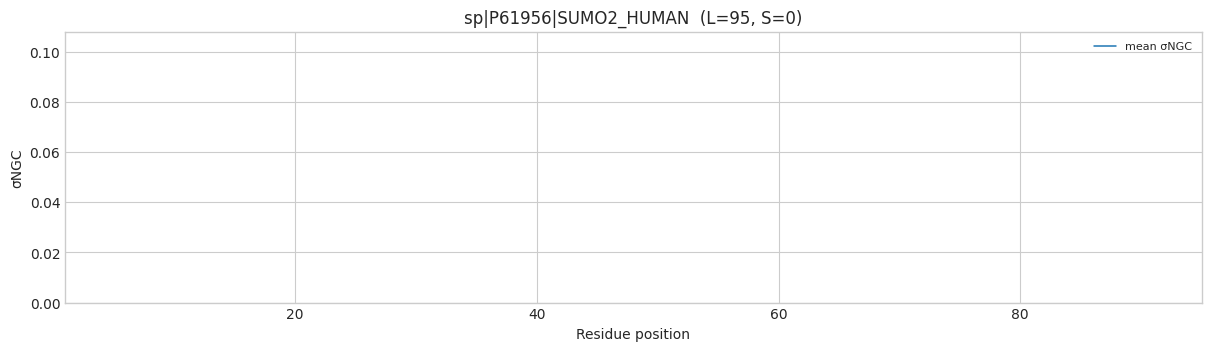

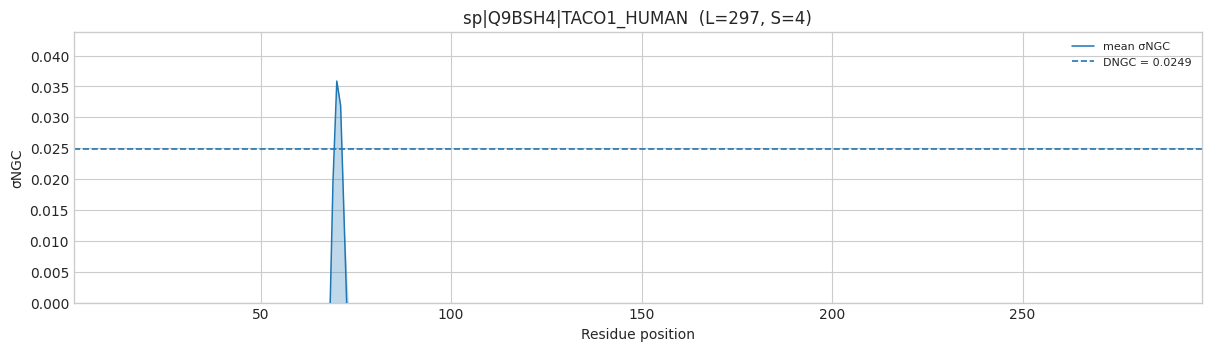

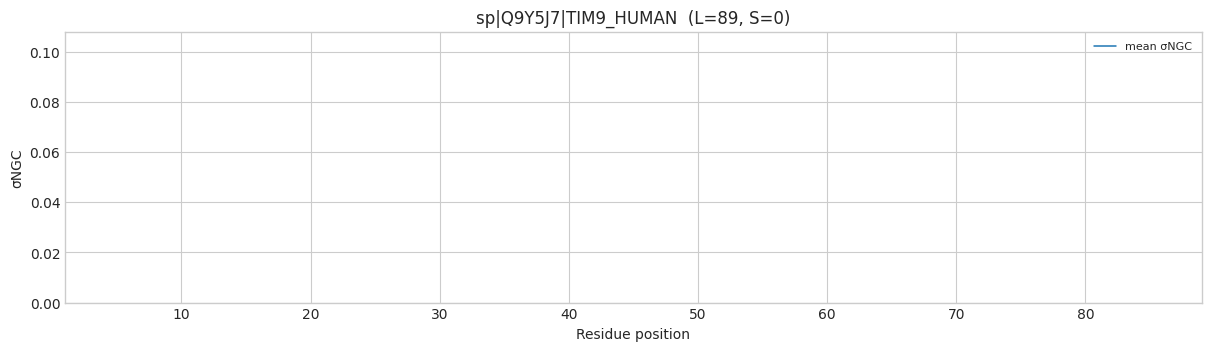

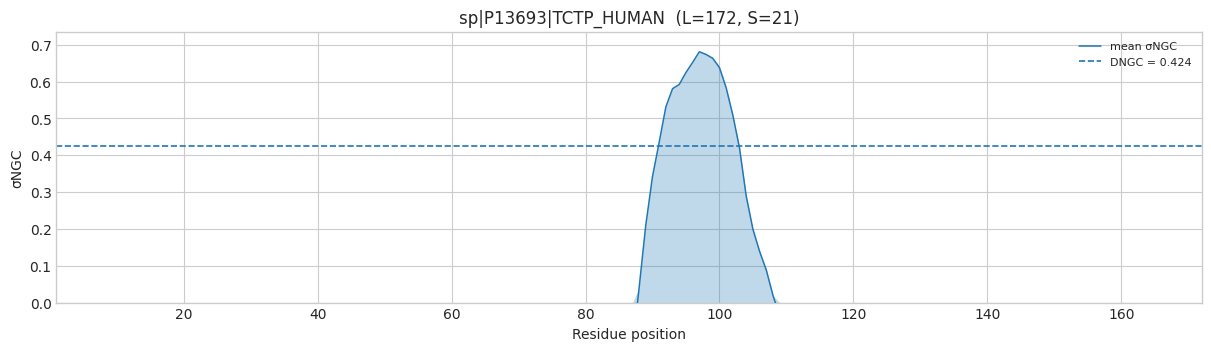

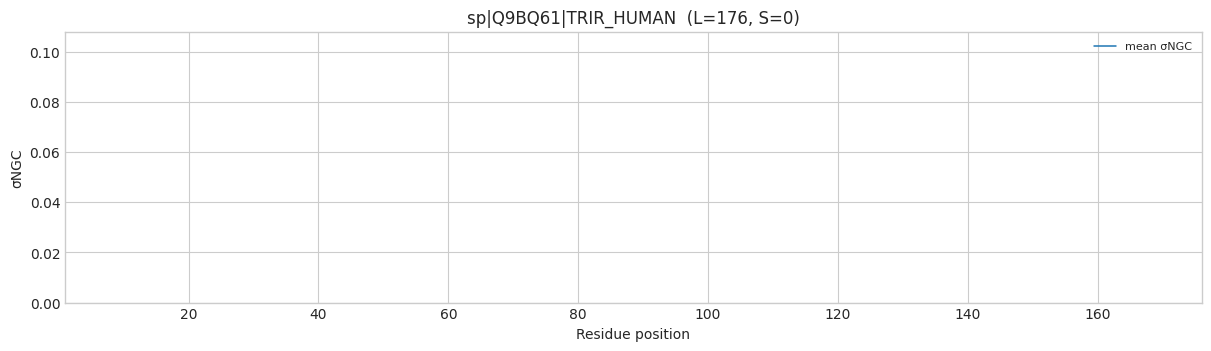

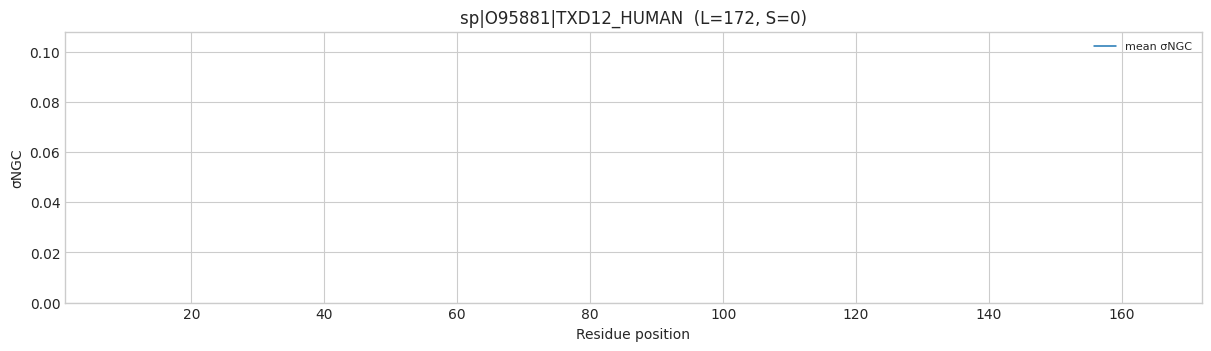

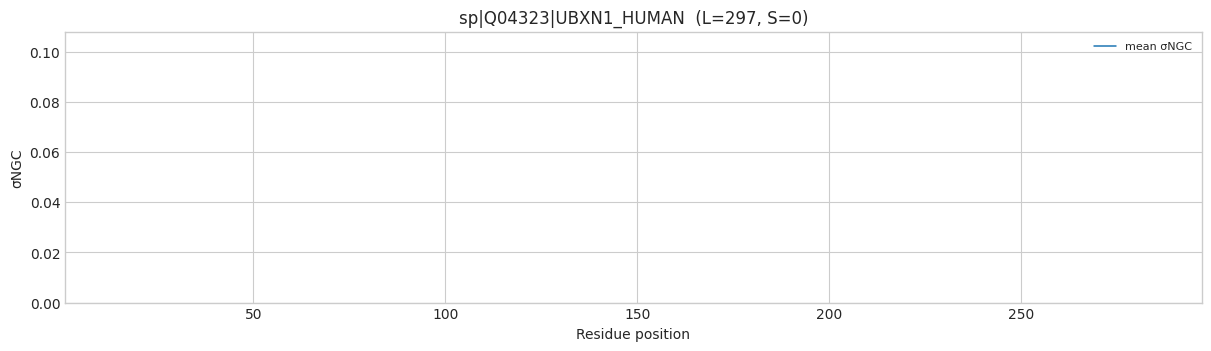

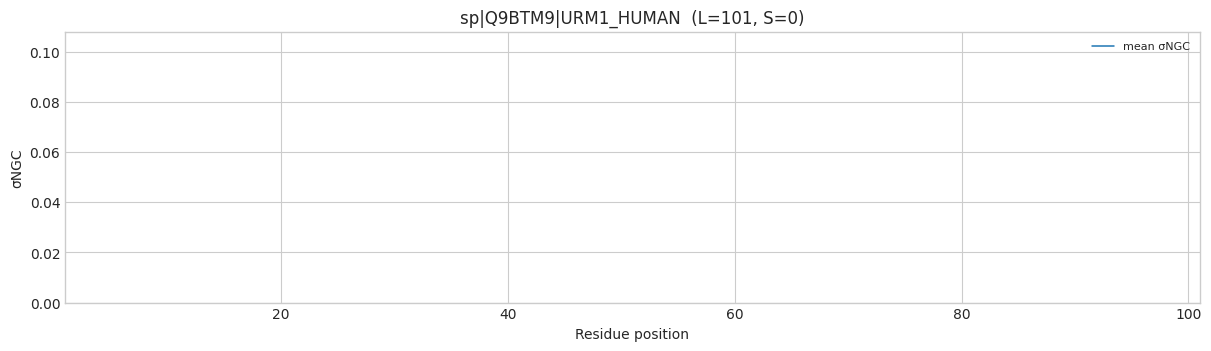

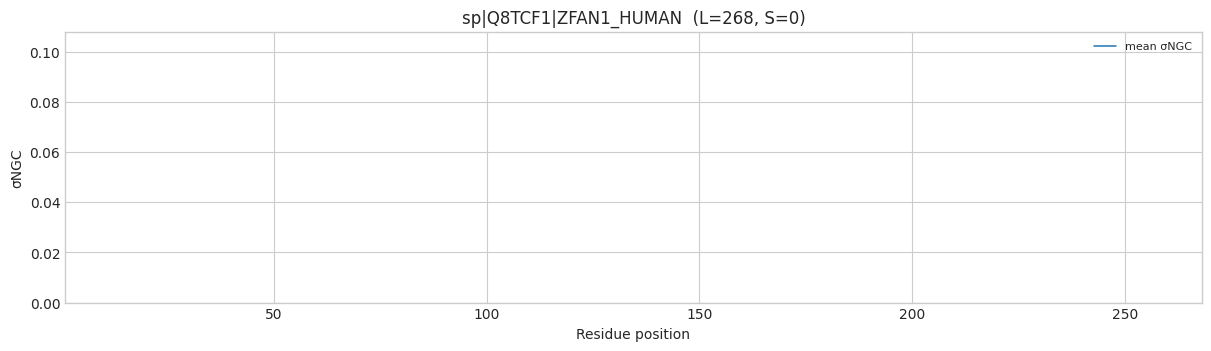

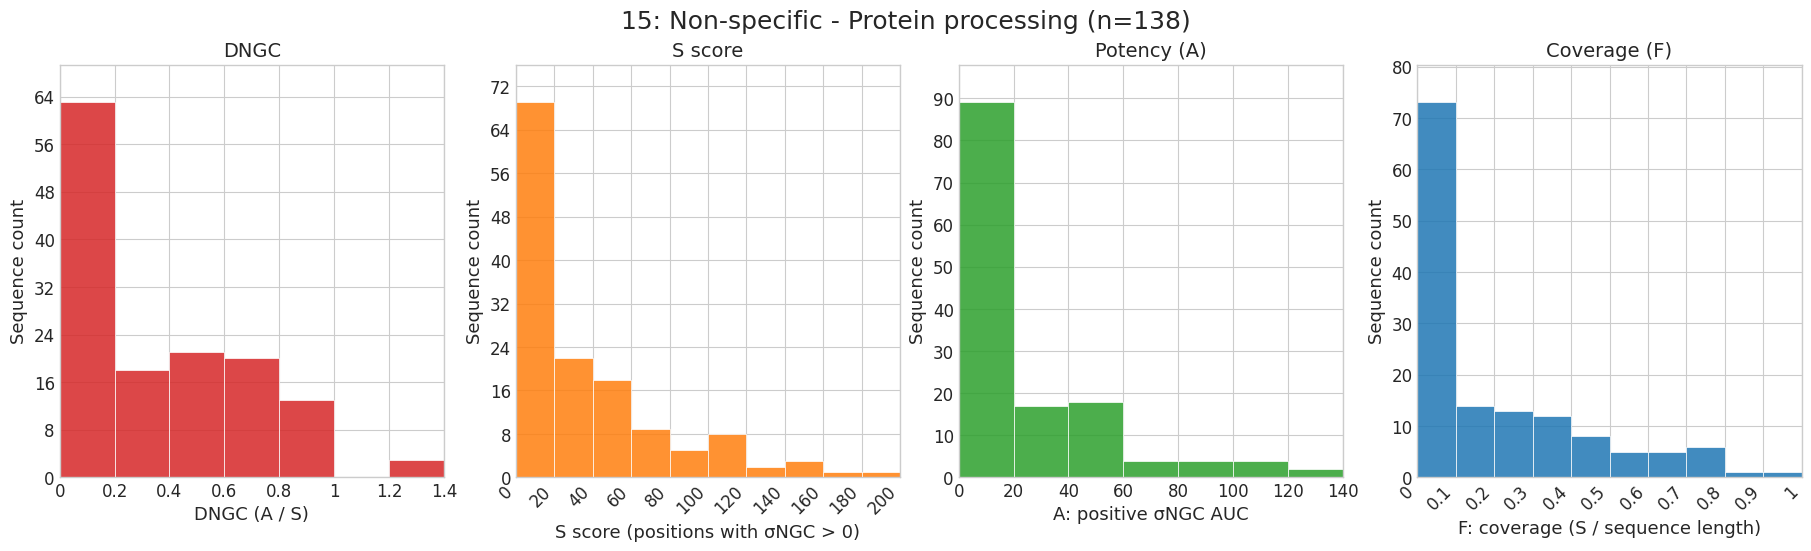

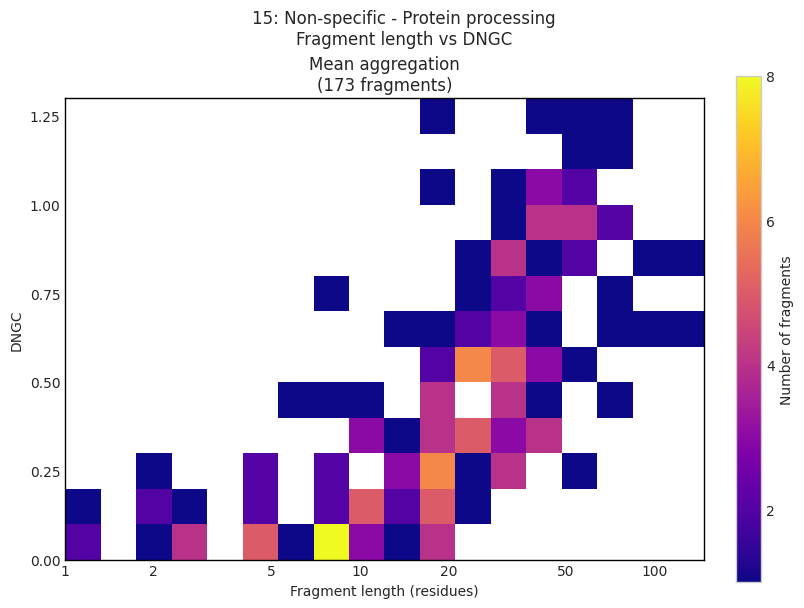

In [33]:
EXAMPLE_CLUSTER_NUMBER = 15
PROFILE_COLOR = "C0"


def cluster_number_from_name(name: str) -> int | None:
    match = re.match(r"Cluster\s+(\d+)", name)
    return int(match.group(1)) if match else None


def find_cluster_by_number(groups: list[ClusterGroup], number: int) -> ClusterGroup:
    matches = [group for group in groups if cluster_number_from_name(group.name) == number]
    if len(matches) == 1:
        return matches[0]
    available = sorted(
        {value for value in (cluster_number_from_name(group.name) for group in groups) if value is not None}
    )
    if not matches:
        raise ValueError(f"Cluster {number} not found. Available cluster numbers: {available}")
    raise ValueError(f"Cluster {number} matched {len(matches)} groups.")


def example_cluster_group(number: int) -> ClusterGroup:
    groups = build_cluster_groups(
        profiles_df,
        MEAN_SIGMA_COLUMN,
        MEAN_P_AMP_COLUMN,
        limit=None,
    )
    return find_cluster_by_number(groups, number)


def sequence_dngc_breakdown(item: SequenceProfile) -> dict[str, object]:
    stats = item.statistics
    formula = "0" if stats.s_score == 0 else f"{stats.potency_auc:.6g} / {stats.s_score}"
    return {
        "id": item.id,
        "name": item.name,
        "length": item.sequence_length,
        "S": stats.s_score,
        "N": stats.fragment_count,
        "A": stats.potency_auc,
        "F": stats.coverage,
        "DNGC": stats.dngc,
        "DNGC_formula": formula,
    }


def draw_profile_sigma(ax, item: SequenceProfile) -> None:
    residue = np.arange(1, item.sequence_length + 1)
    sigma = np.nan_to_num(item.sigma, nan=0.0)
    active = activity_mask(item.sigma, item.p_amp)
    stats = item.statistics
    shown = np.where(active, np.maximum(sigma, SIGMA_ACTIVITY_THRESHOLD), SIGMA_ACTIVITY_THRESHOLD)
    ax.fill_between(
        residue,
        SIGMA_ACTIVITY_THRESHOLD,
        shown,
        color=PROFILE_COLOR,
        alpha=0.28,
        linewidth=0,
    )
    ax.plot(residue, sigma, color=PROFILE_COLOR, linewidth=1.1, zorder=3, label="mean σNGC")
    if stats.s_score:
        ax.axhline(
            SIGMA_ACTIVITY_THRESHOLD + stats.dngc,
            color=PROFILE_COLOR,
            linewidth=1.2,
            linestyle="--",
            label=f"DNGC = {stats.dngc:.3g}",
        )


def draw_sequence_sigma_dngc(ax, item: SequenceProfile) -> None:
    draw_profile_sigma(ax, item)
    ax.axhline(SIGMA_ACTIVITY_THRESHOLD, color="black", linewidth=0.7)
    ax.set(
        xlim=(1, item.sequence_length),
        ylim=_sigma_ylim(np.nan_to_num(item.sigma, nan=0.0)),
        xlabel="Residue position",
        ylabel="σNGC",
        title=f"{item.id}  (L={item.sequence_length}, S={item.statistics.s_score})",
    )
    ax.legend(fontsize=8, loc="upper right")


def draw_distribution(
    ax,
    values: np.ndarray,
    bins: np.ndarray,
    title: str,
    xlabel: str,
    color: str,
    all_zero_message: str | None = None,
    ylim: tuple[float, float] | None = None,
) -> None:
    finite = values[np.isfinite(values)]
    ax.hist(
        finite,
        bins=bins,
        color=color,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.6,
    )
    if all_zero_message and finite.size and np.allclose(finite, 0.0):
        ax.text(
            0.5,
            0.88,
            all_zero_message.format(count=finite.size),
            ha="center",
            transform=ax.transAxes,
            fontsize=12,
        )
    ax.set(
        xlim=(float(bins[0]), float(bins[-1])),
        xlabel=xlabel,
        ylabel="Sequence count",
        title=title,
    )
    ax.title.set_size(14)
    ax.xaxis.label.set_size(13)
    ax.yaxis.label.set_size(13)
    configure_histogram_x_axis(ax, bins)
    ax.tick_params(axis="both", labelsize=12)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    if ylim is None:
        ax.margins(y=0.1)
    else:
        ax.set_ylim(ylim)


def show_cluster_metric_histograms(group: ClusterGroup) -> None:
    fig, axes = plt.subplots(
        1,
        len(METRIC_HISTOGRAMS),
        figsize=(18.0, 5.4),
        layout="constrained",
    )
    for ax, (values_from_group, xlabel, zero_message, title, color) in zip(axes, METRIC_HISTOGRAMS):
        values = np.asarray(values_from_group(group), dtype=np.float64)
        draw_distribution(
            ax,
            values,
            histogram_bins(values),
            title,
            xlabel,
            color,
            zero_message,
        )
    fig.suptitle(
        f"{short_cluster_label(group.name, 72)} (n={group.n})",
        fontsize=18,
    )
    plt.show()


METRIC_HISTOGRAMS = (
    (
        cluster_dngc_values,
        "DNGC (A / S)",
        "All {count} sequences have DNGC = 0",
        "DNGC",
        "C3",
    ),
    (
        sequence_s_score_values,
        "S score (positions with σNGC > 0)",
        "All {count} sequences have S = 0",
        "S score",
        "C1",
    ),
    (
        sequence_a_values,
        "A: positive σNGC AUC",
        "All {count} sequences have A = 0",
        "Potency (A)",
        "C2",
    ),
    (
        sequence_f_values,
        "F: coverage (S / sequence length)",
        "All {count} sequences have F = 0",
        "Coverage (F)",
        "C0",
    ),
)


def fragment_length_dngc(group: ClusterGroup) -> tuple[np.ndarray, np.ndarray]:
    lengths: list[float] = []
    scores: list[float] = []
    for item in group.profiles:
        for start, end, dngc in active_fragment_spans(item.sigma, item.p_amp):
            length = end - start
            if length <= 0 or not np.isfinite(dngc):
                continue
            lengths.append(float(length))
            scores.append(dngc)
    return np.asarray(lengths, dtype=np.float64), np.asarray(scores, dtype=np.float64)


def _integer_span_ticks(low: int, high: int) -> list[int]:
    if high < low:
        low, high = high, low
    if high == low:
        return [low]
    raw = MaxNLocator(integer=True, nbins=5, min_n_ticks=2).tick_values(low, high)
    ticks = sorted({int(round(value)) for value in raw if low <= value <= high})
    return ticks or [low, high]


def _log_length_edges(low: float, high: float, bins_per_decade: int = 8) -> np.ndarray:
    low = max(1.0, low)
    high = max(high, low + 1.0)
    n_bins = max(1, int(np.ceil(np.log10(high / low) * bins_per_decade)))
    edges = np.geomspace(low, high, n_bins + 1)
    edges[0] = low
    edges[-1] = high
    return edges


def _integer_tick_label(value: float, _position: object) -> str:
    rounded = int(round(value))
    if rounded < 1 or abs(value - rounded) > 1e-4 * value:
        return ""
    return str(rounded)


def plot_fragment_length_dngc_heatmap(group: ClusterGroup) -> None:
    lengths, scores = fragment_length_dngc(group)
    if lengths.size == 0:
        fig, ax = plt.subplots(figsize=(7.6, 5.4), layout="constrained")
        ax.set_facecolor("white")
        ax.grid(False)
        ax.set(xlabel="Fragment length (residues)", ylabel="DNGC", title="Mean aggregation\nNo fragments")
        fig.suptitle(f"{short_cluster_label(group.name, 64)}\nFragment length vs DNGC")
        plt.show()
        return

    x_lo = max(1.0, float(np.floor(lengths.min())))
    x_hi = float(np.ceil(lengths.max()))
    if x_hi <= x_lo:
        x_hi = x_lo + 1.0
    y_hi = float(scores.max())
    y_step = 0.1 if y_hi <= 2.5 else 0.25
    y_hi = float(np.ceil((y_hi + 1e-9) / y_step) * y_step)
    x_edges = _log_length_edges(x_lo, x_hi)
    y_edges = np.arange(0.0, y_hi + y_step * 0.5, y_step)
    n_x = len(x_edges) - 1
    n_y = max(len(y_edges) - 1, 1)
    cell = 0.32
    fig, ax = plt.subplots(figsize=(cell * n_x + 2.2, cell * n_y + 1.8), layout="constrained")
    ax.set_facecolor("white")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")

    counts, _, _ = np.histogram2d(lengths, scores, bins=[x_edges, y_edges])
    masked = np.ma.masked_where(counts.T == 0, counts.T)
    peak = int(counts.max()) if counts.size else 1
    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        masked,
        cmap="plasma",
        vmin=1,
        vmax=max(peak, 1),
        shading="flat",
    )
    colorbar = fig.colorbar(mesh, ax=ax)
    colorbar.set_label("Number of fragments")
    count_ticks = _integer_span_ticks(1, max(peak, 1))
    colorbar.set_ticks(count_ticks)
    colorbar.set_ticklabels([str(tick) for tick in count_ticks])

    ax.set_xscale("log")
    ax.set_xlim(x_edges[0], x_edges[-1])
    ax.set_ylim(y_edges[0], y_edges[-1])
    ax.set_box_aspect(n_y / n_x)
    ax.margins(x=0, y=0)
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
    ax.xaxis.set_major_formatter(FuncFormatter(_integer_tick_label))
    ax.xaxis.minorticks_off()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, min_n_ticks=2))
    ax.set(
        xlabel="Fragment length (residues)",
        ylabel="DNGC",
        title=f"Mean aggregation\n({int(lengths.size)} fragments)",
    )
    fig.suptitle(f"{short_cluster_label(group.name, 64)}\nFragment length vs DNGC")
    plt.show()


example_group = example_cluster_group(EXAMPLE_CLUSTER_NUMBER)
print(f"Cluster {EXAMPLE_CLUSTER_NUMBER}: {example_group.name}")
print(f"Sequences: {example_group.n}")
print("DNGC = A / S")
print(f"  S score = number of residues with σNGC > {SIGMA_ACTIVITY_THRESHOLD:.2f}")
print(f"  N = fragment count = contiguous runs with σNGC > {SIGMA_ACTIVITY_THRESHOLD:.2f}")
print(f"  A = sum of (σNGC - {SIGMA_ACTIVITY_THRESHOLD:.4g}) on those residues")
print("  F = S / sequence length")

breakdown = pd.DataFrame([sequence_dngc_breakdown(item) for item in example_group.profiles])
display(breakdown)

for item in example_group.profiles:
    fig, ax = plt.subplots(figsize=(12.0, 3.4), layout="constrained")
    draw_sequence_sigma_dngc(ax, item)
    plt.show()

show_cluster_metric_histograms(example_group)

plot_fragment_length_dngc_heatmap(example_group)
